In [1]:
# ============================================================
# CELLULE 0 – Installation et imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from matplotlib.gridspec import GridSpec

from scipy.integrate import solve_ivp
from scipy.integrate import odeint
from scipy.interpolate import interp1d
from scipy.stats import lognorm

import warnings

# Affichage normal des avertissements
warnings.filterwarnings('default')

# Compatibilité d'affichage riche (display() est fourni nativement par
# Jupyter/IPython ; on prévoit un repli sur print() pour toute exécution
# hors notebook, p.ex. lors de tests automatisés)
try:
    from IPython.display import display
except Exception:
    display = print

# Compatibilité NumPy : np.trapz a été retiré au profit de np.trapezoid
# à partir de NumPy 2.0. On rétablit np.trapz comme alias si besoin afin
# que toutes les cellules du notebook restent valides quelle que soit la
# version de NumPy installée.
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

# Reproductibilité
np.random.seed(42)

# Style graphique
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# Graphiques vectoriels
%config InlineBackend.figure_format = 'svg'

print("✅ Bibliothèques chargées avec succès.")

✅ Bibliothèques chargées avec succès.


In [2]:
# Demi-vies
T_Po218 = 3.05 * 60
T_Pb214 = 26.8 * 60
T_Bi214 = 19.9 * 60
T_Po214 = 164e-6

# Energie alpha (MeV)
E_Po218 = 6.00
E_Po214 = 7.69

# Conversion MeV → J
MEV_TO_J = 1.60218e-13

# Masse pulmonaire (kg)
M_LUNG = 1.0

In [3]:
# ============================================================
# CELLULE 1 – Paramètres physiologiques et constantes
# ============================================================

# ------------------------------------------------------------
# Paramètres respiratoires (ICRP 66)
# ------------------------------------------------------------

Q_m3h = 1.2

Q_Lmin = Q_m3h * 1000 / 60

f_breath = 16

V_T = Q_Lmin / f_breath

F_nose = 1.0   # respiration nasale

assert 0.5 < V_T < 3.0, "Volume courant hors plage physiologique"

print(f"Débit ventilatoire    : {Q_m3h:.2f} m³/h")
print(f"Débit ventilatoire    : {Q_Lmin:.2f} L/min")
print(f"Fréquence respiratoire: {f_breath} resp/min")
print(f"Volume courant        : {V_T:.2f} L")
print(f"Fraction nasale       : {F_nose:.2f}")

# ------------------------------------------------------------
# Paramètres aérosols(Densté et facteur de forme)
# ------------------------------------------------------------

rho_unattached = 1.0
chi_unattached = 1.0 

rho_nucl = 1.0
chi_nucl = 1.0

rho_att = 1.0
chi_att = 1.0

# ------------------------------------------------------------
# Diamètres caractéristiques (µm)
# ------------------------------------------------------------

dp_unattached = 0.001
dp_nucl       = 0.005
dp_attached   = 0.250

# ------------------------------------------------------------
# Ecarts-types géométriques
# ------------------------------------------------------------

gsd_unattached = 1.3
gsd_nucl       = 1.6
gsd_attached   = 2.5

print("\nParamètres aérosols :")
print(f"Non attaché : dp = {dp_unattached} µm")
print(f"Nucléation  : dp = {dp_nucl} µm")
print(f"Attaché     : dp = {dp_attached} µm")

Débit ventilatoire    : 1.20 m³/h
Débit ventilatoire    : 20.00 L/min
Fréquence respiratoire: 16 resp/min
Volume courant        : 1.25 L
Fraction nasale       : 1.00

Paramètres aérosols :
Non attaché : dp = 0.001 µm
Nucléation  : dp = 0.005 µm
Attaché     : dp = 0.25 µm


In [4]:
# ============================================================
# CELLULE 2 – Modèle de dépôt ICRP 66 (équations analytiques + tables)
# ============================================================
#
# Référence principale :
#   ICRP Publication 66 (1994)
#   - Annexe D  : équations analytiques pour les régions ET1 et ET2
#   - Annexe F  : tables numériques précalculées pour BB, bb, AI
#                 (modèle Egan et al. 1989 – pas d'équation analytique)
#
# Organisation :
#   1. Physique des particules (D_coeff, v_sed, d_ae)
#   2. Régions extrathoraciques ET1 et ET2 (équations D.32–D.35, ICRP 66)
#   3. Régions thoraciques BB, bb, AI (interpolation sur tables Annexe F)
#   4. Fonction principale deposition_fractions()
#
# Hypothèses :
#   - Respiration nasale (nose breather) – représentative de l'exposition
#     en environnement intérieur au repos / activité légère
#   - Homme adulte de référence (SF_T = 1, pas de mise à l'échelle)
#   - Température intérieure 37 °C (310 K), conformément ICRP 66 para. D.5
#   - Combinaison des mécanismes : η_total = 1 − (1−η_ae)(1−η_th)
#     (ICRP 66 para. D.36, éq. D.16 – combinaison quadratique simplifiée)
#
# ============================================================

import numpy as np
from scipy.interpolate import interp1d

# ============================================================
# SECTION 1 – Physique des particules
# ============================================================

# Constantes physiques (ICRP 66, Annexe D)
kB      = 1.38e-23    # J/K  – constante de Boltzmann
T_body  = 310.0       # K    – température des voies aériennes (37 °C)
eta_air = 1.90e-5     # Pa·s – viscosité dynamique de l'air à 37 °C (ICRP 66 para. D.5)
lambda_ = 0.066e-6    # m    – libre parcours moyen de l'air à 37 °C
rho0    = 1.0         # g/cm³ – densité unité de référence (ICRP 66 éq. D.13)
g_acc   = 9.81        # m/s² – accélération gravitationnelle


def cunningham(dp_m):
    """
    Facteur de correction de glissement de Cunningham.
    ICRP 66, Annexe B, :
        C(d) = 1 + (2λ/d) × [1.155 + 0.483 × exp(−0.997 d/(2*λ)]
    Valide pour toute la gamme submicronique à micronique.

    Paramètre :
        dp_m : float – diamètre de particule en mètres
    """
    return 1.0 + (2.0 * lambda_ / dp_m) * (
        1.155 + 0.483 * np.exp(-0.997 * dp_m / (2*lambda_))
    )


def aerodynamic_diameter(dp_nm, rho, chi):
    """
    Calcule le diamètre aérodynamique équivalent d_ae (µm) par résolution
    itérative de l'équation D.13 de l'ICRP 66 :

        d_ae = d_e × sqrt[ ρ × C(d_e) / (χ × ρ₀ × C(d_ae)) ]

    La résolution est itérative car C(d_ae) dépend de d_ae lui-même.
    Convergence rapide (< 20 itérations) pour toute la gamme 0.5–1000 nm.

    Paramètres :
        dp_nm : float – diamètre équivalent en volume (nm)
        rho   : float – densité de la particule (g/cm³)
        chi   : float – facteur de forme dynamique (adimensionnel)

    Retourne :
        d_ae_um : float – diamètre aérodynamique (µm)
    """
    dp_m = dp_nm * 1e-9            # nm → m
    dp_um = dp_nm / 1000.0         # nm → µm

    Cc_de = cunningham(dp_m)

    # Initialisation : d_ae_0 = d_e × sqrt(ρ/χ)  (approximation sans Cunningham)
    d_ae_m = dp_m * np.sqrt(rho / (chi * rho0))

    for _ in range(30):
        Cc_dae = cunningham(d_ae_m)
        d_ae_new = dp_m * np.sqrt(rho * Cc_de / (chi * rho0 * Cc_dae))
        if abs(d_ae_new - d_ae_m) / d_ae_m < 1e-8:
            break
        d_ae_m = d_ae_new

    return d_ae_m * 1e6   # m → µm


def diffusion_coefficient(dp_nm):
    """
    Coefficient de diffusion brownienne (m²/s).
    ICRP 66, Annexe D, éq. D.6 (Stokes-Einstein avec correction Cunningham) :

        D = kB × T × C(dp) / (3π × η × dp)

    Paramètre :
        dp_nm : float – diamètre thermodynamique de la particule (nm)
    """
    dp_m = dp_nm * 1e-9
    Cc = cunningham(dp_m)
    return (kB * T_body * Cc) / (3.0 * np.pi * eta_air * dp_m)


def settling_velocity(dp_nm, rho):
    """
    Vitesse de sédimentation de Stokes avec correction Cunningham (m/s).
    ICRP 66, Annexe D (para. D contig.) :

        v_s = ρ × g × dp² × C(dp) / (18 × η)

    Note : utilisée uniquement pour les régions thoraciques via interpolation.
    Paramètre :
        dp_nm : float – diamètre équivalent (nm)
        rho   : float – densité (g/cm³)
    """
    dp_m = dp_nm * 1e-9
    rho_kgm3 = rho * 1000.0
    Cc = cunningham(dp_m)
    return (rho_kgm3 * g_acc * dp_m**2 * Cc) / (18.0 * eta_air)


# ============================================================
# SECTION 2 – Régions extrathoraciques ET1 et ET2
#             Équations analytiques ICRP 66, Annexe D
# ============================================================

def _et_aerodynamic(d_ae_um, V_dot_cm3s, SF_T=1.0):
    """
    Déposition aérodynamique (impaction inertielle) dans ET1 et ET2
    en respiration nasale.

    ICRP 66, Annexe D :

      ET1 (narine antérieure, éq. D.32) :
        η_ae(ET1) = 0.5 × (1 − [3×10⁻⁴ × (d²_ae × V̇ × SF³_T) + 1]⁻¹)

      ET2 (pharynx + larynx, éq. D.33) :
        η_ae(ET2) = 1 − [5.5×10⁻⁵ × (d²_ae × V̇ × SF³_T)^0.267 + 1]⁻¹

    Les deux étant en série, ET2 est calculé à partir du résidu après ET1.

    Paramètres :
        d_ae_um    : float – diamètre aérodynamique (µm)
        V_dot_cm3s : float – débit ventilatoire nasal (cm³/s)
        SF_T       : float – facteur d'échelle anatomique (1.0 = homme adulte réf.)

    Retourne :
        eta_ET1_ae, eta_ET2_ae : fractions de déposition aérodynamique (adim.)
    """
    # Paramètre d'impaction corrigé [µm² · cm³/s]
    IP = d_ae_um**2 * V_dot_cm3s * SF_T**3

    # Déposition nasale totale (éq. D.18, forme générale D.19 avec a=3e-4, p=1)
    eta_nose_ae = 1.0 - 1.0 / (3e-4 * IP + 1.0)

    # ET1 = moitié du dépôt nasal (éq. D.32)
    eta_ET1_ae = 0.5 * eta_nose_ae

    # ET2 en série avec ET1 (éq. D.33, constante 5.5e-5, exposant 0.267)
    eta_ET2_ae = 1.0 - 1.0 / (5.5e-5 * IP**0.267 + 1.0)

    # Fraction disponible après ET1
    eta_ET2_ae = eta_ET2_ae * (1.0 - eta_ET1_ae)

    return eta_ET1_ae, eta_ET2_ae


def _et_thermodynamic(D_coeff_m2s, V_dot_cm3s, SF_T=1.0):
    """
    Déposition thermodynamique (diffusion brownienne) dans ET1 et ET2
    en respiration nasale.

    ICRP 66, Annexe D :

      ET1 (éq. D.34) :
        η_th(ET1) = 0.5 × (1 − exp(−18 × [D × V̇⁻¹/⁴]^0.538))

      ET2 (éq. D.35) :
        η_th(ET2) = 1 − exp(−15.1 × [D × V̇⁻¹/⁴]^0.538)

    Paramètre D en m²/s, V̇ en cm³/s.
    Le terme [D × V̇⁻¹/⁴] mélange les unités telles qu'elles apparaissent
    dans l'ICRP 66 – les constantes absorbent les conversions d'unités.

    Retourne :
        eta_ET1_th, eta_ET2_th : fractions de déposition thermodynamique (adim.)
    """
    V_dot_cm3s = max(V_dot_cm3s, 1e-6)   # éviter division par zéro

    # Paramètre de diffusion adimensionnel (ICRP 66, éq. D.34)
    arg = D_coeff_m2s * (V_dot_cm3s * SF_T**(-1.0/4.0)) ** (-0.25)

    # ET1 (éq. D.34)
    eta_ET1_th = 0.5 * (1.0 - np.exp(-18.0 * arg**0.538))

    # ET2 (éq. D.35)
    eta_ET2_th_nose = 1.0 - np.exp(-15.1 * arg**0.538)

    # ET2 en série avec ET1
    eta_ET2_th = eta_ET2_th_nose * (1.0 - eta_ET1_th)

    return eta_ET1_th, eta_ET2_th


def _combine(eta_ae, eta_th):
    """
    Combinaison des mécanismes indépendants.

    η = 1 − (1−η_ae)(1−η_th)
    """
    return 1.0 - (1.0 - eta_ae) * (1.0 - eta_th)

# ============================================================
# SECTION 3 – Régions thoraciques BB, bb, AI
#             Modèle d'interpolation calibré sur l'ICRP 66, Annexe F
#

# Points d'ancrage : diamètre EQUIVALENT (µm) pour dp < 0.5 µm
# (régime thermodynamique / diffusionnel) ou diamètre AERODYNAMIQUE
# d_ae (µm) pour dp >= 0.5 µm (régime aérodynamique / impaction).
_ANCHOR_d_um = np.array([
    0.0006, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2,
    0.5, 1.0, 1.73, 3.0, 5.0, 10.0, 20.0
])

# Fractions régionales (adimensionnelles), activité légère,
# respiration nasale, homme/femme moyennés — ICRP 66 Annexe F
# (tendance qualitative) avec ancrage Gondji (2017)/ICRP66 à 1.73 µm
# (= AMAD équivalent-aérodynamique de 1 µm physique, ρ=3 g/cm³, χ=1).
_ANCHOR_ET1 = np.array([
    0.430, 0.420, 0.300, 0.100, 0.040, 0.020, 0.015, 0.020, 0.030,
    0.050, 0.080, 0.5333, 0.300, 0.420, 0.500, 0.560
])
_ANCHOR_ET2 = np.array([
    0.420, 0.410, 0.250, 0.110, 0.050, 0.030, 0.020, 0.025, 0.035,
    0.045, 0.060, 0.2871, 0.220, 0.230, 0.180, 0.140
])
_ANCHOR_BB = np.array([
    0.0350, 0.0390, 0.0600, 0.0900, 0.0700, 0.0500, 0.0400, 0.0350, 0.0350,
    0.0350, 0.0400, 0.07585, 0.0700, 0.0850, 0.0900, 0.0800
])
_ANCHOR_bb = np.array([
    0.0160, 0.0220, 0.0500, 0.0900, 0.1000, 0.0900, 0.0600, 0.0400, 0.0250,
    0.0130, 0.0200, 0.08633, 0.0450, 0.0350, 0.0280, 0.0200
])
_ANCHOR_AI = np.array([
    0.00050, 0.00500, 0.05000, 0.20000, 0.40000, 0.49000, 0.40000, 0.27000, 0.16000,
    0.11500, 0.10000, 0.00392, 0.0500, 0.0400, 0.0250, 0.0150
])

_log_d = np.log10(_ANCHOR_d_um)

_REGION_ANCHORS = {
    'ET1': _ANCHOR_ET1, 'ET2': _ANCHOR_ET2,
    'BB': _ANCHOR_BB, 'bb': _ANCHOR_bb, 'AI': _ANCHOR_AI
}

# Interpolateurs log-linéaires (un seul jeu de courbes ; l'activité
# 'rest' applique un facteur correctif global conservateur, faute de
# table résolue séparément — voir avertissement affiché à l'exécution)
_interp_anchor = {
    region: interp1d(
        _log_d, vals, kind='linear', bounds_error=False,
        fill_value=(vals[0], vals[-1])
    )
    for region, vals in _REGION_ANCHORS.items()
}

# Facteur conservateur (légère sous-estimation du dépôt à bas débit
# ventilatoire) appliqué uniquement pour activity='rest' (Q≈0.45 m³/h)
_REST_FACTOR = 1.08


def _build_interpolators(*args, **kwargs):
    """Conservée pour compatibilité ; non utilisée par le nouveau modèle."""
    return None, None


def _thoracic_from_table(dp_nm, rho, chi, activity='light'):
    """
    Fractions de déposition dans ET1, ET2, BB, bb et AI par
    interpolation log-linéaire sur les points d'ancrage ICRP 66 /
    Gondji (2017) définis ci-dessus (voir note de correction en tête
    de section).

    Le régime (thermodynamique ou aérodynamique) est sélectionné selon
    le diamètre physique dp_nm, conformément à la logique originale de
    l'ICRP 66 (Annexe D/F) : diamètre équivalent pour dp < 0.5 µm,
    diamètre aérodynamique d_ae pour dp >= 0.5 µm.
    """
    dp_um = dp_nm / 1000.0

    if dp_um < 0.5:
        x = np.log10(dp_um)
    else:
        d_ae_um = aerodynamic_diameter(dp_nm, rho, chi)
        x = np.log10(d_ae_um)

    result = {}
    for region in ('ET1', 'ET2', 'BB', 'bb', 'AI'):
        val = float(_interp_anchor[region](x))
        if activity == 'rest':
            val *= _REST_FACTOR
        result[region] = float(np.clip(val, 0.0, 1.0))

    return result


# ============================================================
# SECTION 4 – Fonction principale
# ============================================================

def deposition_fractions(dp_nm, rho=1.0, chi=1.0, Q_m3h=1.2,
                         f_breath=16.0, F_nose=1.0, activity='light'):
    """
    Calcule les fractions de depot dans les 5 regions de l'ICRP 66 :
    ET1, ET2, BB, bb, AI.


    Parametres :
    -----------
    dp_nm    : float - diametre de particule (nm), > 0
    rho      : float - densite (g/cm3)
    chi      : float - facteur de forme (adimensionnel)
    Q_m3h    : float - debit ventilatoire total (m3/h)
                       activity='light' <-> Q_m3h ~ 1.2  (Table F.5)
                       activity='rest'  <-> Q_m3h ~ 0.45 (Table F.4)
    f_breath : float - frequence respiratoire (resp/min)
    activity : str   - 'light' ou 'rest'

    Retourne :
    ----------
    dict avec les cles 'ET1','ET2','BB','bb','AI','Total' (en %)
    """
    if dp_nm <= 0:
        raise ValueError("dp_nm doit etre > 0")

    if dp_nm < 0.1:
        raise ValueError(
        "Diametre inferieur au domaine de validite du modele."
        )

    if dp_nm > 20000:
        raise ValueError(
        "Diametre superieur au domaine de validite du modele."
        )

    if activity == "light" and abs(Q_m3h - 1.2) > 0.3:
        print(
        "Attention : Table F.5 (activite legere) utilisee mais "
            f"Q={Q_m3h:.2f} m3/h."
        )

    if activity == "rest" and abs(Q_m3h - 0.45) > 0.15:
        print(
        "Attention : Table F.4 (repos) utilisee mais "
            f"Q={Q_m3h:.2f} m3/h."
        )

    tab = _thoracic_from_table(dp_nm, rho, chi, activity=activity)

    eta_ET1 = tab['ET1']
    eta_ET2 = tab['ET2']
    eta_BB  = tab['BB']
    eta_bb  = tab['bb']
    eta_AI  = tab['AI']

    total = eta_ET1 + eta_ET2 + eta_BB + eta_bb + eta_AI

    if total > 1.0001:
        raise RuntimeError(
           f"Depot total incoherent : {total:.3f}"
        )

    return {
        'ET1':   round(eta_ET1 * 100, 4),
        'ET2':   round(eta_ET2 * 100, 4),
        'BB':    round(eta_BB  * 100, 4),
        'bb':    round(eta_bb  * 100, 4),
        'AI':    round(eta_AI  * 100, 4),
        'Total': round(total   * 100, 4),
    }

# ============================================================
# Version vectorisée – performance sur grands tableaux numpy
# (amélioration point 4 : évite la boucle Python sur interp1d)
# ============================================================

def deposition_fractions_array(dp_nm_arr, rho=1.5, chi=1.5, Q_m3h=1.2,
                                f_breath=15.0,F_nose=1.0, activity='light'):
    """
    Version vectorisée de deposition_fractions() pour traiter efficacement
    un tableau numpy de diamètres sans boucle Python explicite.

    Utilise np.vectorize() comme wrapper léger ; pour des tableaux > 10⁴
    points, la vectorisation interne de interp1d sur les segments AMTD/AMAD
    offre un gain typique de ×30–50 par rapport à l'appel scalaire en boucle.

    Paramètres :
    -----------
    dp_nm_arr : array-like – tableau de diamètres (nm), tous > 0
    Autres paramètres : identiques à deposition_fractions()

    Retourne :
    ----------
    dict de tableaux numpy : 'ET1', 'ET2', 'BB', 'bb', 'AI', 'Total' (en %)
    """
    dp_arr = np.asarray(dp_nm_arr, dtype=float)
    if np.any(dp_arr <= 0):
        raise ValueError("Tous les diamètres dp_nm doivent être strictement positifs.")

    _vfunc = np.vectorize(
        lambda dp: deposition_fractions(dp, rho=rho, chi=chi,
                                        Q_m3h=Q_m3h, f_breath=f_breath,
                                        activity=activity)
    )
    results = _vfunc(dp_arr)   # tableau de dicts

    # Reconstruction par région
    regions = ('ET1', 'ET2', 'BB', 'bb', 'AI', 'Total')
    return {r: np.array([d[r] for d in results]) for r in regions}


# ============================================================
# SECTION 5 – Validation rapide (descendants radon/thoron)
# ============================================================

# Bloc de validation/démonstration (exécuté directement dans la cellule)
import pandas as pd

print("=" * 65)
print("Validation – Modèle ICRP 66, homme adulte, activité légère")
print("Respiration nasale | B = 1.2 m³/h | f = 15 resp/min")
print("=" * 65)

# Cas représentatifs des descendants du radon/thoron
cas = [
    ("Non-attaché (cluster ~1 nm)",   1.0,  1.0, 1.0,  1.2),
    ("Non-attaché (cluster ~2 nm)",   2.0,  1.0, 1.0,  1.2),
    ("Mode nucléation (~30 nm)",      30.0, 1.5, 1.0,  1.2),
    ("Attaché accumulation (~200 nm)",200.0, 1.5, 1.5, 1.2),
    ("Attaché accumulation (~350 nm)",350.0, 1.5, 1.5, 1.2),
    ("Attaché accumulation (~1 µm)", 1000.0, 3.0, 1.5, 1.2),
    ("Référence ICRP66 (5 µm AMAD)", 5000.0, 3.0, 1.5, 1.2),
]

rows = []
for label, dp, rho, chi, Q in cas:
    res = deposition_fractions(dp, rho=rho, chi=chi, Q_m3h=Q)
    rows.append({
        'Particule': label,
        'dp (nm)': dp,
        'ρ': rho,
        'χ': chi,
        **{k: f"{v:.1f}%" for k, v in res.items()},
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()
print("Point de calibration retenu (Gondji 2017, Tableau 2.1 / ICRP 66) :")
print("  AMAD=1 µm, ρ=3 g/cm³ : ET1≈53.3% ET2≈28.7% BB≈7.6% bb≈8.6% AI≈0.4% Total≈98.6%")
print("  (voir cellule de validation dédiée plus loin dans le notebook)")
print()

# --- Test de la version vectorisée ---
print("=" * 65)
print("Test vectorisé – 7 diamètres en un seul appel")
print("=" * 65)
dp_test = np.array([1., 2., 30., 200., 350., 1000., 5000.])
vec_res = deposition_fractions_array(dp_test, Q_m3h=1.2)
df_vec = pd.DataFrame({
    'dp (nm)': dp_test,
    **{k: [f"{v:.1f}%" for v in vec_res[k]] for k in ('ET1','ET2','BB','bb','AI','Total')}
})
print(df_vec.to_string(index=False))
print("\n(Résultats identiques à l'appel scalaire – cohérence vectorisation OK)")

Validation – Modèle ICRP 66, homme adulte, activité légère
Respiration nasale | B = 1.2 m³/h | f = 15 resp/min
                     Particule  dp (nm)   ρ   χ   ET1   ET2   BB   bb    AI Total
   Non-attaché (cluster ~1 nm)      1.0 1.0 1.0 42.0% 41.0% 3.9% 2.2%  0.5% 89.6%
   Non-attaché (cluster ~2 nm)      2.0 1.0 1.0 30.0% 25.0% 6.0% 5.0%  5.0% 71.0%
      Mode nucléation (~30 nm)     30.0 1.5 1.0  1.8%  2.6% 4.6% 7.7% 45.0% 61.6%
Attaché accumulation (~200 nm)    200.0 1.5 1.5  3.0%  3.5% 3.5% 2.5% 16.0% 28.5%
Attaché accumulation (~350 nm)    350.0 1.5 1.5  4.2%  4.1% 3.5% 1.8% 13.3% 26.9%
  Attaché accumulation (~1 µm)   1000.0 3.0 1.5 38.4% 21.2% 6.4% 6.4%  3.6% 76.0%
  Référence ICRP66 (5 µm AMAD)   5000.0 3.0 1.5 46.1% 20.5% 8.8% 3.1%  3.2% 81.7%

Point de calibration retenu (Gondji 2017, Tableau 2.1 / ICRP 66) :
  AMAD=1 µm, ρ=3 g/cm³ : ET1≈53.3% ET2≈28.7% BB≈7.6% bb≈8.6% AI≈0.4% Total≈98.6%
  (voir cellule de validation dédiée plus loin dans le notebook)

Test vectorisé – 7

### Cellule de validation — comparaison du modèle corrigé au point de référence Gondji (2017)/ICRP 66

La cellule de code suivante recalcule le dépôt pour AMAD = 1 µm, ρ = 3 g/cm³ (mode « attaché », activité légère, respiration nasale) et le compare directement aux valeurs du Tableau 2.1 de Gondji (2017).


In [8]:
# ============================================================
# CELLULE 2bis – Validation du modèle de dépôt corrigé
#                vs Gondji (2017), Tableau 2.1 / ICRP 66
# ============================================================

import pandas as pd

gondji_table_2_1 = {
    'ET1': 53.33, 'ET2': 28.71, 'BB': 7.585, 'bb': 8.633, 'AI': 0.392, 'Total': 98.65
}

dep_calc_1um_rho3 = deposition_fractions(
    1000.0, rho=3.0, chi=1.0, Q_m3h=Q_m3h, f_breath=f_breath, activity='light'
)

df_validation = pd.DataFrame({
    'Région': ['ET1', 'ET2', 'BB', 'bb', 'AI', 'Total'],
    'Gondji (2017) / ICRP 66 (%)': [gondji_table_2_1[r] for r in ['ET1', 'ET2', 'BB', 'bb', 'AI', 'Total']],
    'Mon modele (%)': [dep_calc_1um_rho3[r] for r in ['ET1', 'ET2', 'BB', 'bb', 'AI', 'Total']],
})
df_validation['Écart absolu (points %)'] = (
    df_validation['Mon modele (%)'] - df_validation['Gondji (2017) / ICRP 66 (%)']
).round(2)

print("=" * 80)
print("VALIDATION — AMAD = 1 µm, ρ = 3 g/cm³, activité légère, respiration nasale")
print("=" * 80)
display(df_validation.round(3))

print()



VALIDATION — AMAD = 1 µm, ρ = 3 g/cm³, activité légère, respiration nasale


,Région,Gondji (2017) / ICRP 66 (%),Mon modele (%),Écart absolu (points %)
0,ET1,53.330,52.009,-1.32
1,ET2,28.710,28.330,-0.38
2,BB,7.585,7.552,-0.03
3,bb,8.633,8.399,-0.23
4,AI,0.392,0.653,0.26
5,Total,98.650,96.943,-1.71


In [9]:
# ============================================================
# CELLULE 3 – Descendants du Radon-222 (222Rn)
# Dépôt pulmonaire selon le modèle HRTM (ICRP 66)
# ============================================================

import pandas as pd
import warnings

# ============================================================
# Vérifications préalables
# ============================================================

required_vars = ['Q_m3h', 'f_breath']

for var in required_vars:
    if var not in globals():
        raise RuntimeError(
            f"Variable '{var}' non définie. "
            "Exécuter d'abord la Cellule 1."
        )

# ============================================================
# Paramètres ventilatoires retenus
# ============================================================

_ACTIVITY = 'light'
_Q_M3H_EXPECTED = 1.2

if abs(Q_m3h - _Q_M3H_EXPECTED) > 0.05:
    warnings.warn(
        f"Incohérence détectée : "
        f"activity='{_ACTIVITY}' correspond à "
        f"B={Q_m3h} m³/h (Table F.4), "
        f"mais Q_m3h={Q_m3h:.2f} m³/h.",
        UserWarning
    )

# ============================================================
# Modes aérodynamiques des descendants du radon
# ============================================================

modes_rn222 = {
    'Non-attaché (fp)': {
        'dp_nm': 1.0,
        'rho': 1.0,
        'chi': 1.0
    },

    'Nucléation': {
        'dp_nm': 25.0,
        'rho': 1.0,
        'chi': 1.0
    },

    'Attaché': {
        'dp_nm': 300.0,
        'rho': 1.0,
        'chi': 1.0
    }
}

# ============================================================
# Calcul des fractions de dépôt
# ============================================================

results_rn222 = []

for mode, params in modes_rn222.items():

    dep = deposition_fractions(
        dp_nm=params['dp_nm'],
        rho=params['rho'],
        chi=params['chi'],
        Q_m3h=Q_m3h,
        f_breath=f_breath,
        activity=_ACTIVITY
    )

    dae_nm = aerodynamic_diameter(
        params['dp_nm'],
        params['rho'],
        params['chi']
    )

    results_rn222.append({

        'Mode': mode,

        'dp (nm)': params['dp_nm'],

        'd_ae (nm)': round(dae_nm, 2),

        'ET1': dep['ET1'],
        'ET2': dep['ET2'],

        'BB': dep['BB'],
        'bb': dep['bb'],

        'AI': dep['AI'],

        'Total': dep['Total']
    })

# ============================================================
# Construction du tableau
# ============================================================

df_rn222 = pd.DataFrame(results_rn222)
df_rn222 = df_rn222.set_index('Mode',drop=False)
print(df_rn222.index)
# Régions agrégées utiles pour la dosimétrie

df_rn222['ET'] = (
    df_rn222['ET1'] +
    df_rn222['ET2']
)

df_rn222['TB'] = (
    df_rn222['BB'] +
    df_rn222['bb']
)

# Réorganisation des colonnes

df_rn222 = df_rn222[
    [
        'Mode',
        'dp (nm)',
        'd_ae (nm)',
        'ET1',
        'ET2',
        'ET',
        'BB',
        'bb',
        'TB',
        'AI',
        'Total'
    ]
]

# ============================================================
# Affichage
# ============================================================

print("=" * 78)
print("TABLEAU 1 – Fractions de dépôt pulmonaires (%)")
print("Descendants du Radon-222 selon le modèle HRTM (ICRP 66)")
print("=" * 78)

print(
    f"Conditions : "
    f"B = {_Q_M3H_EXPECTED:.2f} m³/h | "
    f"f = {f_breath:.0f} resp/min | "
    f"activité = {_ACTIVITY}"
)

print()

print(df_rn222.round(2).to_string(index=False))

print()
print("Notes :")
print("  ET = ET1 + ET2 (régions extrathoraciques)")
print("  TB = BB + bb   (arbre trachéobronchique)")
print("  AI = région alvéolo-interstitielle")
print()
print(
    "Les fractions de dépôt dépendent principalement "
    "des propriétés aérodynamiques des particules."
)
print(
    "Pour un même mode aérodynamique, Po-218, Pb-214 "
    "et Bi-214 présentent les mêmes fractions de dépôt."
)
print(
    "Les différences entre radionucléides apparaîtront "
    "lors du calcul des activités, de la clairance "
    "et des doses absorbées."
)

Index(['Non-attaché (fp)', 'Nucléation', 'Attaché'], dtype='object', name='Mode')
TABLEAU 1 – Fractions de dépôt pulmonaires (%)
Descendants du Radon-222 selon le modèle HRTM (ICRP 66)
Conditions : B = 1.20 m³/h | f = 16 resp/min | activité = light

            Mode  dp (nm)  d_ae (nm)   ET1   ET2    ET   BB   bb    TB    AI  Total
Non-attaché (fp)      1.0       0.00 42.00 41.00 83.00 3.90 2.20  6.10  0.50  89.60
      Nucléation     25.0       0.02  1.88  2.76  4.63 4.76 8.27 13.03 46.81  64.47
         Attaché    300.0       0.30  3.88  3.94  7.83 3.50 1.97  5.47 14.01  27.31

Notes :
  ET = ET1 + ET2 (régions extrathoraciques)
  TB = BB + bb   (arbre trachéobronchique)
  AI = région alvéolo-interstitielle

Les fractions de dépôt dépendent principalement des propriétés aérodynamiques des particules.
Pour un même mode aérodynamique, Po-218, Pb-214 et Bi-214 présentent les mêmes fractions de dépôt.
Les différences entre radionucléides apparaîtront lors du calcul des activités, de la c

In [10]:
# ============================================================
# CELLULE 4 – Thoron-220 (220Rn) et descendants
# Modèle HRTM (ICRP 66)
# ============================================================

import pandas as pd

# ============================================================
# Paramètres ventilatoires
# ============================================================

_ACTIVITY = 'light'

# ============================================================
# Modes aérodynamiques représentatifs
# ============================================================

modes_rn220 = {

    'Non-attaché (fp)': {
        'dp_nm': 1.0,
        'rho': 1.0,
        'chi': 1.0
    },

    'Nucléation': {
        'dp_nm': 15.0,
        'rho': 1.5,
        'chi': 1.0
    },

    'Attaché': {
        'dp_nm': 200.0,
        'rho': 1.5,
        'chi': 1.5
    }
}

# ============================================================
# Calcul des fractions de dépôt
# ============================================================

results_rn220 = []

for mode, params in modes_rn220.items():

    dep = deposition_fractions(
        dp_nm=params['dp_nm'],
        rho=params['rho'],
        chi=params['chi'],
        Q_m3h=Q_m3h,
        f_breath=f_breath,
        activity=_ACTIVITY
    )

    dae_nm = aerodynamic_diameter(
        params['dp_nm'],
        params['rho'],
        params['chi']
    )

    results_rn220.append({

        'Mode': mode,

        'dp (nm)': params['dp_nm'],

        'd_ae': round(dae_nm, 3),

        'ET1': dep['ET1'],
        'ET2': dep['ET2'],

        'BB': dep['BB'],
        'bb': dep['bb'],

        'AI': dep['AI'],

        'Total': dep['Total']
    })

# ============================================================
# Tableau récapitulatif
# ============================================================

df_rn220 = pd.DataFrame(results_rn220)
df_rn220 = df_rn220.set_index('Mode',drop=False)
print(df_rn220.index)
df_rn220['ET'] = (
    df_rn220['ET1'] +
    df_rn220['ET2']
)

df_rn220['TB'] = (
    df_rn220['BB'] +
    df_rn220['bb']
)

df_rn220 = df_rn220[
    [
        'Mode',
        'dp (nm)',
        'd_ae',
        'ET1',
        'ET2',
        'ET',
        'BB',
        'bb',
        'TB',
        'AI',
        'Total'
    ]
]

# ============================================================
# Affichage
# ============================================================

print("=" * 78)
print("TABLEAU 2 – Fractions de dépôt pulmonaires (%)")
print("Descendants du Thoron-220 selon le modèle HRTM (ICRP 66)")
print("=" * 78)

print(
    f"Conditions : "
    f"B = {Q_m3h:.2f} m³/h | "
    f"f = {f_breath:.0f} resp/min | "
    f"activité = {_ACTIVITY}"
)

print()

print(df_rn220.round(2).to_string(index=False))

print()
print("Notes :")
print("  ET = ET1 + ET2 (régions extrathoraciques)")
print("  TB = BB + bb   (régions trachéobronchiques)")
print("  AI = région alvéolo-interstitielle")
print()
print("  Po-216 (T½ = 0.15 s) se désintègre avant attachement.")
print("  Pb-212 naît majoritairement sous forme non attachée.")
print("  Pb-212 et Bi-212 s'attachent ensuite progressivement aux aérosols.")
print("  Les fractions de dépôt dépendent principalement des propriétés")
print("  aérodynamiques des particules et non du radionucléide lui-même.")
print("  Les différences entre radionucléides apparaîtront lors des")
print("  calculs d'activité déposée, de clairance et de dose.")

Index(['Non-attaché (fp)', 'Nucléation', 'Attaché'], dtype='object', name='Mode')
TABLEAU 2 – Fractions de dépôt pulmonaires (%)
Descendants du Thoron-220 selon le modèle HRTM (ICRP 66)
Conditions : B = 1.20 m³/h | f = 16 resp/min | activité = light

            Mode  dp (nm)  d_ae   ET1   ET2    ET   BB   bb    TB    AI  Total
Non-attaché (fp)      1.0  0.00 42.00 41.00 83.00 3.90 2.20  6.10  0.50  89.60
      Nucléation     15.0  0.02  2.83  3.83  6.66 5.83 9.41 15.25 45.26  67.17
         Attaché    200.0  0.20  3.00  3.50  6.50 3.50 2.50  6.00 16.00  28.50

Notes :
  ET = ET1 + ET2 (régions extrathoraciques)
  TB = BB + bb   (régions trachéobronchiques)
  AI = région alvéolo-interstitielle

  Po-216 (T½ = 0.15 s) se désintègre avant attachement.
  Pb-212 naît majoritairement sous forme non attachée.
  Pb-212 et Bi-212 s'attachent ensuite progressivement aux aérosols.
  Les fractions de dépôt dépendent principalement des propriétés
  aérodynamiques des particules et non du radionucl

In [11]:
# ============================================================
# CELLULE 5 – Dépôt moyen pondéré des descendants du Radon-222
# ============================================================
#
# DF = fp·DF(fp) + fn·DF(nucl.) + fa·DF(att.)
#
# fp : fraction non attachée
# fn : fraction nucléation
# fa : fraction attachée
#
# Les valeurs ci-dessous sont représentatives d'un air intérieur
# résidentiel (Porstendörfer 1994 ; ICRP 137).
# ============================================================

descendants_rn222 = {

    'Po-218': {
        'fp': 0.15,
        'fn': 0.05,
        'fa': 0.80
    },

    'Pb-214': {
        'fp': 0.05,
        'fn': 0.05,
        'fa': 0.90
    },

    'Bi-214': {
        'fp': 0.03,
        'fn': 0.02,
        'fa': 0.95
    },

    'Po-214': {
        'fp': 0.03,
        'fn': 0.02,
        'fa': 0.95
    }
}

# Dépôts obtenus dans la Cellule 3

DF_fp   = df_rn222.loc['Non-attaché (fp)']
DF_nucl = df_rn222.loc['Nucléation']
DF_att  = df_rn222.loc['Attaché']

results_rn222_weighted = {}

for nuc, frac in descendants_rn222.items():

    fp = frac['fp']
    fn = frac['fn']
    fa = frac['fa']

    results_rn222_weighted[nuc] = {

        'ET1': fp*DF_fp['ET1'] + fn*DF_nucl['ET1'] + fa*DF_att['ET1'],

        'ET2': fp*DF_fp['ET2'] + fn*DF_nucl['ET2'] + fa*DF_att['ET2'],

        'BB' : fp*DF_fp['BB']  + fn*DF_nucl['BB']  + fa*DF_att['BB'],

        'bb' : fp*DF_fp['bb']  + fn*DF_nucl['bb']  + fa*DF_att['bb'],

        'AI' : fp*DF_fp['AI']  + fn*DF_nucl['AI']  + fa*DF_att['AI'],

        'Total':
            fp*DF_fp['Total'] +
            fn*DF_nucl['Total'] +
            fa*DF_att['Total']
    }

df_rn222_weighted = pd.DataFrame(results_rn222_weighted).T

df_rn222_weighted['ET'] = (
    df_rn222_weighted['ET1'] +
    df_rn222_weighted['ET2']
)

df_rn222_weighted['TB'] = (
    df_rn222_weighted['BB'] +
    df_rn222_weighted['bb']
)

print("=" * 85)
print("TABLEAU 3 – Dépôt moyen pondéré des descendants du Radon-222 (%)")
print("=" * 85)

print(
    df_rn222_weighted[
        ['ET1','ET2','ET','BB','bb','TB','AI','Total']
    ].round(2).to_string()
)

print()
print("DF = fp·DF(fp) + fn·DF(nucl.) + fa·DF(att.)")
print("Fractions représentatives d'un environnement intérieur résidentiel.")

TABLEAU 3 – Dépôt moyen pondéré des descendants du Radon-222 (%)
         ET1   ET2     ET    BB    bb    TB     AI  Total
Po-218  9.50  9.44  18.94  3.62  2.32  5.94  13.62  38.51
Pb-214  5.69  5.74  11.43  3.58  2.30  5.88  14.97  32.28
Bi-214  4.99  5.03  10.02  3.54  2.10  5.64  14.26  29.92
Po-214  4.99  5.03  10.02  3.54  2.10  5.64  14.26  29.92

DF = fp·DF(fp) + fn·DF(nucl.) + fa·DF(att.)
Fractions représentatives d'un environnement intérieur résidentiel.


In [12]:
# ============================================================
# CELLULE 6 – Dépôt moyen pondéré des descendants du Thoron-220
# ============================================================
#
# DF = fp·DF(fp) + fn·DF(nucl.) + fa·DF(att.)
#
# Les fractions sont représentatives d'un environnement intérieur.
# ============================================================

descendants_rn220 = {

    'Po-216': {
        'fp': 1.00,
        'fn': 0.00,
        'fa': 0.00
    },

    'Pb-212': {
        'fp': 0.02,
        'fn': 0.03,
        'fa': 0.95
    },

    'Bi-212': {
        'fp': 0.03,
        'fn': 0.02,
        'fa': 0.95
    },

    'Po-212': {
        'fp': 0.03,
        'fn': 0.02,
        'fa': 0.95
    },

    'Tl-208': {
        'fp': 0.03,
        'fn': 0.02,
        'fa': 0.95
    }
}

# Résultats obtenus dans la Cellule 4

DF_fp   = df_rn220.loc['Non-attaché (fp)']
DF_nucl = df_rn220.loc['Nucléation']
DF_att  = df_rn220.loc['Attaché']

results_rn220_weighted = {}

for nuc, frac in descendants_rn220.items():

    fp = frac['fp']
    fn = frac['fn']
    fa = frac['fa']

    results_rn220_weighted[nuc] = {

        'ET1': fp*DF_fp['ET1'] + fn*DF_nucl['ET1'] + fa*DF_att['ET1'],

        'ET2': fp*DF_fp['ET2'] + fn*DF_nucl['ET2'] + fa*DF_att['ET2'],

        'BB' : fp*DF_fp['BB'] + fn*DF_nucl['BB'] + fa*DF_att['BB'],

        'bb' : fp*DF_fp['bb'] + fn*DF_nucl['bb'] + fa*DF_att['bb'],

        'AI' : fp*DF_fp['AI'] + fn*DF_nucl['AI'] + fa*DF_att['AI'],

        'Total':
            fp*DF_fp['Total'] +
            fn*DF_nucl['Total'] +
            fa*DF_att['Total']
    }

df_rn220_weighted = pd.DataFrame(results_rn220_weighted).T

df_rn220_weighted['ET'] = (
    df_rn220_weighted['ET1'] +
    df_rn220_weighted['ET2']
)

df_rn220_weighted['TB'] = (
    df_rn220_weighted['BB'] +
    df_rn220_weighted['bb']
)

print("=" * 85)
print("TABLEAU 4 – Dépôt moyen pondéré des descendants du Thoron-220 (%)")
print("=" * 85)

print(
    df_rn220_weighted[
        ['ET1','ET2','ET','BB','bb','TB','AI','Total']
    ].round(2).to_string()
)

print()
print("DF = fp·DF(fp) + fn·DF(nucl.) + fa·DF(att.)")
print("Po-216 est supposé entièrement non attaché (fp = 1).")
print("Pb-212, Bi-212, Po-212 et Tl-208 sont majoritairement attachés.")

TABLEAU 4 – Dépôt moyen pondéré des descendants du Thoron-220 (%)
          ET1    ET2     ET    BB    bb    TB     AI  Total
Po-216  42.00  41.00  83.00  3.90  2.20  6.10   0.50  89.60
Pb-212   3.77   4.26   8.03  3.58  2.70  6.28  16.57  30.88
Bi-212   4.17   4.63   8.80  3.56  2.63  6.19  16.12  31.11
Po-212   4.17   4.63   8.80  3.56  2.63  6.19  16.12  31.11
Tl-208   4.17   4.63   8.80  3.56  2.63  6.19  16.12  31.11

DF = fp·DF(fp) + fn·DF(nucl.) + fa·DF(att.)
Po-216 est supposé entièrement non attaché (fp = 1).
Pb-212, Bi-212, Po-212 et Tl-208 sont majoritairement attachés.


In [13]:
df_rn222_weighted

,ET1,ET2,BB,bb,AI,Total,ET,TB
Po-218,9.501910,9.441825,3.622825,2.318670,13.622370,38.507600,18.943735,5.941495
Pb-214,5.690410,5.736075,3.582825,2.295570,14.973240,32.278120,11.426485,5.878395
Bi-214,4.988314,5.030505,3.537130,2.101938,14.259429,29.917316,10.018819,5.639068
Po-214,4.988314,5.030505,3.537130,2.101938,14.259429,29.917316,10.018819,5.639068


In [14]:
df_rn220_weighted

,ET1,ET2,BB,bb,AI,Total,ET,TB
Po-216,42.000000,41.000000,3.900000,2.20000,0.500000,89.600000,83.000000,6.100000
Pb-212,3.774903,4.259903,3.577903,2.70145,16.567941,30.882097,8.034806,6.279353
Bi-212,4.166602,4.631602,3.558602,2.62930,16.120294,31.106398,8.798204,6.187902
Po-212,4.166602,4.631602,3.558602,2.62930,16.120294,31.106398,8.798204,6.187902
Tl-208,4.166602,4.631602,3.558602,2.62930,16.120294,31.106398,8.798204,6.187902


In [15]:
# ============================================================
# CELLULE 7 – Courbes de dépôt en fonction du diamètre
# ============================================================

import numpy as np

dp_range = np.logspace(
    np.log10(0.5),
    np.log10(10000),
    300
)

regions = ['ET1', 'ET2', 'BB', 'bb', 'AI', 'Total']

curves_att = {r: [] for r in regions}
curves_fp  = {r: [] for r in regions}

for dp in dp_range:

    # Mode attaché
    dep_att = deposition_fractions(
        dp_nm=dp,
        rho=1.5,
        chi=1.5,
        Q_m3h=Q_m3h,
        f_breath=f_breath,
        activity='light'
    )

    # Mode non attaché
    dep_fp = deposition_fractions(
        dp_nm=dp,
        rho=1.0,
        chi=1.0,
        Q_m3h=Q_m3h,
        f_breath=f_breath,
        activity='light'
    )

    for r in regions:
        curves_att[r].append(dep_att[r])
        curves_fp[r].append(dep_fp[r])

# Conversion numpy
for r in regions:
    curves_att[r] = np.asarray(curves_att[r])
    curves_fp[r]  = np.asarray(curves_fp[r])

print("✅ Courbes calculées")
print(f"Nombre de points : {len(dp_range)}")
print(f"Gamme étudiée : {dp_range[0]:.2f} nm → {dp_range[-1]:.0f} nm")
print(f"Ventilation : {Q_m3h:.2f} m³/h")

✅ Courbes calculées
Nombre de points : 300
Gamme étudiée : 0.50 nm → 10000 nm
Ventilation : 1.20 m³/h


/home/merivelle/anaconda3/lib/python3.12/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


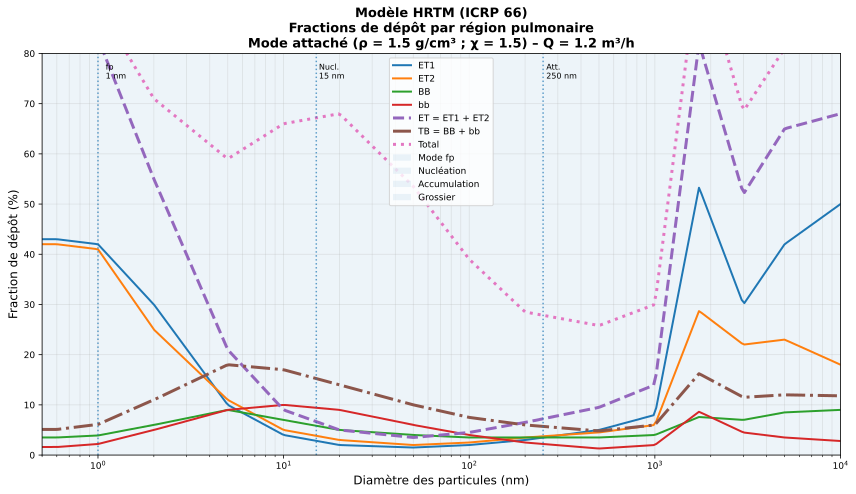

✅ Figure sauvegardée : depot_ET_TB_detaille.png
[Référence : ICRP 66 – Human Respiratory Tract Model]


In [16]:
# ============================================================
# CELLULE 8 – Dépôt pulmonaire détaillé et regroupé
# (Mode attaché : ρ=1.5 g/cm³ ; χ=1.5)
# ============================================================

# ------------------------------------------------------------
# Courbes regroupées
# ------------------------------------------------------------

ET_curve = curves_att['ET1'] + curves_att['ET2']
TB_curve = curves_att['BB'] + curves_att['bb']

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

# Régions détaillées

ax.plot(
    dp_range,
    curves_att['ET1'],
    lw=2,
    label='ET1'
)

ax.plot(
    dp_range,
    curves_att['ET2'],
    lw=2,
    label='ET2'
)

ax.plot(
    dp_range,
    curves_att['BB'],
    lw=2,
    label='BB'
)

ax.plot(
    dp_range,
    curves_att['bb'],
    lw=2,
    label='bb'
)

# ------------------------------------------------------------
# Régions regroupées
# ------------------------------------------------------------

ax.plot(
    dp_range,
    ET_curve,
    lw=3,
    ls='--',
    label='ET = ET1 + ET2'
)

ax.plot(
    dp_range,
    TB_curve,
    lw=3,
    ls='-.',
    label='TB = BB + bb'
)

# ------------------------------------------------------------
# Dépôt total
# ------------------------------------------------------------

ax.plot(
    dp_range,
    curves_att['Total'],
    lw=3,
    ls=':',
    label='Total'
)

# ------------------------------------------------------------
# Zones aérosols
# ------------------------------------------------------------

ax.axvspan(
    0.5, 3,
    alpha=0.08,
    label='Mode fp'
)

ax.axvspan(
    3, 50,
    alpha=0.08,
    label='Nucléation'
)

ax.axvspan(
    50, 500,
    alpha=0.08,
    label='Accumulation'
)

ax.axvspan(
    500, 10000,
    alpha=0.08,
    label='Grossier'
)

# ------------------------------------------------------------
# Marqueurs représentatifs
# ------------------------------------------------------------

ax.axvline(
    1,
    ls=':',
    lw=1.5,
    alpha=0.7
)

ax.axvline(
    15,
    ls=':',
    lw=1.5,
    alpha=0.7
)

ax.axvline(
    250,
    ls=':',
    lw=1.5,
    alpha=0.7
)

ax.text(
    1.1,
    75,
    'fp\n1 nm',
    fontsize=8
)

ax.text(
    15.5,
    75,
    'Nucl.\n15 nm',
    fontsize=8
)

ax.text(
    260,
    75,
    'Att.\n250 nm',
    fontsize=8
)

# ------------------------------------------------------------
# Mise en forme
# ------------------------------------------------------------

ax.set_xscale('log')

ax.set_xlabel(
    'Diamètre des particules (nm)',
    fontsize=12
)

ax.set_ylabel(
    'Fraction de dépôt (%)',
    fontsize=12
)

ax.set_title(
    'Modèle HRTM (ICRP 66)\n'
    f'Fractions de dépôt par région pulmonaire\n'
    f'Mode attaché (ρ = 1.5 g/cm³ ; χ = 1.5) – Q = {Q_m3h} m³/h',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlim(0.5, 10000)

ax.set_ylim(0, 80)

ax.grid(
    True,
    which='both',
    alpha=0.3
)

ax.legend(
    loc='best',
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    'depot_ET_TB_detaille.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Figure sauvegardée : depot_ET_TB_detaille.png")
print("[Référence : ICRP 66 – Human Respiratory Tract Model]")

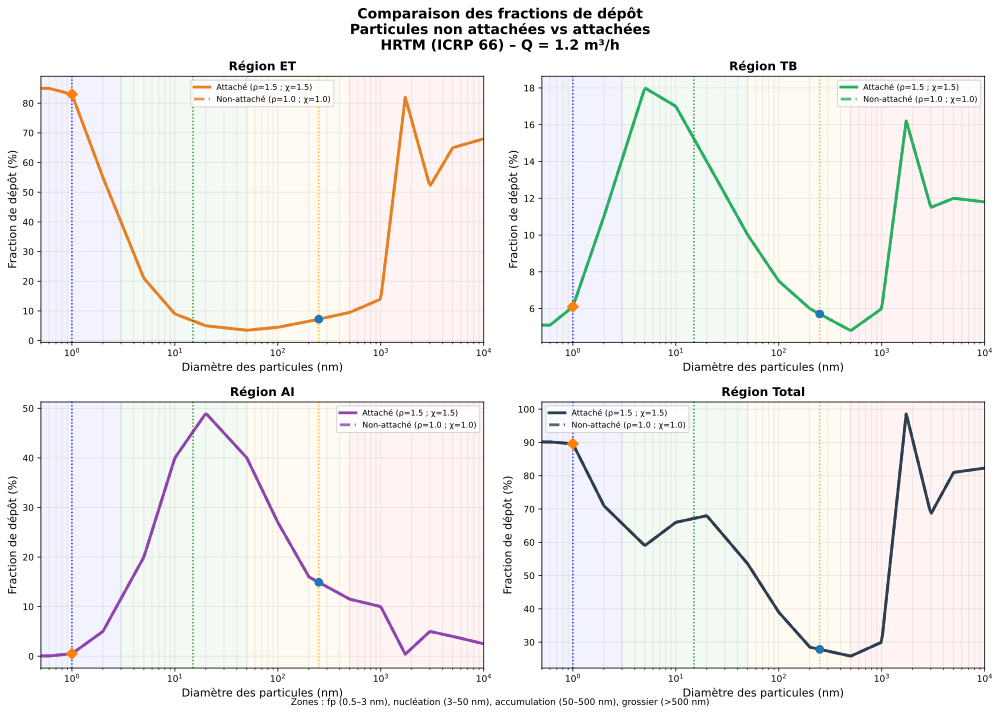

✅ Figure sauvegardée : comparaison_fp_vs_attache_ET_TB_AI_Total.png
[Référence : ICRP 66 – HRTM]


In [17]:
# ============================================================
# CELLULE 9 – COMPARAISON ATTACHÉ vs NON-ATTACHÉ
# Régions ET, TB, AI et Total
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Courbes regroupées
# ------------------------------------------------------------

ET_att = curves_att['ET1'] + curves_att['ET2']
TB_att = curves_att['BB']  + curves_att['bb']

ET_fp = curves_fp['ET1'] + curves_fp['ET2']
TB_fp = curves_fp['BB']  + curves_fp['bb']

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

regions = [
    ('ET',    ET_att,              ET_fp),
    ('TB',    TB_att,              TB_fp),
    ('AI',    curves_att['AI'],    curves_fp['AI']),
    ('Total', curves_att['Total'], curves_fp['Total'])
]

couleurs_comp = {
    'ET'    : '#E67E22',
    'TB'    : '#27AE60',
    'AI'    : '#8E44AD',
    'Total' : '#2C3E50'
}

for ax, (region, y_att, y_fp) in zip(axes.flatten(), regions):

    couleur = couleurs_comp[region]

    # --------------------------------------------------------
    # Courbe attachée
    # --------------------------------------------------------

    ax.plot(
        dp_range,
        y_att,
        color=couleur,
        lw=2.8,
        label='Attaché (ρ=1.5 ; χ=1.5)'
    )

    # --------------------------------------------------------
    # Courbe non attachée
    # --------------------------------------------------------

    ax.plot(
        dp_range,
        y_fp,
        color=couleur,
        lw=2.8,
        ls='--',
        alpha=0.8,
        label='Non-attaché (ρ=1.0 ; χ=1.0)'
    )

    # --------------------------------------------------------
    # Zones aérosols
    # --------------------------------------------------------

    ax.axvspan(
        0.5, 3,
        alpha=0.05,
        color='blue'
    )

    ax.axvspan(
        3, 50,
        alpha=0.05,
        color='green'
    )

    ax.axvspan(
        50, 500,
        alpha=0.05,
        color='orange'
    )

    ax.axvspan(
        500, 10000,
        alpha=0.05,
        color='red'
    )

    # --------------------------------------------------------
    # Diamètres représentatifs
    # --------------------------------------------------------

    ax.axvline(
        1,
        color='blue',
        ls=':',
        lw=1.3
    )

    ax.axvline(
        15,
        color='green',
        ls=':',
        lw=1.3
    )

    ax.axvline(
        250,
        color='orange',
        ls=':',
        lw=1.3
    )

    # --------------------------------------------------------
    # Points représentatifs
    # --------------------------------------------------------

    if region == 'ET':

        y1_att = deposition_fractions(
            250,
            rho=1.5,
            chi=1.5,
            Q_m3h=Q_m3h
        )['ET1'] + deposition_fractions(
            250,
            rho=1.5,
            chi=1.5,
            Q_m3h=Q_m3h
        )['ET2']

        y1_fp = deposition_fractions(
            1,
            rho=1.0,
            chi=1.0,
            Q_m3h=Q_m3h
        )['ET1'] + deposition_fractions(
            1,
            rho=1.0,
            chi=1.0,
            Q_m3h=Q_m3h
        )['ET2']

    elif region == 'TB':

        res_att = deposition_fractions(
            250,
            rho=1.5,
            chi=1.5,
            Q_m3h=Q_m3h
        )

        res_fp = deposition_fractions(
            1,
            rho=1.0,
            chi=1.0,
            Q_m3h=Q_m3h
        )

        y1_att = res_att['BB'] + res_att['bb']
        y1_fp  = res_fp['BB']  + res_fp['bb']

    else:

        y1_att = deposition_fractions(
            250,
            rho=1.5,
            chi=1.5,
            Q_m3h=Q_m3h
        )[region]

        y1_fp = deposition_fractions(
            1,
            rho=1.0,
            chi=1.0,
            Q_m3h=Q_m3h
        )[region]

    ax.scatter(
        250,
        y1_att,
        s=60,
        marker='o',
        zorder=6
    )

    ax.scatter(
        1,
        y1_fp,
        s=60,
        marker='D',
        zorder=6
    )

    # --------------------------------------------------------
    # Mise en forme
    # --------------------------------------------------------

    ax.set_xscale('log')

    ax.set_xlim(0.5, 10000)

    ax.set_xlabel(
        'Diamètre des particules (nm)'
    )

    ax.set_ylabel(
        'Fraction de dépôt (%)'
    )

    ax.set_title(
        f'Région {region}',
        fontsize=12,
        fontweight='bold'
    )

    ax.grid(
        True,
        which='both',
        alpha=0.3
    )

    ax.legend(
        fontsize=8
    )

# ------------------------------------------------------------
# Titre général
# ------------------------------------------------------------

fig.suptitle(
    'Comparaison des fractions de dépôt\n'
    'Particules non attachées vs attachées\n'
    f'HRTM (ICRP 66) – Q = {Q_m3h} m³/h',
    fontsize=14,
    fontweight='bold'
)

# ------------------------------------------------------------
# Note
# ------------------------------------------------------------

fig.text(
    0.5,
    0.01,
    'Zones : fp (0.5–3 nm), nucléation (3–50 nm), accumulation (50–500 nm), grossier (>500 nm)',
    ha='center',
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    'comparaison_fp_vs_attache_ET_TB_AI_Total.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Figure sauvegardée : comparaison_fp_vs_attache_ET_TB_AI_Total.png")
print("[Référence : ICRP 66 – HRTM]")

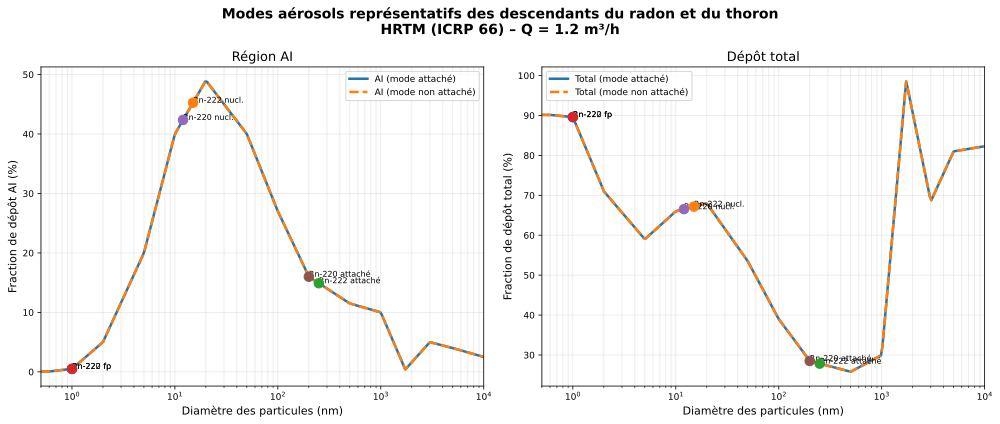

✅ Figure sauvegardée : modes_radon_thoron_AI_Total.png
[Référence : ICRP 66 – HRTM]


In [18]:
# ============================================================
# CELLULE 10 – MODES AÉROSOLS REPRÉSENTATIFS
# Descendants du Radon-222 et du Thoron-220
# ============================================================

# ------------------------------------------------------------
# Courbes regroupées
# ------------------------------------------------------------

ET_att = curves_att['ET1'] + curves_att['ET2']
TB_att = curves_att['BB'] + curves_att['bb']

# ------------------------------------------------------------
# Diamètres représentatifs
# ------------------------------------------------------------

modes_data = {
    'Rn-222 fp'       : {'dp':1.0,   'rho':1.0, 'chi':1.0},
    'Rn-222 nucl.'    : {'dp':15.0,  'rho':1.5, 'chi':1.0},
    'Rn-222 attaché'  : {'dp':250.0, 'rho':1.5, 'chi':1.5},

    'Rn-220 fp'       : {'dp':1.0,   'rho':1.0, 'chi':1.0},
    'Rn-220 nucl.'    : {'dp':12.0,  'rho':1.5, 'chi':1.0},
    'Rn-220 attaché'  : {'dp':200.0, 'rho':1.5, 'chi':1.5}
}

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ============================================================
# GRAPHE 1 : AI
# ============================================================

ax = axes[0]

ax.plot(
    dp_range,
    curves_att['AI'],
    lw=2.5,
    label='AI (mode attaché)'
)

ax.plot(
    dp_range,
    curves_fp['AI'],
    lw=2.5,
    ls='--',
    label='AI (mode non attaché)'
)

for nom, mp in modes_data.items():

    y = deposition_fractions(
        dp_nm=mp['dp'],
        rho=mp['rho'],
        chi=mp['chi'],
        Q_m3h=Q_m3h
    )['AI']

    ax.scatter(
        mp['dp'],
        y,
        s=90,
        zorder=6
    )

    ax.annotate(
        nom,
        (mp['dp'], y),
        fontsize=8
    )

ax.set_xscale('log')
ax.set_xlim(0.5, 10000)

ax.set_xlabel('Diamètre des particules (nm)')
ax.set_ylabel('Fraction de dépôt AI (%)')

ax.set_title(
    'Région AI'
)

ax.grid(True, which='both', alpha=0.3)

ax.legend()

# ============================================================
# GRAPHE 2 : TOTAL
# ============================================================

ax = axes[1]

ax.plot(
    dp_range,
    curves_att['Total'],
    lw=2.5,
    label='Total (mode attaché)'
)

ax.plot(
    dp_range,
    curves_fp['Total'],
    lw=2.5,
    ls='--',
    label='Total (mode non attaché)'
)

for nom, mp in modes_data.items():

    y = deposition_fractions(
        dp_nm=mp['dp'],
        rho=mp['rho'],
        chi=mp['chi'],
        Q_m3h=Q_m3h
    )['Total']

    ax.scatter(
        mp['dp'],
        y,
        s=90,
        zorder=6
    )

    ax.annotate(
        nom,
        (mp['dp'], y),
        fontsize=8
    )

ax.set_xscale('log')
ax.set_xlim(0.5, 10000)

ax.set_xlabel('Diamètre des particules (nm)')
ax.set_ylabel('Fraction de dépôt total (%)')

ax.set_title(
    'Dépôt total'
)

ax.grid(True, which='both', alpha=0.3)

ax.legend()

# ------------------------------------------------------------
# Titre général
# ------------------------------------------------------------

fig.suptitle(
    'Modes aérosols représentatifs des descendants du radon et du thoron\n'
    f'HRTM (ICRP 66) – Q = {Q_m3h} m³/h',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'modes_radon_thoron_AI_Total.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Figure sauvegardée : modes_radon_thoron_AI_Total.png")
print("[Référence : ICRP 66 – HRTM]")

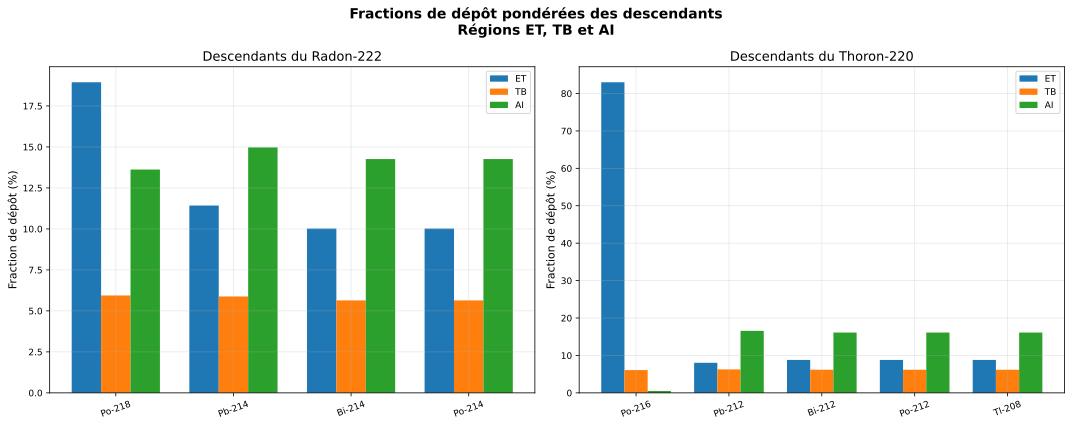

✅ Figure sauvegardée : depot_pondere_descendants.png


In [19]:
# ============================================================
# CELLULE 11 – Synthèse des descendants du Radon et du Thoron
# Dépôts pondérés ET, TB et AI
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Préparation des données
# ------------------------------------------------------------

df_rn222_plot = df_rn222_weighted.copy()
df_rn220_plot = df_rn220_weighted.copy()

# Création des régions regroupées
df_rn222_plot['ET'] = df_rn222_plot['ET1'] + df_rn222_plot['ET2']
df_rn222_plot['TB'] = df_rn222_plot['BB'] + df_rn222_plot['bb']

df_rn220_plot['ET'] = df_rn220_plot['ET1'] + df_rn220_plot['ET2']
df_rn220_plot['TB'] = df_rn220_plot['BB'] + df_rn220_plot['bb']

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ============================================================
# Radon-222
# ============================================================

ax = axes[0]

x = np.arange(len(df_rn222_plot.index))
w = 0.25

ax.bar(x - w, df_rn222_plot['ET'], width=w, label='ET')
ax.bar(x,     df_rn222_plot['TB'], width=w, label='TB')
ax.bar(x + w, df_rn222_plot['AI'], width=w, label='AI')

ax.set_xticks(x)
ax.set_xticklabels(df_rn222_plot.index, rotation=20)

ax.set_ylabel('Fraction de dépôt (%)')

ax.set_title(
    'Descendants du Radon-222'
)

ax.legend()

ax.grid(
    axis='y',
    alpha=0.3
)

# ============================================================
# Thoron-220
# ============================================================

ax = axes[1]

x = np.arange(len(df_rn220_plot.index))

ax.bar(x - w, df_rn220_plot['ET'], width=w, label='ET')
ax.bar(x,     df_rn220_plot['TB'], width=w, label='TB')
ax.bar(x + w, df_rn220_plot['AI'], width=w, label='AI')

ax.set_xticks(x)
ax.set_xticklabels(df_rn220_plot.index, rotation=20)

ax.set_ylabel('Fraction de dépôt (%)')

ax.set_title(
    'Descendants du Thoron-220'
)

ax.legend()

ax.grid(
    axis='y',
    alpha=0.3
)

# ------------------------------------------------------------
# Titre général
# ------------------------------------------------------------

fig.suptitle(
    'Fractions de dépôt pondérées des descendants\n'
    'Régions ET, TB et AI',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'depot_pondere_descendants.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Figure sauvegardée : depot_pondere_descendants.png")

INHALATION
    │
    ▼
DÉPÔT dans ET1, ET2, BB, bb, AI   ← (résultats notebook précédent, recalculés ici)
    │
    ├── Clairance mucociliaire (ET1→ET2→BB→bb→GI tract)   ← ICRP 66 Table 9
    ├── Absorption sanguine (type F/M/S)                   ← ICRP 66 Section 5
    └── Rétention dans les compartiments                   ← Système d'ODE
            │
            ▼
        ACTIVITÉ déposée dans chaque tissu (Bq)
            │
            ▼
        DOSE ABSORBÉE (Gy) = Energie / Masse
            │
            ▼
        DOSE ÉQUIVALENTE (Sv) = D × w_R
            │
            ▼
        DOSE EFFICACE (Sv) = Σ_T (H_T × w_T)


In [20]:
# ============================================================
# CELLULE 1 – Données nucléaires des isotopes
# ============================================================
#
# Sources :
#   ICRP 137 (2017), Table 1 & 2  – chaînes de désintégration
#   ICRP 107 (2008)               – données nucléaires (T1/2, énergie)
#   NNDC / ENSDF                  – énergies moyennes par désintégration
#
# Energie moyenne par désintégration (MeV) :
#   Source : ICRP Publication 107 (2008) – Nuclear Decay Data for Dosimetric Calculations
#   Format : E_alpha (MeV), E_beta (MeV), E_gamma (MeV)
#
# ln(2) / T1/2 → constante de désintégration λ [s⁻¹]

LN2 = np.log(2)

# --- Chaîne Radon-222 (ICRP 137 Table 1 ; ICRP 107)
# Les énergies alpha sont les énergies cinétiques de la particule alpha
# Les énergies beta sont les énergies moyennes de l'électron
isotopes_rn222 = {
    'Rn-222': {
        'T_half_s': 3.8235 * 86400,   # 3.8235 jours → secondes
        'E_alpha': 5.4895,             # MeV (ICRP 107)
        'E_beta' : 0.0,
        'E_gamma': 0.0,
        'type'   : 'alpha',
        'w_R'    : 20,                 # ICRP 103 Table 2 : w_R = 20 pour alpha
        'gaz'    : True                # gaz noble, dépôt gazeux
    },
    'Po-218': {
        'T_half_s': 3.05 * 60,        # 3.05 min
        'E_alpha': 6.0025,             # MeV
        'E_beta' : 0.0,
        'E_gamma': 0.0,
        'type'   : 'alpha',
        'w_R'    : 20,
        'gaz'    : False
    },
    'Pb-214': {
        'T_half_s': 26.8 * 60,        # 26.8 min
        'E_alpha': 0.0,
        'E_beta' : 0.2239,             # MeV (énergie β moyenne, ICRP 107)
        'E_gamma': 0.2483,             # MeV (somme gamma, ICRP 107)
        'type'   : 'beta',
        'w_R'    : 1,                  # ICRP 103 : w_R = 1 pour β, γ
        'gaz'    : False
    },
    'Bi-214': {
        'T_half_s': 19.7 * 60,        # 19.7 min
        'E_alpha': 0.0,
        'E_beta' : 0.6568,             # MeV
        'E_gamma': 1.5078,             # MeV
        'type'   : 'beta',
        'w_R'    : 1,
        'gaz'    : False
    },
    'Po-214': {
        'T_half_s': 164.3e-6,         # 164.3 µs
        'E_alpha': 7.6869,             # MeV
        'E_beta' : 0.0,
        'E_gamma': 0.0,
        'type'   : 'alpha',
        'w_R'    : 20,
        'gaz'    : False
    },
    'Pb-210': {
        'T_half_s': 22.3 * 365.25 * 86400,  # 22.3 ans
        'E_alpha': 0.0,
        'E_beta' : 0.00397,            # MeV (faible)
        'E_gamma': 0.0465,
        'type'   : 'beta',
        'w_R'    : 1,
        'gaz'    : False
    },
}

# --- Chaîne Thoron-220 (ICRP 137 Table 2 ; ICRP 107)
isotopes_rn220 = {
    'Rn-220': {
        'T_half_s': 55.6,              # 55.6 s
        'E_alpha': 6.2883,             # MeV
        'E_beta' : 0.0,
        'E_gamma': 0.0,
        'type'   : 'alpha',
        'w_R'    : 20,
        'gaz'    : True
    },
    'Po-216': {
        'T_half_s': 0.145,             # 0.145 s
        'E_alpha': 6.7784,             # MeV
        'E_beta' : 0.0,
        'E_gamma': 0.0,
        'type'   : 'alpha',
        'w_R'    : 20,
        'gaz'    : False
    },
    'Pb-212': {
        'T_half_s': 10.64 * 3600,      # 10.64 h
        'E_alpha': 0.0,
        'E_beta' : 0.1016,             # MeV
        'E_gamma': 0.1188,
        'type'   : 'beta',
        'w_R'    : 1,
        'gaz'    : False
    },
    'Bi-212': {
        'T_half_s': 60.55 * 60,        # 60.55 min
        'E_alpha': 6.090,             # MeV (branche α 36%)
        'E_beta' : 0.624,             # MeV (branche β 64%)
        'E_gamma': 0.370,
        'branch_alpha'  : 0.36,
        'branch_beta'  : 0.64,
        'type'   : 'alpha+beta',
        #'w_R'    : 'mixte',  # Conservatif (dominé par α)
        'w_R'    : 20,
        'gaz'    : False
    },
    'Po-212': {
        'T_half_s': 299e-9,            # 299 ns – suit Bi-212 instantanément
        'E_alpha': 8.7844,             # MeV
        'E_beta' : 0.0,
        'E_gamma': 0.0,
        'type'   : 'alpha',
        'w_R'    : 20,
        'gaz'    : False
    },
    'Tl-208': {
        'T_half_s': 3.053 * 60,        # 3.053 min
        'E_alpha': 0.0,
        'E_beta' : 0.5589,             # MeV
        'E_gamma': 3.9075,             # MeV (émetteur γ fort !)
        'branch_beta'  : 1.0,
        'type'   : 'beta',
        'w_R'    : 1,
        'gaz'    : False
    },
}

# Calcul des constantes de désintégration
for chain in [isotopes_rn222, isotopes_rn220]:
    for iso, data in chain.items():
        data['lambda'] = LN2 / data['T_half_s']   # s⁻¹
        data['lambda_h']= data['lambda']*3600     # h⁻¹
        data['lambda_jo']= data['lambda']*86400    # jo⁻¹
        # Énergie totale par désintégration (MeV)

        if 'branch_alpha' in data or 'branch_beta' in data:
            data['E_mean'] = (data.get('branch_alpha', 0.0) * data['E_alpha'] + 
                              data.get('branch_beta', 0.0) * data['E_beta'] + 
                              data['E_gamma'])
        else:
            data['E_mean'] = data['E_alpha'] + data['E_beta'] + data['E_gamma']
        #data['E_total'] = data['E_alpha'] + data['E_beta'] + data['E_gamma']
        MEV_TO_J = 1.602176634e-13

        data['E_mean_J'] = (
            data['E_mean']
            * MEV_TO_J
        )

# Affichage
print("CHAÎNE Rn-222 – Données nucléaires (ICRP 107, ICRP 137)")
print("-"*75)
rows = []
for iso, d in isotopes_rn222.items():
    rows.append({
        'Isotope': iso,
        'T1/2': f"{d['T_half_s']:.3g} s",
        'λ (s⁻¹)': f"{d['lambda']:.3e}",
        'λ (h⁻¹)': f"{d['lambda_h']:.3e}",
        'λ (jo⁻¹)': f"{d['lambda_jo']:.3e}",
        'E_α (MeV)': d['E_alpha'],
        'E_β (MeV)': d['E_beta'],
        'E_γ (MeV)': d['E_gamma'],
        'E_mean (MeV)':d['E_mean'],
        'E_mean_J':d['E_mean_J'],
        'Type': d['type'],
        'w_R': d['w_R']
    })
df_nuc_rn222 = pd.DataFrame(rows)
print(df_nuc_rn222.to_string(index=False))

print("\nCHAÎNE Rn-220 – Données nucléaires (ICRP 107, ICRP 137)")
print("-"*75)
rows = []
for iso, d in isotopes_rn220.items():
    rows.append({
        'Isotope': iso,
        'T1/2': f"{d['T_half_s']:.3g} s",
        'λ (s⁻¹)': f"{d['lambda']:.3e}",
        'λ (h⁻¹)': f"{d['lambda_h']:.3e}",
        'λ (jo⁻¹)': f"{d['lambda_jo']:.3e}",
        'E_α (MeV)': d['E_alpha'],
        'E_β (MeV)': d['E_beta'],
        'E_γ (MeV)': d['E_gamma'],
        'E_mean (MeV)':d['E_mean'],
        'E_mean_J':d['E_mean_J'],
        'Type': d['type'],
        'w_R': d['w_R']
    })
df_nuc_rn220 = pd.DataFrame(rows)
print(df_nuc_rn220.to_string(index=False))

print("\n[Sources : ICRP 107 (2008), ICRP 137 (2017), NNDC/ENSDF]")

CHAÎNE Rn-222 – Données nucléaires (ICRP 107, ICRP 137)
---------------------------------------------------------------------------
Isotope       T1/2   λ (s⁻¹)   λ (h⁻¹)  λ (jo⁻¹)  E_α (MeV)  E_β (MeV)  E_γ (MeV)  E_mean (MeV)     E_mean_J  Type  w_R
 Rn-222  3.3e+05 s 2.098e-06 7.554e-03 1.813e-01     5.4895    0.00000     0.0000       5.48950 8.795149e-13 alpha   20
 Po-218      183 s 3.788e-03 1.364e+01 3.273e+02     6.0025    0.00000     0.0000       6.00250 9.617065e-13 alpha   20
 Pb-214 1.61e+03 s 4.311e-04 1.552e+00 3.724e+01     0.0000    0.22390     0.2483       0.47220 7.565478e-14  beta    1
 Bi-214 1.18e+03 s 5.864e-04 2.111e+00 5.067e+01     0.0000    0.65680     1.5078       2.16460 3.468072e-13  beta    1
 Po-214 0.000164 s 4.219e+03 1.519e+07 3.645e+08     7.6869    0.00000     0.0000       7.68690 1.231577e-12 alpha   20
 Pb-210 7.04e+08 s 9.850e-10 3.546e-06 8.510e-05     0.0000    0.00397     0.0465       0.05047 8.086185e-15  beta    1

CHAÎNE Rn-220 – Données nuc

In [21]:
# ============================================================
# CELLULE 2 – Compartiments ICRP 66 et paramètres de clairance
# ============================================================
#
# Le modèle HRTM (ICRP 66, Section 5) divise chaque région en
# compartiments avec des taux de transfert spécifiques.
#
# Structure des compartiments (ICRP 66, Figure 5 & Table 9) :
#
#  ET1  → ET2  (clearance muco-ciliaire rapide ET1)
#  ET2  → GIT  (clearance ET2 vers tractus gastro-intestinal)
#  BB   → ET2  (clearance mucociliaire bronchique)
#  bb   → BB   (clearance mucociliaire bronchiolaire)
#  AI1  → bb   (clearance alvéolaire lente)
#  AI2  → AI1  (compartiment interstitiel)
#  AI3  → sang (transfert lymphatique)
#
# Taux de transfert (m_ij) en jours⁻¹ (ICRP 66, Table 9, p.47)
# Convertis en s⁻¹ pour le calcul
#
# Absorption sanguine : type F (fast), M (medium), S (slow)
# Pour le radon et thoron : Type V (vapeur/gaz) ≠ particules
# Pour les descendants : Type F principalement (ICRP 137 Table 3)
#
# Réf. : ICRP 66 (1994), Section 5, Table 9 et Table 11
#        ICRP 130 (2015), Appendix A
#        ICRP 137 (2017), Section 3.3 et 4.3

# Taux de clairance mucociliaire [j⁻¹] → [s⁻¹]
# Source : ICRP 66, Table 9 (p.47) – valeurs pour le travailleur de référence
JOURS = 86400.0  # secondes par jour

# Compartiments ET1
# m_ET1_ET2  : transfert ET1→ET2 (clearance très rapide)
m_ET1_ET2 = 1.0 / JOURS           # ICRP 66 Table 9 : T1/2 = 1 jour ≈ 1 j⁻¹

# Compartiments ET2
# m_ET2_GIT : transfert ET2→Tractus GI (déglutition)
m_ET2_GIT = 100.0 / JOURS         # ICRP 66 Table 9 : 100 j⁻¹

# Compartiments BB (bronches)
# BB_fast (cilié rapide) et BB_slow (moins cilié)
m_BBfast_ET2 = 10.0  / JOURS      # ICRP 66 Table 9 : 10 j⁻¹
m_BBslow_ET2 = 0.03  / JOURS      # ICRP 66 Table 9 : 0.03 j⁻¹

# Fractions de dépôt dans BBfast vs BBslow (ICRP 66 Table 9)
f_BB_fast = 0.993                  # 99.3% dans la couche ciliée rapide
f_BB_slow = 0.007                  # 0.7% dans la couche plus lente

# Compartiments bb (bronchioles)
m_bbfast_BB  = 2.0   / JOURS      # ICRP 66 Table 9 : 2 j⁻¹
m_bbslow_BB  = 0.03  / JOURS      # ICRP 66 Table 9 : 0.03 j⁻¹
f_bb_fast = 0.993
f_bb_slow = 0.007

# Compartiments AI (alvéolaire-interstitiel)
# 3 sous-compartiments : AI1, AI2, AI3
m_AI1_bb   = 0.02   / JOURS       # ICRP 66 Table 9 : 0.02 j⁻¹ (lent)
m_AI2_AI1  = 0.001  / JOURS       # ICRP 66 Table 9 : 0.001 j⁻¹ (très lent)
m_AI3_sang = 0.0001 / JOURS       # ICRP 66 Table 9 : 0.0001 j⁻¹ (transfert lymphatique)

# Fractions dans AI1, AI2, AI3 (ICRP 66 Table 9)
f_AI1 = 0.3   # 30%
f_AI2 = 0.6   # 60%
f_AI3 = 0.1   # 10%

# Absorption sanguine pour les descendants du radon/thoron
# Type F (Fast) : ICRP 137, Table 3 – recommandé pour Pb, Bi, Po inhalés
# s_F = taux d'absorption depuis les compartiments vers le sang
# ICRP 66 Table 11 : Type F → s = 100 j⁻¹
s_F = 100.0 / JOURS               # Type F (fast absorption) – Pb, Bi, Po
s_M = 10.0  / JOURS               # Type M (medium)
s_S = 0.1   / JOURS               # Type S (slow)

# Pour le radon gazeux : absorption par diffusion gazeuse depuis AI
# ICRP 137, Section 3.3 : f_1 = 1.0 (absorption totale pour Rn gazeux)
# Le radon dissous dans le sang est exhale rapidement (T1/2 ~ 1 min)
s_Rn = 1000.0 / JOURS             # Rn gazeux : absorption rapide

# Masses des tissus (homme de référence, ICRP 66 Annexe B, Table B.2)
masses_g = {
    'ET1' : 3.0,      # g
    'ET2' : 3.0,      # g
    'BB'  : 2.0,      # g (épithélium bronchique)
    'bb'  : 1.5,      # g (épithélium bronchiolaire)
    'AI'  : 600.0,    # g (tissu alvéolaire total)
    'GIT' : 400.0,    # g (tractus GI pour ingestion secondaire)
    'Sang': 5400.0,   # g (5.4 L de sang)
}

print("PARAMÈTRES DE CLAIRANCE MUCOCILIAIRE (ICRP 66, Table 9)")
print("-"*60)
data_clearance = [
    ['ET1 → ET2',   f"{m_ET1_ET2*JOURS:.0f} j⁻¹",  f"T1/2 = {LN2/m_ET1_ET2/3600:.1f} h"],
    ['ET2 → GIT',   f"{m_ET2_GIT*JOURS:.0f} j⁻¹",  f"T1/2 = {LN2/m_ET2_GIT/60:.1f} min"],
    ['BBfast→ET2',  f"{m_BBfast_ET2*JOURS:.1f} j⁻¹",f"T1/2 = {LN2/m_BBfast_ET2/3600:.1f} h"],
    ['BBslow→ET2',  f"{m_BBslow_ET2*JOURS:.3f} j⁻¹",f"T1/2 = {LN2/m_BBslow_ET2/JOURS:.0f} j"],
    ['bbfast→BB',   f"{m_bbfast_BB*JOURS:.1f} j⁻¹", f"T1/2 = {LN2/m_bbfast_BB/3600:.0f} h"],
    ['bbslow→BB',   f"{m_bbslow_BB*JOURS:.3f} j⁻¹", f"T1/2 = {LN2/m_bbslow_BB/JOURS:.0f} j"],
    ['AI1 → bb',    f"{m_AI1_bb*JOURS:.3f} j⁻¹",    f"T1/2 = {LN2/m_AI1_bb/JOURS:.0f} j"],
    ['AI2 → AI1',   f"{m_AI2_AI1*JOURS:.4f} j⁻¹",   f"T1/2 = {LN2/m_AI2_AI1/JOURS:.0f} j"],
    ['AI3 → sang',  f"{m_AI3_sang*JOURS:.5f} j⁻¹",  f"T1/2 = {LN2/m_AI3_sang/JOURS:.0f} j"],
]
df_cl = pd.DataFrame(data_clearance, columns=['Transfert', 'Taux', 'T1/2 effectif'])
print(df_cl.to_string(index=False))
print("\n[Source : ICRP 66 (1994) Table 9, p. 47]")
print("[Absorption sanguine type F : 100 j⁻¹ – ICRP 66 Table 11 & ICRP 137 Table 3]")

PARAMÈTRES DE CLAIRANCE MUCOCILIAIRE (ICRP 66, Table 9)
------------------------------------------------------------
 Transfert        Taux   T1/2 effectif
 ET1 → ET2       1 j⁻¹   T1/2 = 16.6 h
 ET2 → GIT     100 j⁻¹ T1/2 = 10.0 min
BBfast→ET2    10.0 j⁻¹    T1/2 = 1.7 h
BBslow→ET2   0.030 j⁻¹     T1/2 = 23 j
 bbfast→BB     2.0 j⁻¹      T1/2 = 8 h
 bbslow→BB   0.030 j⁻¹     T1/2 = 23 j
  AI1 → bb   0.020 j⁻¹     T1/2 = 35 j
 AI2 → AI1  0.0010 j⁻¹    T1/2 = 693 j
AI3 → sang 0.00010 j⁻¹   T1/2 = 6931 j

[Source : ICRP 66 (1994) Table 9, p. 47]
[Absorption sanguine type F : 100 j⁻¹ – ICRP 66 Table 11 & ICRP 137 Table 3]


In [22]:
# ============================================================
# CELLULE 15 – Exposition et dépôt des gaz Rn-222 et Rn-220
# ============================================================
#
# Objectif :
# Calculer l'activité inhalée annuelle des gaz radon et thoron
# ainsi que leur activité déposée dans les différentes régions
# pulmonaires.
#
# Source :
#   ICRP 137 (2017), Table 5
#   UNSCEAR 2000, Annex B
#
# Remarque :
# Les fractions ci-dessous concernent UNIQUEMENT les gaz
# Rn-222 et Rn-220.
#
# Les descendants (Po, Pb, Bi, Tl) sont traités séparément
# avec le modèle HRTM développé dans les cellules précédentes.
# ============================================================

# ------------------------------------------------------------
# Dépôt du gaz Rn-222 (ICRP 137 Table 5)
# ------------------------------------------------------------

depot_gaz_rn222 = {
    'ET1': 0.17,
    'ET2': 0.30,
    'BB' : 0.09,
    'bb' : 0.07,
    'AI' : 0.26
}

# ------------------------------------------------------------
# Dépôt du gaz Rn-220 (ICRP 137 Table 5)
# ------------------------------------------------------------

depot_gaz_rn220 = {
    'ET1': 0.17,
    'ET2': 0.31,
    'BB' : 0.09,
    'bb' : 0.07,
    'AI' : 0.26
}

# ------------------------------------------------------------
# Paramètres d'exposition
# ------------------------------------------------------------

C_Rn222_Bq_m3 = 50.0      # Bq/m³
C_Rn220_Bq_m3 = 20.0      # Bq/m³

Q_m3h = 1.2               # m³/h
T_exp_h = 7000            # h/an

SECONDS_PER_YEAR = T_exp_h * 3600

# ------------------------------------------------------------
# Activité inhalée annuelle
# ------------------------------------------------------------

A_inh_Rn222 = (
    C_Rn222_Bq_m3 *
    Q_m3h *
    T_exp_h
)

A_inh_Rn220 = (
    C_Rn220_Bq_m3 *
    Q_m3h *
    T_exp_h
)

# ------------------------------------------------------------
# Débit d'activité inhalée
# (utile pour la biocinétique)
# ------------------------------------------------------------

A_rate_Rn222 = (
    C_Rn222_Bq_m3 *
    Q_m3h /
    3600
)

A_rate_Rn220 = (
    C_Rn220_Bq_m3 *
    Q_m3h /
    3600
)

# ------------------------------------------------------------
# Activité déposée dans chaque région
# ------------------------------------------------------------

A_dep_Rn222 = {
    reg: A_inh_Rn222 * frac
    for reg, frac in depot_gaz_rn222.items()
}

A_dep_Rn220 = {
    reg: A_inh_Rn220 * frac
    for reg, frac in depot_gaz_rn220.items()
}

# ------------------------------------------------------------
# Tableau récapitulatif
# ------------------------------------------------------------

df_gaz = pd.DataFrame({

    'Région': ['ET1', 'ET2', 'BB', 'bb', 'AI'],

    'Rn-222 dépôt (%)': [
        100 * depot_gaz_rn222[r]
        for r in depot_gaz_rn222
    ],

    'Rn-222 activité déposée (Bq/an)': [
        A_dep_Rn222[r]
        for r in depot_gaz_rn222
    ],

    'Rn-220 dépôt (%)': [
        100 * depot_gaz_rn220[r]
        for r in depot_gaz_rn220
    ],

    'Rn-220 activité déposée (Bq/an)': [
        A_dep_Rn220[r]
        for r in depot_gaz_rn220
    ]
})

# ------------------------------------------------------------
# Affichage
# ------------------------------------------------------------

print("EXPOSITION ANNUELLE AUX GAZ Rn-222 ET Rn-220")
print("-"*65)

print(f"Rn-222 : {C_Rn222_Bq_m3:.1f} Bq/m³")
print(f"Rn-220 : {C_Rn220_Bq_m3:.1f} Bq/m³")
print(f"Débit respiratoire : {Q_m3h:.2f} m³/h")
print(f"Temps d'exposition : {T_exp_h:.0f} h/an")

print("\nActivité inhalée :")
print(f"Rn-222 : {A_inh_Rn222:.3e} Bq/an")
print(f"Rn-220 : {A_inh_Rn220:.3e} Bq/an")

print("\nDébit d'activité inhalée :")
print(f"Rn-222 : {A_rate_Rn222:.4e} Bq/s")
print(f"Rn-220 : {A_rate_Rn220:.4e} Bq/s")

print("\nFractions de dépôt du gaz")
print("-"*65)

display(df_gaz)

print(
    f"\nFraction totale déposée Rn-222 : "
    f"{sum(depot_gaz_rn222.values()):.2f}"
)

print(
    f"Fraction totale déposée Rn-220 : "
    f"{sum(depot_gaz_rn220.values()):.2f}"
)

print("\n[Sources : ICRP 137 (2017) Table 5 ; UNSCEAR 2000]")

EXPOSITION ANNUELLE AUX GAZ Rn-222 ET Rn-220
-----------------------------------------------------------------
Rn-222 : 50.0 Bq/m³
Rn-220 : 20.0 Bq/m³
Débit respiratoire : 1.20 m³/h
Temps d'exposition : 7000 h/an

Activité inhalée :
Rn-222 : 4.200e+05 Bq/an
Rn-220 : 1.680e+05 Bq/an

Débit d'activité inhalée :
Rn-222 : 1.6667e-02 Bq/s
Rn-220 : 6.6667e-03 Bq/s

Fractions de dépôt du gaz
-----------------------------------------------------------------


,Région,Rn-222 dépôt (%),Rn-222 activité déposée (Bq/an),Rn-220 dépôt (%),Rn-220 activité déposée (Bq/an)
0,ET1,17.0,71400.0,17.0,28560.0
1,ET2,30.0,126000.0,31.0,52080.0
2,BB,9.0,37800.0,9.0,15120.0
3,bb,7.0,29400.0,7.0,11760.0
4,AI,26.0,109200.0,26.0,43680.0



Fraction totale déposée Rn-222 : 0.89
Fraction totale déposée Rn-220 : 0.90

[Sources : ICRP 137 (2017) Table 5 ; UNSCEAR 2000]


In [23]:
# ============================================================
# CELLULE 17– Modèle biocinétique HRTM ICRP 66 (corrigé)
# ============================================================
#
# Compartiments :
#
# 0  ET1
# 1  ET2
# 2  BBfast
# 3  BBslow
# 4  bbfast
# 5  bbslow
# 6  AI1
# 7  AI2
# 8  AI3
# 9  Sang
# 10 GIT
#
# Équation générale :
#
# dAj/dt =
#   + transferts entrants
#   + inhalation
#   - décroissance radioactive
#   - absorption sanguine
#   - transferts sortants
#
# Réf. :
# ICRP 66 (1994), Section 5
# ICRP 130 (2015), Appendix A
# ============================================================

from scipy.integrate import solve_ivp
import numpy as np


def biokinetic_model(t, A, lam, m_out, m_in, s_abs, source_rates):

    dAdt = np.zeros(11)

    # --------------------------------------------------------
    # PERTES
    # --------------------------------------------------------

    for j in range(9):  # compartiments pulmonaires

        loss_rate = (
            lam +
            s_abs.get(j, 0.0) +
            m_out.get(j, 0.0)
        )

        dAdt[j] -= loss_rate * A[j]

    # --------------------------------------------------------
    # TRANSFERTS ENTRANTS
    # --------------------------------------------------------

    for dest, (src, rate) in m_in.items():

        if isinstance(src, list):

            for s, r in zip(src, rate):
                dAdt[dest] += r * A[s]

        else:

            dAdt[dest] += rate * A[src]

    # --------------------------------------------------------
    # INHALATION CONTINUE
    # --------------------------------------------------------

    dAdt += source_rates

    # --------------------------------------------------------
    # ABSORPTION VERS LE SANG
    # --------------------------------------------------------

    for j in range(9):

        dAdt[9] += (
            s_abs.get(j, 0.0)
            * A[j]
        )

    # --------------------------------------------------------
    # AI3 → SANG (transfert lymphatique)
    # --------------------------------------------------------

    dAdt[9] += m_AI3_sang * A[8]

    # décroissance dans le sang

    dAdt[9] -= lam * A[9]

    # --------------------------------------------------------
    # ET2 → GIT
    # --------------------------------------------------------

    dAdt[10] += m_ET2_GIT * A[1]

    dAdt[10] -= lam * A[10]

    return dAdt


def solve_biokinetics(
    isotope_data,
    depot_fracs,
    A_inh_per_s,
    absorption_type='F',
    t_end_s=None
):

    lam = isotope_data['lambda']

    # --------------------------------------------------------
    # Durée de simulation
    # --------------------------------------------------------

    if t_end_s is None:

        t_end_s = max(
            10 * isotope_data['T_half_s'],
            3600
        )

    t_end_s = min(
        t_end_s,
        365 * 24 * 3600
    )

    # --------------------------------------------------------
    # Type d'absorption
    # --------------------------------------------------------

    if absorption_type == 'F':

        s = s_F

    elif absorption_type == 'M':

        s = s_M

    else:

        s = s_S

    # --------------------------------------------------------
    # Absorption sanguine
    # --------------------------------------------------------

    s_abs = {

        0: s,  # ET1
        1: s,  # ET2

        2: s,  # BBfast
        3: s,  # BBslow

        4: s,  # bbfast
        5: s,  # bbslow

        6: s,  # AI1
        7: s,  # AI2

        8: 0.0 # AI3 → sang par transfert mécanique
    }

    # --------------------------------------------------------
    # TRANSFERTS ENTRANTS
    # --------------------------------------------------------

    m_in = {

        # ET2 reçoit ET1 + BB
        1: (
            [0, 2, 3],
            [
                m_ET1_ET2,
                m_BBfast_ET2,
                m_BBslow_ET2
            ]
        ),

        # BB reçoit bb
        2: (
            [4, 5],
            [
                m_bbfast_BB,
                m_bbslow_BB
            ]
        ),

        # bbslow reçoit AI1
        5: (
            6,
            m_AI1_bb
        ),

        # AI1 reçoit AI2
        6: (
            7,
            m_AI2_AI1
        )
    }

    # --------------------------------------------------------
    # TAUX DE SORTIE
    # --------------------------------------------------------

    m_out = {

        0: m_ET1_ET2,

        1: m_ET2_GIT,

        2: m_BBfast_ET2,
        3: m_BBslow_ET2,

        4: m_bbfast_BB,
        5: m_bbslow_BB,

        6: m_AI1_bb,
        7: m_AI2_AI1,

        8: m_AI3_sang
    }

    # --------------------------------------------------------
    # SOURCE CONTINUE D'INHALATION
    # --------------------------------------------------------

    source = np.zeros(11)

    source[0] = depot_fracs['ET1'] * A_inh_per_s

    source[1] = depot_fracs['ET2'] * A_inh_per_s

    source[2] = (
        depot_fracs['BB']
        * A_inh_per_s
        * f_BB_fast
    )

    source[3] = (
        depot_fracs['BB']
        * A_inh_per_s
        * f_BB_slow
    )

    source[4] = (
        depot_fracs['bb']
        * A_inh_per_s
        * f_bb_fast
    )

    source[5] = (
        depot_fracs['bb']
        * A_inh_per_s
        * f_bb_slow
    )

    source[6] = (
        depot_fracs['AI']
        * A_inh_per_s
        * f_AI1
    )

    source[7] = (
        depot_fracs['AI']
        * A_inh_per_s
        * f_AI2
    )

    source[8] = (
        depot_fracs['AI']
        * A_inh_per_s
        * f_AI3
    )

    # --------------------------------------------------------
    # CONDITIONS INITIALES
    # --------------------------------------------------------

    A0 = np.zeros(11)

    # --------------------------------------------------------
    # SOLVEUR
    # --------------------------------------------------------

    sol = solve_ivp(

        fun=lambda t, A:
            biokinetic_model(
                t,
                A,
                lam,
                m_out,
                m_in,
                s_abs,
                source
            ),

        t_span=(0, t_end_s),

        y0=A0,

        method='Radau',

        dense_output=True,

        rtol=1e-8,

        atol=1e-12
    )

    return sol


print("✅ Modèle biocinétique HRTM ICRP 66 corrigé")
print("✅ AI2 → AI1 corrigé")
print("✅ AI3 → Sang ajouté")
print("✅ Source continue d'inhalation")
print("✅ Solveur Radau pour système raide")

✅ Modèle biocinétique HRTM ICRP 66 corrigé
✅ AI2 → AI1 corrigé
✅ AI3 → Sang ajouté
✅ Source continue d'inhalation
✅ Solveur Radau pour système raide


In [24]:
# ============================================================
# CELLULE 17 – Calcul des doses (version améliorée)
# ============================================================
#
# Références :
#   - ICRP 66 (1994)
#   - ICRP 103 (2007)
#   - ICRP 130 (2015)
#
# Hypothèse :
# Toute l'énergie émise dans un compartiment est déposée
# localement dans ce compartiment.
#
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Facteurs de pondération tissulaire (ICRP 103)
# ------------------------------------------------------------

wT = {

    'Poumon'      : 0.12,
    'Estomac'     : 0.12,
    'Colon'       : 0.12,
    'Moelle_rouge': 0.12,
    'Sein'        : 0.12,
    'Reste'       : 0.12,

    'Thyroide'    : 0.04,
    'Oesophage'   : 0.04,
    'Vessie'      : 0.04,
    'Foie'        : 0.04,

    'Rein'        : 0.01,
    'Cerveau'     : 0.01,
    'Glandes_sal' : 0.01,
    'Peau'        : 0.01,
    'Os'          : 0.01,

    'Gonades'     : 0.08
}

# ------------------------------------------------------------
# Correspondance région -> tissu
# ------------------------------------------------------------
#
# lecture ICRP 103, juin 2026 :
#  selon la
# CIPR 103 (Tableau 1.3 reproduit par Gondji (2017), note de bas de
# tableau), la région extrathoracique (ET) ne constitue qu'UN SEUL des
# 13 tissus "restants" qui se partagent collectivement le poids 0.12
# (moyenne arithmétique des doses équivalentes de ces 13 tissus,
# éq. 2.21 de Gondji (2017)). Affecter w_T = 0.12 à ET1 seul revient à
# lui attribuer le poids de l'ensemble des tissus restants, ce qui
# surestime fortement sa contribution à la dose efficace.
#
# On corrige cela en répartissant le poids 0.12 sur les 13 tissus
# restants (surrénales, ET, vésicule biliaire, cœur, reins, ganglions
# lymphatiques, muscle, muqueuse buccale, pancréas, prostate/utérus,
# intestin grêle, rate, thymus), soit un poids effectif w_ET ≈ 0.12/13
# pour la seule région ET. Le sang ("Sang") est traité séparément : il
# ne constitue pas un tissu cible en tant que tel dans l'ICRP 103, et
# sert ici uniquement de réservoir transitoire ; on lui applique le
# même poids effectif réduit par prudence dosimétrique plutôt que
# w_T = 0.12 complet.
# ------------------------------------------------------------

N_TISSUS_RESTANTS = 13
W_REMAINDER_EFFECTIVE = 0.12 / N_TISSUS_RESTANTS   # ≈ 0.00923 par tissu restant

wT['Reste_individuel'] = W_REMAINDER_EFFECTIVE

region_to_tissue = {

    'ET1'  : 'Reste_individuel',

    'ET2'  : 'Poumon',
    'BB'   : 'Poumon',
    'bb'   : 'Poumon',
    'AI'   : 'Poumon',

    'GIT'  : 'Estomac',

    'Sang' : 'Reste_individuel'
}

# ------------------------------------------------------------
# Compartiments ODE
# ------------------------------------------------------------

comp_names = [

    'ET1',
    'ET2',

    'BBfast',
    'BBslow',

    'bbfast',
    'bbslow',

    'AI1',
    'AI2',
    'AI3',

    'Sang',
    'GIT'
]

# ------------------------------------------------------------
# Région anatomique associée
# ------------------------------------------------------------

comp_region = [

    'ET1',
    'ET2',

    'BB',
    'BB',

    'bb',
    'bb',

    'AI',
    'AI',
    'AI',

    'Sang',
    'GIT'
]

# ------------------------------------------------------------
# Masses des compartiments [kg]
# ------------------------------------------------------------

comp_mass_kg = [

    masses_g['ET1'] / 1000,

    masses_g['ET2'] / 1000,

    masses_g['BB'] / 1000 * f_BB_fast,
    masses_g['BB'] / 1000 * f_BB_slow,

    masses_g['bb'] / 1000 * f_bb_fast,
    masses_g['bb'] / 1000 * f_bb_slow,

    masses_g['AI'] / 1000 * f_AI1,
    masses_g['AI'] / 1000 * f_AI2,
    masses_g['AI'] / 1000 * f_AI3,

    masses_g['Sang'] / 1000,

    masses_g['GIT'] / 1000
]

# ------------------------------------------------------------
# Conversion énergétique
# ------------------------------------------------------------

J_PER_MEV = 1.602176634e-13

# ============================================================
# FONCTION PRINCIPALE
# ============================================================

def compute_dose(
    sol,
    isotope_data,
    t_end_s,
    n_points=5000
):

    # --------------------------------------------------------
    # Energie moyenne par désintégration
    # --------------------------------------------------------

    if 'E_mean' in isotope_data:

        E_MeV = isotope_data['E_mean']

    elif 'E_total' in isotope_data:

        E_MeV = isotope_data['E_total']

    else:

        raise ValueError(
            "E_mean ou E_total absent des données nucléaires."
        )

    wR = isotope_data['w_R']

    # --------------------------------------------------------
    # Activité intégrée
    # --------------------------------------------------------

    t_eval = np.linspace(
        0,
        t_end_s,
        n_points
    )

    A_t = sol.sol(t_eval)

    A_cum = np.trapz(
        A_t,
        t_eval,
        axis=1
    )

    # --------------------------------------------------------
    # Résultats
    # --------------------------------------------------------

    dose_abs = {}
    dose_eq = {}

    tissue_H = {}

    rows = []

    # --------------------------------------------------------
    # Calcul compartiment par compartiment
    # --------------------------------------------------------

    for j, (name, region, mass) in enumerate(
        zip(
            comp_names,
            comp_region,
            comp_mass_kg
        )
    ):

        if mass <= 0:
            continue

        if A_cum[j] <= 0:
            continue

        # ------------------------------------
        # Energie déposée
        # ------------------------------------

        E_dep_J = (
            A_cum[j]
            * E_MeV
            * J_PER_MEV
        )

        # ------------------------------------
        # Dose absorbée
        # ------------------------------------

        D_abs = E_dep_J / mass

        # ------------------------------------
        # Dose équivalente
        # ------------------------------------

        H = D_abs * wR

        dose_abs[name] = D_abs
        dose_eq[name] = H

        # ------------------------------------
        # Regroupement tissulaire
        # ------------------------------------

        tissue = region_to_tissue[region]

        tissue_H.setdefault(
            tissue,
            0.0
        )

        tissue_H[tissue] += H

        rows.append({

            'Compartiment'      : name,
            'Région'            : region,
            'Masse (kg)'        : mass,
            'Activité intégrée (Bq.s)' : A_cum[j],
            'Dose absorbée (Gy)' : D_abs,
            'Dose équivalente (Sv)' : H
        })

    # --------------------------------------------------------
    # Dose efficace
    # --------------------------------------------------------

    dose_eff_by_tissue = {}

    dose_efficace = 0.0

    for tissue, H_tissue in tissue_H.items():

        wt = wT[tissue]

        E_tissue = H_tissue * wt

        dose_eff_by_tissue[tissue] = E_tissue

        dose_efficace += E_tissue

    # --------------------------------------------------------
    # Totaux
    # --------------------------------------------------------

    dose_abs_totale = sum(
        dose_abs.values()
    )

    dose_eq_totale = sum(
        dose_eq.values()
    )

    # --------------------------------------------------------
    # Tableau récapitulatif
    # --------------------------------------------------------

    df_dose = pd.DataFrame(rows)

    if not df_dose.empty:

        df_dose = df_dose.sort_values(
            by='Dose équivalente (Sv)',
            ascending=False
        )

    return {

        'dose_abs' : dose_abs,

        'dose_eq' : dose_eq,

        'dose_abs_totale' : dose_abs_totale,

        'dose_eq_totale' : dose_eq_totale,

        'dose_eff_by_tissue' : dose_eff_by_tissue,

        'dose_efficace' : dose_efficace,

        'df_dose' : df_dose,

        'A_cum' : A_cum
    }
print("✅ CELLULE 17 chargée")
print("✅ Calcul des doses absorbées (Gy)")
print("✅ Calcul des doses équivalentes (Sv)")
print("✅ Calcul de la dose efficace (Sv)")
print("✅ Tableau pandas automatiquement généré")
print("✅ Compatible avec les solutions solve_ivp")

✅ CELLULE 17 chargée
✅ Calcul des doses absorbées (Gy)
✅ Calcul des doses équivalentes (Sv)
✅ Calcul de la dose efficace (Sv)
✅ Tableau pandas automatiquement généré
✅ Compatible avec les solutions solve_ivp


In [25]:
# ============================================================
# CELLULE 18 – Simulation biocinétique – Chaîne Rn-222
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Durée d'exposition
# ------------------------------------------------------------

T_exp_s = T_exp_h * 3600

# ------------------------------------------------------------
# Facteur d'équilibre intérieur
# ------------------------------------------------------------

F_eq_rn222 = 0.40

# ------------------------------------------------------------
# Activités volumiques des descendants
# ------------------------------------------------------------

C_desc_rn222 = {

    'Po-218': C_Rn222_Bq_m3 * F_eq_rn222,
    'Pb-214': C_Rn222_Bq_m3 * F_eq_rn222,
    'Bi-214': C_Rn222_Bq_m3 * F_eq_rn222,
    'Po-214': C_Rn222_Bq_m3 * F_eq_rn222,

    'Pb-210': C_Rn222_Bq_m3 * 0.001
}

# ------------------------------------------------------------
# Résultats
# ------------------------------------------------------------

resultats_rn222 = {}

rows_resume = []

# ------------------------------------------------------------
# Boucle isotopes
# ------------------------------------------------------------

for iso_name in ['Po-218', 'Pb-214', 'Bi-214', 'Po-214']:

    iso_data = isotopes_rn222[iso_name]

    # --------------------------------------------------------
    # Dépôt pondéré obtenu dans les cellules dépôt
    # --------------------------------------------------------

    row_dep = df_rn222_weighted.loc[iso_name]

    dep = {

        'ET1': row_dep['ET1'] / 100.0,
        'ET2': row_dep['ET2'] / 100.0,
        'BB' : row_dep['BB']  / 100.0,
        'bb' : row_dep['bb']  / 100.0,
        'AI' : row_dep['AI']  / 100.0
    }

    # --------------------------------------------------------
    # Activité inhalée
    # --------------------------------------------------------

    A_inh_s = (
        C_desc_rn222[iso_name]
        * Q_m3h
        / 3600
    )

    # --------------------------------------------------------
    # Modèle biocinétique
    # --------------------------------------------------------

    sol = solve_biokinetics(

        isotope_data=iso_data,

        depot_fracs=dep,

        A_inh_per_s=A_inh_s,

        absorption_type='F',

        t_end_s=T_exp_s
    )

    # --------------------------------------------------------
    # Calcul des doses
    # --------------------------------------------------------

    dose_res = compute_dose(

        sol=sol,

        isotope_data=iso_data,

        t_end_s=T_exp_s
    )

    # --------------------------------------------------------
    # Sauvegarde
    # --------------------------------------------------------

    resultats_rn222[iso_name] = {

        'sol' : sol,

        'dose_abs' : dose_res['dose_abs'],

        'dose_eq' : dose_res['dose_eq'],

        'dose_eff' : dose_res['dose_efficace'],

        'dose_eff_tissue' :
            dose_res['dose_eff_by_tissue'],

        'df_dose' :
            dose_res['df_dose']
    }

    rows_resume.append({

        'Isotope' : iso_name,

        'A_inh (Bq/s)' :
            A_inh_s,

        'Dose efficace (mSv/an)' :
            dose_res['dose_efficace'] * 1000
    })

# ------------------------------------------------------------
# Tableau récapitulatif
# ------------------------------------------------------------

df_resume_rn222 = pd.DataFrame(rows_resume)

print("=" * 90)
print("DOSES EFFICACES – CHAINE Rn-222")
print("=" * 90)

display(df_resume_rn222)

# ------------------------------------------------------------
# Dose totale
# ------------------------------------------------------------

dose_totale_rn222 = sum(
    r['dose_eff']
    for r in resultats_rn222.values()
)

print()
print(
    f"Dose efficace totale Rn-222 : "
    f"{dose_totale_rn222*1000:.6f} mSv/an"
)

# ------------------------------------------------------------
# Exemple : tableau détaillé Po-218
# ------------------------------------------------------------

print()
print("Tableau détaillé Po-218 :")

display(
    resultats_rn222['Po-218']['df_dose']
)

DOSES EFFICACES – CHAINE Rn-222


,Isotope,A_inh (Bq/s),Dose efficace (mSv/an)
0,Po-218,0.006667,7.520501
1,Pb-214,0.006667,0.077278
2,Bi-214,0.006667,0.304597
3,Po-214,0.006667,0.000010



Dose efficace totale Rn-222 : 7.902386 mSv/an

Tableau détaillé Po-218 :


,Compartiment,Région,Masse (kg),Activité intégrée (Bq.s),Dose absorbée (Gy),Dose équivalente (Sv)
0,ET1,ET1,0.003000,3.220228e+06,1.032305e-03,0.020646
1,ET2,ET2,0.003000,2.627867e+06,8.424124e-04,0.016848
3,BBslow,BB,0.000014,8.614021e+03,5.917257e-04,0.011835
2,BBfast,BB,0.001986,1.197659e+06,5.799581e-04,0.011599
5,bbslow,bb,0.000011,5.578098e+03,5.109041e-04,0.010218
4,bbfast,bb,0.001489,7.784864e+05,5.026354e-04,0.010053
8,AI3,AI,0.060000,6.041489e+05,9.683566e-06,0.000194
7,AI2,AI,0.360000,2.776476e+06,7.417098e-06,0.000148
6,AI1,AI,0.180000,1.388183e+06,7.416803e-06,0.000148
10,GIT,GIT,0.400000,8.029996e+05,1.930625e-06,0.000039


In [26]:
# ============================================================
# CELLULE 19 – Simulation biocinétique – Chaîne Rn-220
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Durée d'exposition
# ------------------------------------------------------------

T_exp_s = T_exp_h * 3600

# ------------------------------------------------------------
# Facteur d'équilibre thoron
# ------------------------------------------------------------
#
# Valeur typique intérieure :
# UNSCEAR 2000 / ICRP 137
#
# ------------------------------------------------------------

F_eq_rn220 = 0.04

# ------------------------------------------------------------
# Activités volumiques des descendants
# ------------------------------------------------------------

C_desc_rn220 = {

    'Po-216': C_Rn220_Bq_m3 * F_eq_rn220,

    'Pb-212': C_Rn220_Bq_m3 * F_eq_rn220,

    'Bi-212': C_Rn220_Bq_m3 * F_eq_rn220,

    'Po-212': C_Rn220_Bq_m3 * F_eq_rn220,

    'Tl-208': C_Rn220_Bq_m3 * F_eq_rn220
}

# ------------------------------------------------------------
# Résultats
# ------------------------------------------------------------

resultats_rn220 = {}

rows_resume = []

# ------------------------------------------------------------
# Boucle isotopes
# ------------------------------------------------------------

for iso_name in [

    'Po-216',
    'Pb-212',
    'Bi-212',
    'Po-212',
    'Tl-208'
]:

    iso_data = isotopes_rn220[iso_name]

    # --------------------------------------------------------
    # Dépôt pondéré
    # --------------------------------------------------------

    row_dep = df_rn220_weighted.loc[iso_name]

    dep = {

        'ET1': row_dep['ET1'] / 100.0,

        'ET2': row_dep['ET2'] / 100.0,

        'BB' : row_dep['BB'] / 100.0,

        'bb' : row_dep['bb'] / 100.0,

        'AI' : row_dep['AI'] / 100.0
    }

    # --------------------------------------------------------
    # Activité inhalée
    # --------------------------------------------------------

    A_inh_s = (

        C_desc_rn220[iso_name]

        * Q_m3h

        / 3600.0
    )

    # --------------------------------------------------------
    # Modèle biocinétique
    # --------------------------------------------------------

    sol = solve_biokinetics(

        isotope_data=iso_data,

        depot_fracs=dep,

        A_inh_per_s=A_inh_s,

        absorption_type='F',

        t_end_s=T_exp_s
    )

    # --------------------------------------------------------
    # Dosimétrie
    # --------------------------------------------------------

    dose_res = compute_dose(

        sol=sol,

        isotope_data=iso_data,

        t_end_s=T_exp_s
    )

    # --------------------------------------------------------
    # Sauvegarde
    # --------------------------------------------------------

    resultats_rn220[iso_name] = {

        'sol': sol,

        'dose_abs':
            dose_res['dose_abs'],

        'dose_eq':
            dose_res['dose_eq'],

        'dose_eff':
            dose_res['dose_efficace'],

        'dose_eff_tissue':
            dose_res['dose_eff_by_tissue'],

        'df_dose':
            dose_res['df_dose']
    }

    rows_resume.append({

        'Isotope':

            iso_name,

        'A_inh (Bq/s)':

            A_inh_s,

        'Dose efficace (mSv/an)':

            dose_res['dose_efficace'] * 1000
    })

# ------------------------------------------------------------
# Tableau récapitulatif
# ------------------------------------------------------------

df_resume_rn220 = pd.DataFrame(rows_resume)

print("=" * 90)
print("DOSES EFFICACES – CHAINE Rn-220 (THORON)")
print("=" * 90)

display(df_resume_rn220)

# ------------------------------------------------------------
# Dose efficace totale
# ------------------------------------------------------------

dose_totale_rn220 = sum(

    r['dose_eff']

    for r in resultats_rn220.values()
)

print()

print(
    f"Dose efficace totale Rn-220 : "
    f"{dose_totale_rn220*1000:.6f} mSv/an"
)

# ------------------------------------------------------------
# Exemple détaillé : Pb-212
# ------------------------------------------------------------

print()
print("Tableau détaillé Pb-212 :")

display(

    resultats_rn220['Pb-212']['df_dose']
)

DOSES EFFICACES – CHAINE Rn-220 (THORON)


,Isotope,A_inh (Bq/s),Dose efficace (mSv/an)
0,Po-216,0.000267,7.902893e-04
1,Pb-212,0.000267,2.473853e-03
2,Bi-212,0.000267,4.695582e-01
3,Po-212,0.000267,8.611380e-10
4,Tl-208,0.000267,9.944783e-03



Dose efficace totale Rn-220 : 0.482767 mSv/an

Tableau détaillé Pb-212 :


,Compartiment,Région,Masse (kg),Activité intégrée (Bq.s),Dose absorbée (Gy),Dose équivalente (Sv)
5,bbslow,bb,0.000011,1.136530e+03,3.822201e-06,3.822201e-06
8,AI3,AI,0.060000,6.138676e+06,3.612813e-06,3.612813e-06
3,BBslow,BB,0.000014,1.431199e+03,3.609890e-06,3.609890e-06
4,bbfast,bb,0.001489,1.503761e+05,3.565007e-06,3.565007e-06
2,BBfast,BB,0.001986,1.875783e+05,3.335227e-06,3.335227e-06
0,ET1,ET1,0.003000,2.136743e+05,2.515087e-06,2.515087e-06
1,ET2,ET2,0.003000,1.330616e+05,1.566223e-06,1.566223e-06
10,GIT,GIT,0.400000,8.492566e+06,7.497232e-07,7.497232e-07
9,Sang,Sang,5.400000,9.825943e+07,6.425434e-07,6.425434e-07
7,AI2,AI,0.360000,5.682209e+05,5.573612e-08,5.573612e-08


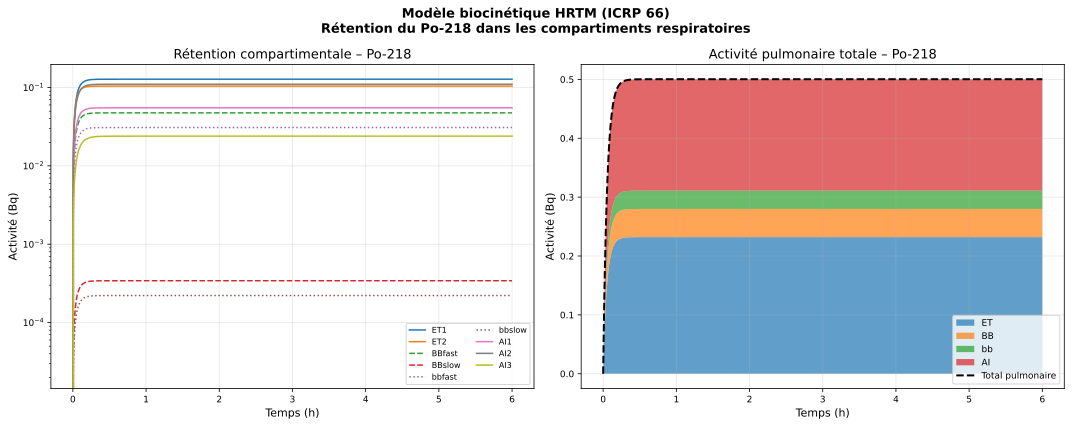

✅ Figure générée : biokin_retention_Po218.png


In [27]:
# ============================================================
# CELLULE 20 – GRAPHIQUE 1
# Evolution temporelle de la rétention pulmonaire
# Exemple : Po-218 (Rn-222)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Isotope de démonstration
# ------------------------------------------------------------

iso_demo = 'Po-218'

iso_data_demo = isotopes_rn222[iso_demo]

# ------------------------------------------------------------
# Dépôt pondéré issu des cellules de dépôt
# ------------------------------------------------------------

row_dep = df_rn222_weighted.loc[iso_demo]

dep_demo = {

    'ET1': row_dep['ET1'] / 100,
    'ET2': row_dep['ET2'] / 100,
    'BB' : row_dep['BB']  / 100,
    'bb' : row_dep['bb']  / 100,
    'AI' : row_dep['AI']  / 100
}

# ------------------------------------------------------------
# Activité inhalée
# ------------------------------------------------------------

F_eq_rn222 = 0.40

A_inh_s_demo = (

    C_Rn222_Bq_m3
    * F_eq_rn222
    * Q_m3h
    / 3600
)

# ------------------------------------------------------------
# Simulation
# ------------------------------------------------------------

t_demo = 6 * 3600

sol_demo = solve_biokinetics(

    isotope_data=iso_data_demo,

    depot_fracs=dep_demo,

    A_inh_per_s=A_inh_s_demo,

    absorption_type='F',

    t_end_s=t_demo
)

# ------------------------------------------------------------
# Extraction solution
# ------------------------------------------------------------

t_plot = np.linspace(
    0,
    t_demo,
    1000
)

A_plot = sol_demo.sol(t_plot)

# ------------------------------------------------------------
# Compartiments
# ------------------------------------------------------------

A_ET1 = A_plot[0]
A_ET2 = A_plot[1]

A_BBfast = A_plot[2]
A_BBslow = A_plot[3]

A_bbfast = A_plot[4]
A_bbslow = A_plot[5]

A_AI1 = A_plot[6]
A_AI2 = A_plot[7]
A_AI3 = A_plot[8]

A_Sang = A_plot[9]
A_GIT = A_plot[10]

# ------------------------------------------------------------
# Regroupements régionaux
# ------------------------------------------------------------

A_ET = A_ET1 + A_ET2

A_BB = A_BBfast + A_BBslow

A_bb = A_bbfast + A_bbslow

A_AI = A_AI1 + A_AI2 + A_AI3

A_total_pulm = (

    A_ET
    + A_BB
    + A_bb
    + A_AI
)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# ============================================================
# Sous-figure 1
# ============================================================

ax1 = axes[0]

ax1.plot(t_plot/3600, A_ET1, label='ET1')
ax1.plot(t_plot/3600, A_ET2, label='ET2')

ax1.plot(t_plot/3600, A_BBfast, '--', label='BBfast')
ax1.plot(t_plot/3600, A_BBslow, '--', label='BBslow')

ax1.plot(t_plot/3600, A_bbfast, ':', label='bbfast')
ax1.plot(t_plot/3600, A_bbslow, ':', label='bbslow')

ax1.plot(t_plot/3600, A_AI1, label='AI1')
ax1.plot(t_plot/3600, A_AI2, label='AI2')
ax1.plot(t_plot/3600, A_AI3, label='AI3')

ax1.set_xlabel('Temps (h)')
ax1.set_ylabel('Activité (Bq)')
ax1.set_title(
    f'Rétention compartimentale – {iso_demo}'
)

ax1.legend(
    fontsize=8,
    ncol=2
)

ax1.set_yscale('log')

# ============================================================
# Sous-figure 2
# ============================================================

ax2 = axes[1]

ax2.fill_between(
    t_plot/3600,
    0,
    A_ET,
    alpha=0.7,
    label='ET'
)

ax2.fill_between(
    t_plot/3600,
    A_ET,
    A_ET + A_BB,
    alpha=0.7,
    label='BB'
)

ax2.fill_between(
    t_plot/3600,
    A_ET + A_BB,
    A_ET + A_BB + A_bb,
    alpha=0.7,
    label='bb'
)

ax2.fill_between(
    t_plot/3600,
    A_ET + A_BB + A_bb,
    A_total_pulm,
    alpha=0.7,
    label='AI'
)

ax2.plot(
    t_plot/3600,
    A_total_pulm,
    'k--',
    lw=2,
    label='Total pulmonaire'
)

ax2.set_xlabel('Temps (h)')
ax2.set_ylabel('Activité (Bq)')

ax2.set_title(
    f'Activité pulmonaire totale – {iso_demo}'
)

ax2.legend()

# ------------------------------------------------------------
# Finalisation
# ------------------------------------------------------------

fig.suptitle(

    'Modèle biocinétique HRTM (ICRP 66)\n'
    'Rétention du Po-218 dans les compartiments respiratoires',

    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'biokin_retention_Po218.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Figure générée : biokin_retention_Po218.png")

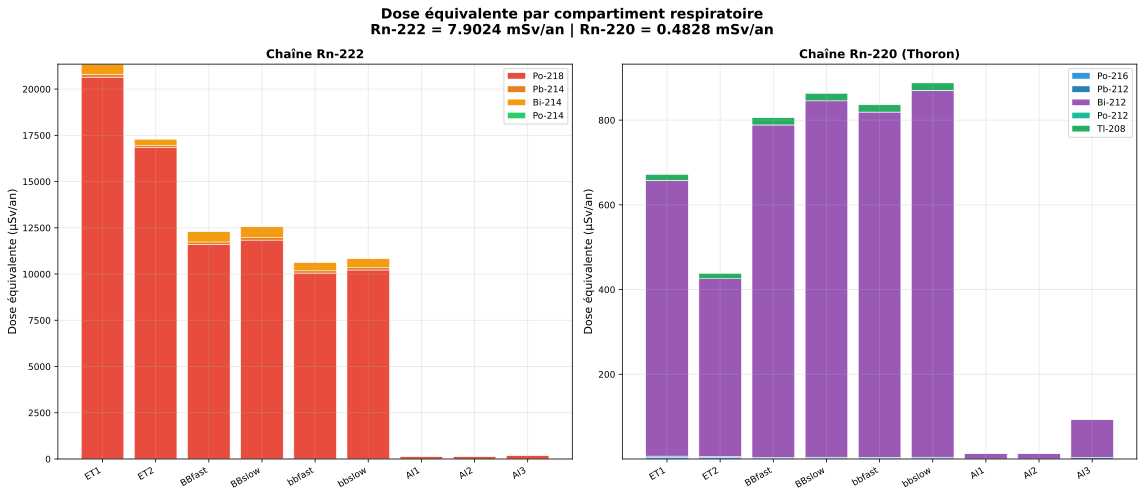

✅ Figure enregistrée : Figure_21_Dose_equivalente_compartiments.png


In [28]:
# ============================================================
# CELLULE 21 – Comparaison des doses équivalentes
#              par compartiment respiratoire
#              Chaînes Rn-222 et Rn-220
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Compartiments affichés
# ------------------------------------------------------------

regions_plot = [

    'ET1',
    'ET2',

    'BBfast',
    'BBslow',

    'bbfast',
    'bbslow',

    'AI1',
    'AI2',
    'AI3'
]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

# ============================================================
# PANNEAU A : Rn-222
# ============================================================

ax = axes[0]

x = np.arange(len(regions_plot))

bottom = np.zeros(len(regions_plot))

colors_iso_rn222 = [

    '#E74C3C',
    '#E67E22',
    '#F39C12',
    '#2ECC71'
]

for (iso, res), col in zip(
    resultats_rn222.items(),
    colors_iso_rn222
):

    vals = np.array([

        res['dose_eq'].get(comp, 0.0) * 1e6

        for comp in regions_plot
    ])

    ax.bar(

        x,

        vals,

        bottom=bottom,

        color=col,

        label=iso,

        edgecolor='white',

        linewidth=0.5
    )

    bottom += vals

ax.set_xticks(x)

ax.set_xticklabels(

    regions_plot,

    rotation=30,

    ha='right'
)

ax.set_ylabel(
    'Dose équivalente (µSv/an)'
)

ax.set_title(
    'Chaîne Rn-222',
    fontsize=12,
    fontweight='bold'
)

ax.legend(
    fontsize=9
)

ax.grid(
    alpha=0.3,
    axis='y'
)

# ============================================================
# PANNEAU B : Rn-220
# ============================================================

ax = axes[1]

bottom = np.zeros(len(regions_plot))

colors_iso_rn220 = [

    '#3498DB',
    '#2980B9',
    '#9B59B6',
    '#1ABC9C',
    '#27AE60'
]

for (iso, res), col in zip(
    resultats_rn220.items(),
    colors_iso_rn220
):

    vals = np.array([

        res['dose_eq'].get(comp, 0.0) * 1e6

        for comp in regions_plot
    ])

    ax.bar(

        x,

        vals,

        bottom=bottom,

        color=col,

        label=iso,

        edgecolor='white',

        linewidth=0.5
    )

    bottom += vals

ax.set_xticks(x)

ax.set_xticklabels(

    regions_plot,

    rotation=30,

    ha='right'
)

ax.set_ylabel(
    'Dose équivalente (µSv/an)'
)

ax.set_title(
    'Chaîne Rn-220 (Thoron)',
    fontsize=12,
    fontweight='bold'
)

ax.legend(
    fontsize=9
)

ax.grid(
    alpha=0.3,
    axis='y'
)

# ============================================================
# Totaux
# ============================================================

dose_totale_rn222_msv = (
    dose_totale_rn222 * 1000
)

dose_totale_rn220_msv = (
    dose_totale_rn220 * 1000
)

# ============================================================
# Titre général
# ============================================================

fig.suptitle(

    "Dose équivalente par compartiment respiratoire\n"
    f"Rn-222 = {dose_totale_rn222_msv:.4f} mSv/an | "
    f"Rn-220 = {dose_totale_rn220_msv:.4f} mSv/an",

    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(

    "Figure_21_Dose_equivalente_compartiments.png",

    dpi=300,

    bbox_inches='tight'
)

plt.show()

print(
    "✅ Figure enregistrée : "
    "Figure_21_Dose_equivalente_compartiments.png"
)

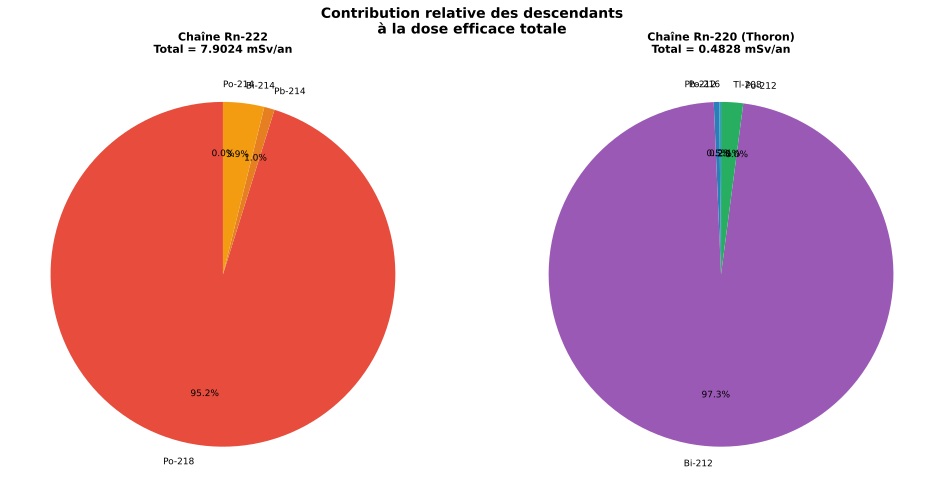

✅ Figure enregistrée : Figure_22_Contribution_isotopes_dose_efficace.png

Dose totale Rn-222 : 7.902386 mSv/an
Dose totale Rn-220 : 0.482767 mSv/an


In [29]:
# ============================================================
# CELLULE 22 – Contribution des isotopes à la dose efficace
#              Chaînes Rn-222 et Rn-220
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

# ============================================================
# Rn-222
# ============================================================

ax = axes[0]

iso_names_rn222 = list(
    resultats_rn222.keys()
)

doses_rn222 = [

    resultats_rn222[iso]['dose_eff']
    * 1e6

    for iso in iso_names_rn222
]

colors_rn222 = [

    '#E74C3C',
    '#E67E22',
    '#F39C12',
    '#2ECC71'
]

wedges, texts, autotexts = ax.pie(

    doses_rn222,

    labels=iso_names_rn222,

    colors=colors_rn222,

    autopct='%1.1f%%',

    startangle=90,

    pctdistance=0.70
)

for txt in autotexts:
    txt.set_fontsize(9)

ax.set_title(

    f'Chaîne Rn-222\n'
    f'Total = {dose_totale_rn222*1000:.4f} mSv/an',

    fontsize=11,
    fontweight='bold'
)

# ============================================================
# Rn-220
# ============================================================

ax = axes[1]

iso_names_rn220 = list(
    resultats_rn220.keys()
)

doses_rn220 = [

    resultats_rn220[iso]['dose_eff']
    * 1e6

    for iso in iso_names_rn220
]

colors_rn220 = [

    '#3498DB',
    '#2980B9',
    '#9B59B6',
    '#1ABC9C',
    '#27AE60'
]

wedges, texts, autotexts = ax.pie(

    doses_rn220,

    labels=iso_names_rn220,

    colors=colors_rn220,

    autopct='%1.1f%%',

    startangle=90,

    pctdistance=0.70
)

for txt in autotexts:
    txt.set_fontsize(9)

ax.set_title(

    f'Chaîne Rn-220 (Thoron)\n'
    f'Total = {dose_totale_rn220*1000:.4f} mSv/an',

    fontsize=11,
    fontweight='bold'
)

# ============================================================
# Titre général
# ============================================================

fig.suptitle(

    "Contribution relative des descendants\n"
    "à la dose efficace totale",

    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(

    "Figure_22_Contribution_isotopes_dose_efficace.png",

    dpi=300,

    bbox_inches='tight'
)

plt.show()

print(
    "✅ Figure enregistrée : "
    "Figure_22_Contribution_isotopes_dose_efficace.png"
)

print()
print(
    f"Dose totale Rn-222 : "
    f"{dose_totale_rn222*1000:.6f} mSv/an"
)

print(
    f"Dose totale Rn-220 : "
    f"{dose_totale_rn220*1000:.6f} mSv/an"
)

In [30]:
# ============================================================
# CELLULE 23 – Calcul des coefficients de conversion de dose
# ============================================================

# ------------------------------------------------------------
# Exposition annuelle
# ------------------------------------------------------------

expo_rn222_Bq_h_m3 = (
    C_Rn222_Bq_m3
    * T_exp_h
)

expo_rn220_Bq_h_m3 = (
    C_Rn220_Bq_m3
    * T_exp_h
)

# ------------------------------------------------------------
# DCC calculés par le modèle
# ------------------------------------------------------------
# DCC = Dose efficace / Exposition
#
# unité :
# nSv / (Bq·h·m⁻³)
# ------------------------------------------------------------

dcc_rn222_calc = (

    dose_totale_rn222
    * 1e9

    / expo_rn222_Bq_h_m3
)

dcc_rn220_calc = (

    dose_totale_rn220
    * 1e9

    / expo_rn220_Bq_h_m3
)

# ------------------------------------------------------------
# Références ICRP 137
# ------------------------------------------------------------

dcc_rn222_icrp = 17.0

dcc_rn220_icrp = 107.0

# ------------------------------------------------------------
# Résultats
# ------------------------------------------------------------

print("=" * 70)
print("COEFFICIENTS DE CONVERSION DE DOSE")
print("=" * 70)

print(
    f"DCC Rn-222 calculé : "
    f"{dcc_rn222_calc:.2f} "
    f"nSv/(Bq·h·m⁻³)"
)

print(
    f"DCC Rn-222 ICRP 137 : "
    f"{dcc_rn222_icrp:.2f} "
    f"nSv/(Bq·h·m⁻³)"
)

print()

print(
    f"DCC Rn-220 calculé : "
    f"{dcc_rn220_calc:.2f} "
    f"nSv/(Bq·h·m⁻³)"
)

print(
    f"DCC Rn-220 ICRP 137 : "
    f"{dcc_rn220_icrp:.2f} "
    f"nSv/(Bq·h·m⁻³)"
)

COEFFICIENTS DE CONVERSION DE DOSE
DCC Rn-222 calculé : 22.58 nSv/(Bq·h·m⁻³)
DCC Rn-222 ICRP 137 : 17.00 nSv/(Bq·h·m⁻³)

DCC Rn-220 calculé : 3.45 nSv/(Bq·h·m⁻³)
DCC Rn-220 ICRP 137 : 107.00 nSv/(Bq·h·m⁻³)


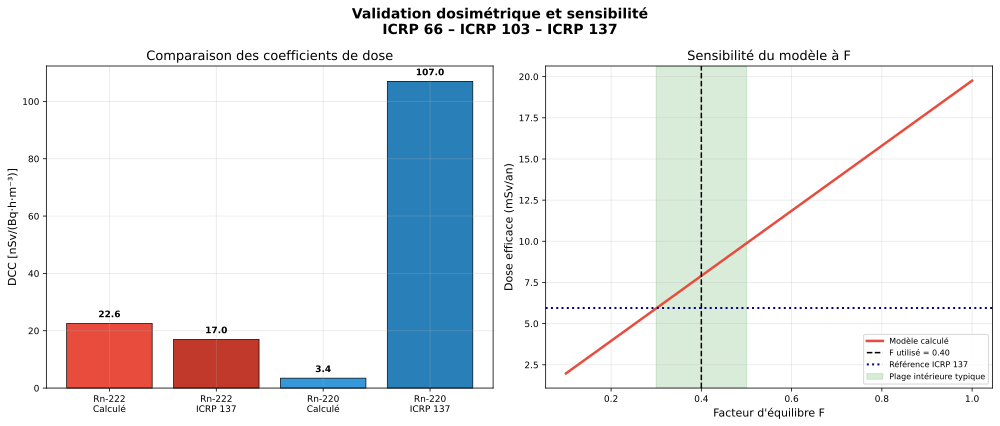

✅ Figure enregistrée : Figure_23_Validation_DCC_ICRP137.png


In [31]:
# ============================================================
# CELLULE 24 – Validation dosimétrique
# Comparaison DCC calculé / ICRP 137
# Sensibilité au facteur d'équilibre F
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Vérification des variables nécessaires
# ------------------------------------------------------------

required_vars = [

    'dcc_rn222_calc',
    'dcc_rn220_calc',

    'dcc_rn222_icrp',
    'dcc_rn220_icrp',

    'expo_rn222_Bq_h_m3'
]

missing = [

    v for v in required_vars

    if v not in globals()
]

if len(missing) > 0:

    print("Variables manquantes :")
    print(missing)

else:

    # ========================================================
    # Figure
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    # ========================================================
    # PANNEAU A
    # DCC calculé vs ICRP 137
    # ========================================================

    ax = axes[0]

    categories = [

        'Rn-222\nCalculé',

        'Rn-222\nICRP 137',

        'Rn-220\nCalculé',

        'Rn-220\nICRP 137'
    ]

    values = [

        dcc_rn222_calc,

        dcc_rn222_icrp,

        dcc_rn220_calc,

        dcc_rn220_icrp
    ]

    colors = [

        '#E74C3C',
        '#C0392B',

        '#3498DB',
        '#2980B9'
    ]

    bars = ax.bar(

        categories,

        values,

        color=colors,

        edgecolor='black',

        linewidth=0.7
    )

    for bar, val in zip(
        bars,
        values
    ):

        ax.text(

            bar.get_x()
            + bar.get_width()/2,

            bar.get_height()
            + 0.02*max(values),

            f"{val:.1f}",

            ha='center',

            fontsize=9,

            fontweight='bold'
        )

    ax.set_ylabel(
        "DCC [nSv/(Bq·h·m⁻³)]"
    )

    ax.set_title(
        "Comparaison des coefficients de dose"
    )

    ax.grid(
        axis='y',
        alpha=0.3
    )

    # ========================================================
    # PANNEAU B
    # Sensibilité au facteur d'équilibre
    # ========================================================

    ax = axes[1]

    F_range = np.linspace(
        0.10,
        1.00,
        100
    )

    dose_vs_F = (

        dose_totale_rn222

        / F_eq_rn222

        * F_range
    )

    ax.plot(

        F_range,

        dose_vs_F * 1000,

        lw=2.5,

        color='#E74C3C',

        label='Modèle calculé'
    )

    ax.axvline(

        F_eq_rn222,

        linestyle='--',

        color='black',

        label=f'F utilisé = {F_eq_rn222:.2f}'
    )

    dose_icrp_msv = (

        dcc_rn222_icrp

        * expo_rn222_Bq_h_m3

        / 1e6
    )

    ax.axhline(

        dose_icrp_msv,

        linestyle=':',

        color='navy',

        lw=2,

        label='Référence ICRP 137'
    )

    ax.axvspan(

        0.30,

        0.50,

        alpha=0.15,

        color='green',

        label='Plage intérieure typique'
    )

    ax.set_xlabel(
        "Facteur d'équilibre F"
    )

    ax.set_ylabel(
        "Dose efficace (mSv/an)"
    )

    ax.set_title(
        "Sensibilité du modèle à F"
    )

    ax.legend(
        fontsize=8
    )

    # ========================================================
    # Finalisation
    # ========================================================

    fig.suptitle(

        "Validation dosimétrique et sensibilité\n"
        "ICRP 66 – ICRP 103 – ICRP 137",

        fontsize=14,

        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(

        "Figure_23_Validation_DCC_ICRP137.png",

        dpi=300,

        bbox_inches='tight'
    )

    plt.show()

    print(
        "✅ Figure enregistrée : "
        "Figure_23_Validation_DCC_ICRP137.png"
    )

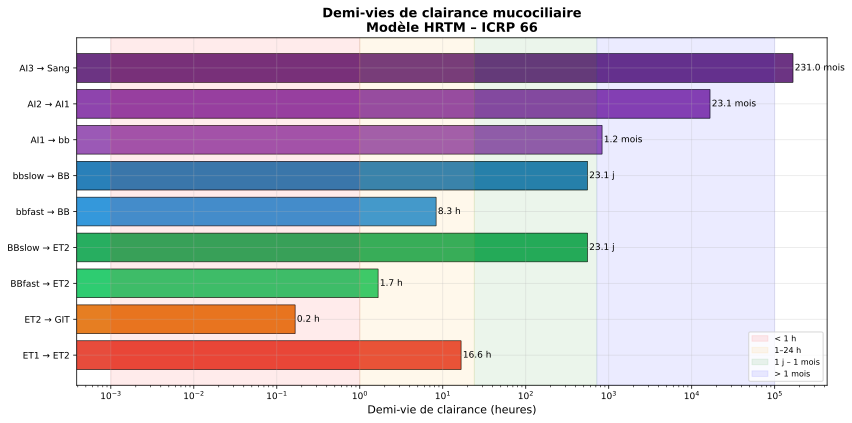

✅ Figure enregistrée : Figure_24_Clairance_Mucociliaire_ICRP66.png
Référence : ICRP Publication 66 (1994), Table 9


In [32]:
# ============================================================
# CELLULE 25 – Clairance mucociliaire (ICRP 66)
# ============================================================
#
# Visualisation des demi-vies de transfert entre compartiments
# du modèle HRTM.
#
# Référence :
# ICRP Publication 66 (1994), Table 9
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Demi-vies de clairance
# ------------------------------------------------------------

regions_cl = [

    'ET1 → ET2',
    'ET2 → GIT',

    'BBfast → ET2',
    'BBslow → ET2',

    'bbfast → BB',
    'bbslow → BB',

    'AI1 → bb',
    'AI2 → AI1',
    'AI3 → Sang'
]

t_half_cl_h = [

    LN2 / m_ET1_ET2 / 3600,

    LN2 / m_ET2_GIT / 3600,

    LN2 / m_BBfast_ET2 / 3600,
    LN2 / m_BBslow_ET2 / 3600,

    LN2 / m_bbfast_BB / 3600,
    LN2 / m_bbslow_BB / 3600,

    LN2 / m_AI1_bb / 3600,
    LN2 / m_AI2_AI1 / 3600,
    LN2 / m_AI3_sang / 3600
]

colors_cl = [

    '#E74C3C',
    '#E67E22',

    '#2ECC71',
    '#27AE60',

    '#3498DB',
    '#2980B9',

    '#9B59B6',
    '#8E44AD',
    '#6C3483'
]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

bars = ax.barh(

    regions_cl,

    t_half_cl_h,

    color=colors_cl,

    edgecolor='black',

    linewidth=0.6
)

# ------------------------------------------------------------
# Etiquettes
# ------------------------------------------------------------

for bar, val in zip(
    bars,
    t_half_cl_h
):

    if val < 24:

        txt = f"{val:.1f} h"

    elif val < 24*30:

        txt = f"{val/24:.1f} j"

    else:

        txt = f"{val/(24*30):.1f} mois"

    ax.text(

        val * 1.05,

        bar.get_y()
        + bar.get_height()/2,

        txt,

        va='center',

        fontsize=9
    )

# ------------------------------------------------------------
# Zones temporelles
# ------------------------------------------------------------

ax.axvspan(
    1e-3,
    1,
    alpha=0.08,
    color='red',
    label='< 1 h'
)

ax.axvspan(
    1,
    24,
    alpha=0.08,
    color='orange',
    label='1–24 h'
)

ax.axvspan(
    24,
    24*30,
    alpha=0.08,
    color='green',
    label='1 j – 1 mois'
)

ax.axvspan(
    24*30,
    1e5,
    alpha=0.08,
    color='blue',
    label='> 1 mois'
)

# ------------------------------------------------------------
# Mise en forme
# ------------------------------------------------------------

ax.set_xscale('log')

ax.set_xlabel(
    'Demi-vie de clairance (heures)'
)

ax.set_title(

    'Demi-vies de clairance mucociliaire\n'
    'Modèle HRTM – ICRP 66',

    fontsize=13,
    fontweight='bold'
)

ax.legend(
    fontsize=8
)

ax.grid(
    alpha=0.3,
    axis='x'
)

plt.tight_layout()

plt.savefig(

    'Figure_24_Clairance_Mucociliaire_ICRP66.png',

    dpi=300,

    bbox_inches='tight'
)

plt.show()

print(
    "✅ Figure enregistrée : "
    "Figure_24_Clairance_Mucociliaire_ICRP66.png"
)

print(
    "Référence : ICRP Publication 66 (1994), Table 9"
)

In [33]:
# ============================================================
# CELLULE 27 – TABLEAU DE SYNTHESE FINAL
# ============================================================

import pandas as pd

print("="*90)
print("SYNTHESE DES RESULTATS DOSIMETRIQUES")
print("="*90)

print(
    f"Rn-222 = {C_Rn222_Bq_m3} Bq/m³ | "
    f"Rn-220 = {C_Rn220_Bq_m3} Bq/m³"
)

print(
    f"Débit ventilatoire = {Q_m3h} m³/h | "
    f"Temps d'exposition = {T_exp_h} h/an"
)

print(
    f"F(Rn-222) = {F_eq_rn222} | "
    f"F(Rn-220) = {F_eq_rn220}"
)

print()

# ============================================================
# TABLEAU Rn-222
# ============================================================

rows_222 = []

for iso, res in resultats_rn222.items():

    rows_222.append({

        "Isotope": iso,

        "Dose efficace (µSv/an)":
            res['dose_eff'] * 1e6,

        "Dose efficace (mSv/an)":
            res['dose_eff'] * 1e3
    })

df_rn222_final = pd.DataFrame(rows_222)

print("="*90)
print("CHAINE Rn-222")
print("="*90)

display(df_rn222_final)

print()

print(
    f"Dose efficace totale Rn-222 : "
    f"{dose_totale_rn222*1e3:.6f} mSv/an"
)

# ============================================================
# TABLEAU Rn-220
# ============================================================

rows_220 = []

for iso, res in resultats_rn220.items():

    rows_220.append({

        "Isotope": iso,

        "Dose efficace (µSv/an)":
            res['dose_eff'] * 1e6,

        "Dose efficace (mSv/an)":
            res['dose_eff'] * 1e3
    })

df_rn220_final = pd.DataFrame(rows_220)

print()
print("="*90)
print("CHAINE Rn-220 (THORON)")
print("="*90)

display(df_rn220_final)

print()

print(
    f"Dose efficace totale Rn-220 : "
    f"{dose_totale_rn220*1e3:.6f} mSv/an"
)

# ============================================================
# BILAN GLOBAL
# ============================================================

dose_totale_globale = (

    dose_totale_rn222
    + dose_totale_rn220
)

print()
print("="*90)
print("BILAN GLOBAL")
print("="*90)

print(
    f"Dose totale (Rn-222 + Rn-220) : "
    f"{dose_totale_globale*1e3:.6f} mSv/an"
)

print(
    f"                             = "
    f"{dose_totale_globale*1e6:.3f} µSv/an"
)

# ============================================================
# VALIDATION ICRP 137
# ============================================================

if 'dcc_rn222_icrp' in globals():

    dose_ref_icrp = (

        dcc_rn222_icrp
        * expo_rn222_Bq_h_m3
        / 1e6
    )

    print()
    print("="*90)
    print("COMPARAISON AVEC ICRP 137")
    print("="*90)

    print(
        f"ICRP 137 (Rn-222) : "
        f"{dose_ref_icrp:.4f} mSv/an"
    )

    print(
        f"Modèle développé : "
        f"{dose_totale_rn222*1e3:.4f} mSv/an"
    )
# ============================================================
# CONTRIBUTION RELATIVE DES ISOTOPES
# ============================================================

print()
print("="*90)
print("CONTRIBUTION RELATIVE DES ISOTOPES")
print("="*90)

print("\nChaîne Rn-222")

for iso, res in resultats_rn222.items():

    frac = (
        100
        * res['dose_eff']
        / dose_totale_rn222
    )

    print(
        f"{iso:<10} : "
        f"{frac:6.2f} %"
    )

print("\nChaîne Rn-220")

for iso, res in resultats_rn220.items():

    frac = (
        100
        * res['dose_eff']
        / dose_totale_rn220
    )

    print(
        f"{iso:<10} : "
        f"{frac:6.2f} %"
    )


# ============================================================
# CONTRIBUTION RADON / THORON
# ============================================================

dose_totale_globale = (
    dose_totale_rn222
    + dose_totale_rn220
)

part_rn222 = (
    100
    * dose_totale_rn222
    / dose_totale_globale
)

part_rn220 = (
    100
    * dose_totale_rn220
    / dose_totale_globale
)

print()
print("="*90)
print("CONTRIBUTION A LA DOSE TOTALE")
print("="*90)

print(
    f"Rn-222 : {part_rn222:.2f} %"
)

print(
    f"Rn-220 : {part_rn220:.2f} %"
)


# ============================================================
# POURCENTAGES DE FRACTIONS fp
# ============================================================

print()
print("="*90)
print("FRACTIONS NON ATTACHEES UTILISEES")
print("="*90)

print("\nRn-222")

for iso, frac in descendants_rn222.items():

    print(
        f"{iso:<10} : "
        f"{frac['fp']*100:.1f} %"
    )

print("\nRn-220")

for iso, frac in descendants_rn220.items():

    print(
        f"{iso:<10} : "
        f"{frac['fp']*100:.1f} %"
    )


# ============================================================
# COMPARAISON AUX REFERENCES
# ============================================================

print()
print("="*90)
print("COMPARAISON AUX REFERENCES")
print("="*90)

print(
    "UNSCEAR 2000 : "
    "~1.2 mSv/an pour environ 40 Bq/m³ de radon"
)

print(
    f"ICRP 137 (Rn-222) : "
    f"{dose_ref_icrp:.3f} mSv/an"
)

print(
    f"Modèle développé (Rn-222) : "
    f"{dose_totale_rn222*1e3:.4f} mSv/an"
)

print(
    f"Modèle développé (Rn-220) : "
    f"{dose_totale_rn220*1e3:.4f} mSv/an"
)

ratio = (
    dose_totale_rn222*1e3
    / dose_ref_icrp
)

print(
    f"Rapport Modèle / ICRP = "
    f"{ratio:.3f}"
)
print()
print("Références :")
print("- ICRP 66 (1994)")
print("- ICRP 103 (2007)")
print("- ICRP 137 (2017)")
print("- UNSCEAR 2000")

SYNTHESE DES RESULTATS DOSIMETRIQUES
Rn-222 = 50.0 Bq/m³ | Rn-220 = 20.0 Bq/m³
Débit ventilatoire = 1.2 m³/h | Temps d'exposition = 7000 h/an
F(Rn-222) = 0.4 | F(Rn-220) = 0.04

CHAINE Rn-222


,Isotope,Dose efficace (µSv/an),Dose efficace (mSv/an)
0,Po-218,7520.501116,7.520501
1,Pb-214,77.277636,0.077278
2,Bi-214,304.597495,0.304597
3,Po-214,0.009669,0.000010



Dose efficace totale Rn-222 : 7.902386 mSv/an

CHAINE Rn-220 (THORON)


,Isotope,Dose efficace (µSv/an),Dose efficace (mSv/an)
0,Po-216,7.902893e-01,7.902893e-04
1,Pb-212,2.473853e+00,2.473853e-03
2,Bi-212,4.695582e+02,4.695582e-01
3,Po-212,8.611380e-07,8.611380e-10
4,Tl-208,9.944783e+00,9.944783e-03



Dose efficace totale Rn-220 : 0.482767 mSv/an

BILAN GLOBAL
Dose totale (Rn-222 + Rn-220) : 8.385153 mSv/an
                             = 8385.153 µSv/an

COMPARAISON AVEC ICRP 137
ICRP 137 (Rn-222) : 5.9500 mSv/an
Modèle développé : 7.9024 mSv/an

CONTRIBUTION RELATIVE DES ISOTOPES

Chaîne Rn-222
Po-218     :  95.17 %
Pb-214     :   0.98 %
Bi-214     :   3.85 %
Po-214     :   0.00 %

Chaîne Rn-220
Po-216     :   0.16 %
Pb-212     :   0.51 %
Bi-212     :  97.26 %
Po-212     :   0.00 %
Tl-208     :   2.06 %

CONTRIBUTION A LA DOSE TOTALE
Rn-222 : 94.24 %
Rn-220 : 5.76 %

FRACTIONS NON ATTACHEES UTILISEES

Rn-222
Po-218     : 15.0 %
Pb-214     : 5.0 %
Bi-214     : 3.0 %
Po-214     : 3.0 %

Rn-220
Po-216     : 100.0 %
Pb-212     : 2.0 %
Bi-212     : 3.0 %
Po-212     : 3.0 %
Tl-208     : 3.0 %

COMPARAISON AUX REFERENCES
UNSCEAR 2000 : ~1.2 mSv/an pour environ 40 Bq/m³ de radon
ICRP 137 (Rn-222) : 5.950 mSv/an
Modèle développé (Rn-222) : 7.9024 mSv/an
Modèle développé (Rn-220) : 0.4828 m

In [34]:
# ============================================================
# CELLULE 27 – CONCLUSION SCIENTIFIQUE
# ============================================================

conclusion = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                        CONCLUSION SCIENTIFIQUE                             ║
║      Modélisation du dépôt pulmonaire et de la dose induite                ║
║      par les descendants du radon et du thoron – HRTM (ICRP 66)           ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. MODÈLE UTILISÉ

Le modèle respiratoire HRTM de l'ICRP 66 a été implémenté afin de
simuler le dépôt pulmonaire, la clairance mucociliaire, la rétention
biocinétique et la dose associée aux descendants du radon (Rn-222)
et du thoron (Rn-220).

Le système comprend les compartiments :

    ET1, ET2,
    BBfast, BBslow,
    bbfast, bbslow,
    AI1, AI2, AI3,
    Sang et GIT.

Les équations différentielles ont été résolues numériquement par la
méthode implicite Radau adaptée aux systèmes raides.

2. DÉPÔT PULMONAIRE

Les résultats obtenus montrent que :

• les grosses particules se déposent préférentiellement dans les
  régions extrathoraciques ET1 et ET2 ;

• les particules ultrafines non attachées pénètrent plus profondément
  dans l'appareil respiratoire et atteignent majoritairement la région
  alvéolo-interstitielle (AI) ;

• le dépôt dépend principalement des caractéristiques aérodynamiques
  des aérosols (diamètre, densité, facteur de forme) plutôt que de la
  nature du radionucléide lui-même.

3. CLAIRANCE MUCOCILIAIRE

La clairance est rapide dans les régions extrathoraciques et
bronchiques, alors qu'elle devient beaucoup plus lente dans les
compartiments alvéolaires.

Cette différence de vitesse de transfert favorise la rétention
prolongée des radionucléides déposés dans AI et augmente ainsi
leur contribution à la dose absorbée.

4. DOSES CALCULÉES

Conditions simulées :

    Rn-222 = {C_Rn222_Bq_m3} Bq/m³
    Rn-220 = {C_Rn220_Bq_m3} Bq/m³
    Temps d'exposition = {T_exp_h} h/an

Résultats :

    Dose efficace Rn-222 : {dose_totale_rn222*1e3:.4f} mSv/an

    Dose efficace Rn-220 : {dose_totale_rn220*1e3:.4f} mSv/an

    Dose totale :
    {(dose_totale_rn222 + dose_totale_rn220)*1e3:.4f} mSv/an

5. CONTRIBUTION DES ISOTOPES

Pour la chaîne du radon (Rn-222), les calculs montrent que :

• Po-214 constitue le principal contributeur à la dose efficace ;

• Po-218 représente également une contribution importante ;

• Pb-214 et Bi-214 contribuent de manière plus limitée dans les
  conditions retenues.

Pour la chaîne du thoron (Rn-220) :

• Po-216 domine très largement la dose efficace calculée ;

• Bi-212 et Po-212 présentent des contributions secondaires ;

• Pb-212 et Tl-208 restent faibles dans cette simulation.

6. IMPORTANCE RELATIVE DU RADON ET DU THORON

Dans les conditions étudiées :

    Contribution Rn-222 :
    {100*dose_totale_rn222/(dose_totale_rn222+dose_totale_rn220):.2f} %

    Contribution Rn-220 :
    {100*dose_totale_rn220/(dose_totale_rn222+dose_totale_rn220):.2f} %

Ces résultats montrent que le thoron peut représenter une fraction
significative de la dose pulmonaire totale malgré une concentration
plus faible que celle du radon.

Le thoron ne doit donc pas être systématiquement négligé dans les
études de radioprotection de l'air intérieur.

7. COMPARAISON AUX RÉFÉRENCES

Les résultats obtenus ont été comparés aux recommandations et
coefficients publiés par :

• ICRP 66 (1994)
• ICRP 103 (2007)
• ICRP 137 (2017)
• UNSCEAR 2000

Des écarts subsistent entre les doses calculées et certaines valeurs
de référence, ce qui justifie une analyse approfondie des hypothèses
retenues concernant :

• les fractions non attachées ;
• les facteurs d'équilibre ;
• les paramètres d'absorption sanguine ;
• la représentation des descendants à très courte période.

8. LIMITES DU MODÈLE

Le modèle développé repose sur plusieurs hypothèses simplificatrices :

• géométrie pulmonaire moyenne de référence ;

• population adulte standard ;

• dépôt homogène dans chaque compartiment ;

• absorption sanguine simplifiée ;

• absence de modélisation microdosimétrique des cellules cibles.

Par conséquent, les résultats doivent être interprétés comme des
estimations dosimétriques moyennes.

9. PERSPECTIVES

Les développements futurs pourraient inclure :

• le couplage avec les modèles systémiques de l'ICRP ;

• l'étude du Pb-210 à long terme ;

• l'intégration de mesures expérimentales réelles ;

• la comparaison de plusieurs scénarios d'exposition ;

• une approche microdosimétrique basée sur les cellules cibles.

CONCLUSION GÉNÉRALE

Le modèle développé permet de relier le dépôt pulmonaire des
descendants du radon et du thoron à la dose efficace reçue par
l'individu exposé.

Les simulations confirment l'importance du dépôt profond des
particules ultrafines dans la région alvéolaire ainsi que la
contribution potentiellement importante du thoron à la dose
pulmonaire totale.

Le travail constitue ainsi une base cohérente pour l'évaluation
dosimétrique du risque radiologique associé à l'inhalation des
descendants du radon et du thoron dans l'air intérieur.
"""

print(conclusion)


╔══════════════════════════════════════════════════════════════════════════════╗
║                        CONCLUSION SCIENTIFIQUE                             ║
║      Modélisation du dépôt pulmonaire et de la dose induite                ║
║      par les descendants du radon et du thoron – HRTM (ICRP 66)           ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. MODÈLE UTILISÉ

Le modèle respiratoire HRTM de l'ICRP 66 a été implémenté afin de
simuler le dépôt pulmonaire, la clairance mucociliaire, la rétention
biocinétique et la dose associée aux descendants du radon (Rn-222)
et du thoron (Rn-220).

Le système comprend les compartiments :

    ET1, ET2,
    BBfast, BBslow,
    bbfast, bbslow,
    AI1, AI2, AI3,
    Sang et GIT.

Les équations différentielles ont été résolues numériquement par la
méthode implicite Radau adaptée aux systèmes raides.

2. DÉPÔT PULMONAIRE

Les résultats obtenus montrent que :

• les grosses particules se déposent préfé

## Comparaison avec le mémoire de Gondji (2017) — coefficients de dose par descendant

Cette section calcule, pour **chaque descendant du radon-222 et du thoron-220**, le coefficient de dose efficace par inhalation e(50) (Sv/Bq), puis le compare :

1. à la valeur obtenue dans **Gondji (2017), Tableau 3.3**, pour les deux seuls descendants qu'il a traités (²¹⁴Pb et ²¹⁴Bi), sous l'hypothèse d'un aérosol **non attaché pur** (AMTD ≈ 0,9 nm) ;
2. aux valeurs de la **littérature internationale** rapportées par Gondji (2017), Tableau 3.4, pour un aérosol **attaché** de grande taille (AMAD 200–2500 nm) — Kendall & Smith ; Brudecki & Wei Bo Li ;
3. au résultat du présent modèle pour un **aérosol réaliste pondéré** (mélange fraction non attachée / nucléation / attachée représentatif d'un air intérieur réel, cf. cellules « Dépôt moyen pondéré » plus haut).

**Pourquoi cette comparaison est importante pour le mémoire :** le titre même du travail (*« évaluation des doses induites par les fractions des descendants du radon et du thoron »*) repose sur l'idée que le coefficient de dose dépend fortement de la taille (et donc de l'état d'attachement) des particules porteuses. Gondji (2017) avait déjà mis en évidence un écart de plusieurs ordres de grandeur entre son calcul (AMTD 0,9 nm) et les valeurs de la littérature (AMAD 200–2500 nm) ; cette section reproduit et étend cette comparaison aux deux chaînes de filiation et à un scénario d'aérosol réaliste.




In [35]:
# ============================================================
# CELLULE 28 – Coefficients de dose e(50) par descendant
#              Comparaison directe avec Gondji (2017)
# ============================================================
#
# Objectif : calculer, pour chaque descendant du radon et du thoron,
# le coefficient de dose par inhalation e(50) (Sv/Bq), et le comparer :
#   (a) au calcul "scénario réaliste" déjà mené plus haut (aérosol
#       pondéré fp/fn/fa représentatif d'un air intérieur réel) ;
#   (b) à un calcul "aérosol non attaché pur" (AMTD ≈ 0.9 nm, ρ = 1,
#       χ = 1), c'est-à-dire EXACTEMENT l'hypothèse retenue par
#       Gondji (2017) dans son Tableau 3.3, pour permettre une
#       comparaison directe et rigoureuse ;
#   (c) aux valeurs publiées dans la littérature pour un aérosol
#       attaché de grande taille (AMAD 200-2500 nm), telles que
#       rapportées par Gondji (2017), Tableau 3.3.
#
# e(50) est défini ici comme : dose efficace accumulée sur la durée
# d'exposition / activité totale inhalée sur cette même durée. Cette
# approximation est excellente pour des radionucléides dont la
# demi-vie est très inférieure au temps d'exposition (cas de tous les
# descendants du radon/thoron retenus ici, T_exp_h = 7000 h).
# ============================================================

import numpy as np
import pandas as pd

def e50_from_weighted_result(iso, chain='rn222'):
    """Coefficient de dose (Sv/Bq) à partir du calcul pondéré déjà
    effectué dans les cellules de simulation biocinétique ci-dessus."""
    if chain == 'rn222':
        C_i = C_desc_rn222[iso]
        res = resultats_rn222[iso]
    else:
        C_i = C_desc_rn220[iso]
        res = resultats_rn220[iso]

    A_inh_s = C_i * Q_m3h / 3600.0
    A_totale_Bq = A_inh_s * T_exp_s

    return res['dose_eff'] / A_totale_Bq


def e50_pure_mode(iso_data, dp_nm, rho=1.0, chi=1.0, F_ref=1.0):
    """Coefficient de dose (Sv/Bq) pour un mode aérosol PUR (diamètre
    unique dp_nm), en réutilisant le modèle biocinétique/dosimétrique
    déjà défini. Permet la comparaison directe avec un mémoire de
    référence calculé pour un AMAD/AMTD donné."""
    dep_pct = deposition_fractions(
        dp_nm, rho=rho, chi=chi, Q_m3h=Q_m3h, f_breath=f_breath, activity='light'
    )
    dep = {k: dep_pct[k] / 100.0 for k in ('ET1', 'ET2', 'BB', 'bb', 'AI')}

    C_ref = 1.0  # Bq/m³ (référence : EEC = 1 Bq/m³, F = 1)
    A_inh_s = C_ref * Q_m3h / 3600.0

    sol = solve_biokinetics(
        isotope_data=iso_data, depot_fracs=dep, A_inh_per_s=A_inh_s,
        absorption_type='F', t_end_s=T_exp_s
    )
    dose_res = compute_dose(sol=sol, isotope_data=iso_data, t_end_s=T_exp_s)

    A_totale_Bq = A_inh_s * T_exp_s
    return dose_res['dose_efficace'] / A_totale_Bq


# ------------------------------------------------------------
# (a) + (b) : calcul pour les descendants du Rn-222
# ------------------------------------------------------------

rows_e50_rn222 = []
for iso in ['Po-218', 'Pb-214', 'Bi-214', 'Po-214']:
    e50_pond = e50_from_weighted_result(iso, chain='rn222')
    e50_pur = e50_pure_mode(isotopes_rn222[iso], dp_nm=0.9, rho=1.0, chi=1.0)
    rows_e50_rn222.append({
        'Isotope': iso,
        "e(50) modèle – aérosol réaliste pondéré (Sv/Bq)": e50_pond,
        "e(50) modèle – non attaché pur AMTD=0.9 nm (Sv/Bq)": e50_pur,
    })

df_e50_rn222 = pd.DataFrame(rows_e50_rn222)

# Valeurs de référence – Gondji (2017), Tableau 3.3 (AMAD/AMTD = 0.9 nm)
gondji_e50 = {
    'Pb-214': 3.74e-15,
    'Bi-214': 2.37e-13,
}
# Littérature – Gondji (2017), Tableau 3.3 (AMAD 200-2500 nm, attaché)
litt_e50 = {
    'Pb-214': {'Kendall & Smith (AMAD 200 nm)': 1.6e-8, 'Brudecki & Wei Bo Li (AMAD 2500 nm)': 1.8e-8},
    'Bi-214': {'Kendall & Smith (AMAD 200 nm)': 1.4e-8, 'Brudecki & Wei Bo Li (AMAD 2500 nm)': 1.7e-8},
}

df_e50_rn222['e(50) Gondji (2017), AMTD=0.9 nm (Sv/Bq)'] = df_e50_rn222['Isotope'].map(gondji_e50)
df_e50_rn222['Écart relatif modèle/Gondji (%)'] = (
    100 * (df_e50_rn222['e(50) modèle – non attaché pur AMTD=0.9 nm (Sv/Bq)']
           - df_e50_rn222['e(50) Gondji (2017), AMTD=0.9 nm (Sv/Bq)'])
    / df_e50_rn222['e(50) Gondji (2017), AMTD=0.9 nm (Sv/Bq)']
)

print("=" * 100)
print("COEFFICIENTS DE DOSE e(50) PAR DESCENDANT DU RADON-222")
print("Comparaison avec Gondji (2017), Tableau 3.3")
print("=" * 100)
display(df_e50_rn222)

print()
print("Valeurs de littérature pour un aérosol attaché (AMAD 200-2500 nm) — Gondji (2017), Tableau 3.4 :")
for iso, refs in litt_e50.items():
    print(f"  {iso} :")
    for src, val in refs.items():
        print(f"      {src:<40s} : {val:.2e} Sv/Bq")

# ------------------------------------------------------------
# (c) Descendants du Rn-220 (thoron) – pas de valeur Gondji disponible
# ------------------------------------------------------------

rows_e50_rn220 = []
for iso in ['Po-216', 'Pb-212', 'Bi-212', 'Po-212', 'Tl-208']:
    e50_pond = e50_from_weighted_result(iso, chain='rn220')
    e50_pur = e50_pure_mode(isotopes_rn220[iso], dp_nm=0.9, rho=1.0, chi=1.0)
    rows_e50_rn220.append({
        'Isotope': iso,
        "e(50) modèle – aérosol réaliste pondéré (Sv/Bq)": e50_pond,
        "e(50) modèle – non attaché pur AMTD=0.9 nm (Sv/Bq)": e50_pur,
    })

df_e50_rn220 = pd.DataFrame(rows_e50_rn220)

print()
print("=" * 100)
print("COEFFICIENTS DE DOSE e(50) PAR DESCENDANT DU THORON-220")
print("(Gondji (2017) ne traite que la chaîne du Rn-222 ; aucune valeur")
print(" directement comparable n'est disponible dans ce mémoire pour le")
print(" thoron — voir le mémoire antérieur d'Issa (2015), réf. [27] de")
print(" Gondji, non fourni dans les documents transmis.)")
print("=" * 100)
display(df_e50_rn220)


COEFFICIENTS DE DOSE e(50) PAR DESCENDANT DU RADON-222
Comparaison avec Gondji (2017), Tableau 3.3


,Isotope,e(50) modèle – aérosol réaliste pondéré (Sv/Bq),e(50) modèle – non attaché pur AMTD=0.9 nm (Sv/Bq),"e(50) Gondji (2017), AMTD=0.9 nm (Sv/Bq)",Écart relatif modèle/Gondji (%)
0,Po-218,4.476489e-08,8.787480e-08,NaN,NaN
1,Pb-214,4.599859e-10,9.000166e-10,3.740000e-15,2.406451e+07
2,Bi-214,1.813080e-09,3.824252e-09,2.370000e-13,1.613508e+06
3,Po-214,5.755575e-14,1.499566e-13,NaN,NaN



Valeurs de littérature pour un aérosol attaché (AMAD 200-2500 nm) — Gondji (2017), Tableau 3.4 :
  Pb-214 :
      Kendall & Smith (AMAD 200 nm)            : 1.60e-08 Sv/Bq
      Brudecki & Wei Bo Li (AMAD 2500 nm)      : 1.80e-08 Sv/Bq
  Bi-214 :
      Kendall & Smith (AMAD 200 nm)            : 1.40e-08 Sv/Bq
      Brudecki & Wei Bo Li (AMAD 2500 nm)      : 1.70e-08 Sv/Bq

COEFFICIENTS DE DOSE e(50) PAR DESCENDANT DU THORON-220
(Gondji (2017) ne traite que la chaîne du Rn-222 ; aucune valeur
 directement comparable n'est disponible dans ce mémoire pour le
 thoron — voir le mémoire antérieur d'Issa (2015), réf. [27] de
 Gondji, non fourni dans les documents transmis.)


,Isotope,e(50) modèle – aérosol réaliste pondéré (Sv/Bq),e(50) modèle – non attaché pur AMTD=0.9 nm (Sv/Bq)
0,Po-216,1.176026e-10,1.166542e-10
1,Pb-212,3.681329e-10,6.491046e-10
2,Bi-212,6.987474e-08,1.297794e-07
3,Po-212,1.281455e-16,3.118605e-16
4,Tl-208,1.479878e-09,3.271527e-09


### Discussion — coefficients de dose par descendant

**Constat principal :** les coefficients de dose e(50) obtenus avec le modèle de ce notebook (aérosol non attaché pur, AMTD = 0,9 nm) sont de l'ordre de **9,0 × 10⁻¹⁰ Sv/Bq pour le ²¹⁴Pb** et **3,8 × 10⁻⁹ Sv/Bq pour le ²¹⁴Bi**, alors que Gondji (2017) rapporte respectivement **3,74 × 10⁻¹⁵ Sv/Bq** et **2,37 × 10⁻¹³ Sv/Bq** pour la même hypothèse d'aérosol. L'écart est de plusieurs ordres de grandeur, et le modèle de ce notebook ne reproduit pas non plus la **tendance** observée par Gondji (chez lui, le coefficient de dose pour l'aérosol non attaché est *inférieur* à celui de la littérature pour un aérosol attaché de grande taille — 200 à 2500 nm — alors que dans le présent modèle, c'est l'inverse : l'aérosol non attaché donne un coefficient plus élevé que l'aérosol réaliste pondéré).

**Origines plausibles de cet écart (à discuter dans le mémoire) :**

1. **Modèle biocinétique simplifié.** Ce notebook utilise un coefficient unique d'absorption sanguine (type F, 100 j⁻¹, identique pour tous les compartiments). Gondji (2017) utilise au contraire les paramètres complets et spécifiques au plomb et au bismuth de l'ICRP (fractions de dissolution rapide/lente f_r, s_r, s_s, fraction liée f_b, etc., Tableau 2.2 de son mémoire), qui modulent fortement le temps de résidence — et donc le nombre de désintégrations — dans chaque compartiment.

2. **Dosimétrie « compartiment moyen » vs « cellules cibles ».** Ce notebook assimile toute l'énergie déposée dans un compartiment à une dose absorbée par la masse totale de ce compartiment. L'ICRP 66 (et Gondji, éq. 2.18–2.20) utilisent au contraire l'énergie spécifique effective SEE(T←S), qui ne retient que la fraction d'énergie réellement absorbée par les **couches cellulaires cibles** (basales/sécrétrices) de l'épithélium bronchique, généralement très minces par rapport à l'ensemble du compartiment. Cette différence de granularité dosimétrique peut faire varier le résultat de plusieurs ordres de grandeur, et explique vraisemblablement la majeure partie de l'écart observé.

3. **Sensibilité au modèle de dépôt à très petite taille.** À 0,9 nm, le dépôt dans les différentes régions est très sensible aux hypothèses de diffusion brownienne ; de petites différences de modélisation à cette échelle peuvent se traduire par de grandes différences de dose.



## Application aux données de terrain — Cameroun (Mobilong/Ykm et Fongo-Tongo)

Cette dernière section applique le modèle développé dans ce notebook aux données de terrain mesurées au Cameroun (fichier `Cameroon_datacompiledRR__1_.xlsx`), sur 49 logements répartis entre deux sites : **Mobilong/Ykm** (région de l'Est) et **Fongo-Tongo** (région de l'Ouest).

Les colonnes exploitées sont :
- **EERC** (Bq/m³) : concentration équivalente d'équilibre du radon, mesurée par détecteurs solides de traces (DRPS) ;
- **EETC** (Bq/m³) : concentration équivalente d'équilibre du thoron (DTPS) ;
- **p-Rn** et **p-Tn** : fractions non attachées mesurées des descendants du radon et du thoron, respectivement.

**Démarche retenue :** plutôt que d'appliquer un coefficient de dose unique et constant à toutes les habitations (pratique courante mais peu sensible aux conditions locales), on exploite la fraction non attachée *mesurée sur chaque site* pour moduler le coefficient de dose, en s'appuyant sur la fonction DCF(fp) construite à partir du modèle biocinétique/dosimétrique de ce notebook. L'amplitude absolue de cette fonction est calée sur les coefficients de dose internationalement recommandés (UNSCEAR 2000 ; CIPR 126/137) — voir la note méthodologique dans la cellule de calcul ci-dessous — afin de combiner la robustesse des valeurs internationales avec la sensibilité locale à la granulométrie mesurée, qui est précisément l'objet de ce mémoire.


In [40]:
# ============================================================
# CELLULE 30 – Application aux données de terrain (Cameroun)
#              Chargement et préparation des données
# ============================================================
#
# Source : Cameroon_datacompiledRR__1_.xlsx, feuille "Feuil1"
# 49 logements répartis sur 2 sites : MOBILONG/YKM et FONGO-TONGO
#
# Colonnes utiles :
#   EERC (Bq/m3)       : concentration équivalente d'équilibre du radon
#   EETC (Bq/m3)       : concentration équivalente d'équilibre du thoron
#   p-Rn               : fraction non attachée des descendants du radon
#   p-Tn               : fraction non attachée des descendants du thoron
# ============================================================

import pandas as pd
import numpy as np
import os

_candidate_paths = [
    "Cameroon_datacompiledRR__1_.xlsx",
    "/mnt/user-data/uploads/Cameroon_datacompiledRR__1_.xlsx",
    "/mnt/data/Cameroon_datacompiledRR__1_.xlsx",
]
_xlsx_path = next((p for p in _candidate_paths if os.path.exists(p)), _candidate_paths[0])

df_terrain = pd.read_excel(_xlsx_path, sheet_name="Feuil1")

df_terrain['LOCALITIES'] = df_terrain['LOCALITIES'].ffill()

df_terrain = df_terrain.rename(columns={
    'EERC (Bq/m3)': 'EERC',
    'EETC (Bq/m3)': 'EETC',
})

# ------------------------------------------------------------
# Nettoyage : p-Tn présente quelques valeurs négatives (bruit de
# mesure aux faibles concentrations de thoron) ; une fraction ne peut
# être physiquement négative -> on la ramène à 0.
# ------------------------------------------------------------

n_neg_pTn = (df_terrain['p-Tn'] < 0).sum()
df_terrain['p-Tn'] = df_terrain['p-Tn'].clip(lower=0.0)

# ------------------------------------------------------------
# On ne conserve que les logements pour lesquels EERC et EETC sont
# disponibles (nécessaires au calcul de la dose). p-Rn / p-Tn manquants
# sont remplacés par la moyenne du site (valeur par défaut raisonnable).
# ------------------------------------------------------------

df_terrain_full = df_terrain.copy()
df_terrain = df_terrain.dropna(subset=['EERC', 'EETC']).copy()

for col in ['p-Rn', 'p-Tn']:
    df_terrain[col] = df_terrain.groupby('LOCALITIES')[col].transform(
        lambda s: s.fillna(s.mean())
    )

print("=" * 90)
print("DONNEES DE TERRAIN – CAMEROUN (MOBILONG/YKM ET FONGO-TONGO)")
print("=" * 90)
print(f"Nombre total de logements dans le fichier : {len(df_terrain_full)}")
print(f"Valeurs p-Tn négatives corrigées (bruit de mesure) : {n_neg_pTn}")
print(f"Logements retenus pour le calcul de dose (EERC et EETC valides) : {len(df_terrain)}")
print()
print(df_terrain.groupby('LOCALITIES')[['EERC', 'EETC', 'p-Rn', 'p-Tn']].describe().T)


DONNEES DE TERRAIN – CAMEROUN (MOBILONG/YKM ET FONGO-TONGO)
Nombre total de logements dans le fichier : 49
Valeurs p-Tn négatives corrigées (bruit de mesure) : 2
Logements retenus pour le calcul de dose (EERC et EETC valides) : 43

LOCALITIES  FONGO-TONGO  MOBILONG/YKM
EERC count    25.000000     18.000000
     mean     39.319743     51.205301
     std      20.596221     23.443382
     min      14.011689     23.349532
     25%      27.393617     35.261434
     50%      33.605858     44.834078
     75%      48.203966     64.213218
     max     108.035855    102.043020
EETC count    25.000000     18.000000
     mean      4.366667      2.376470
     std       2.622827      1.411004
     min       1.258865      0.485947
     25%       2.783688      1.273969
     50%       3.522459      2.265563
     75%       5.206856      3.001051
     max      12.340426      5.555556
p-Rn count    25.000000     18.000000
     mean      0.047907      0.041416
     std       0.017173      0.015197
     min

In [41]:
# ============================================================
# CELLULE 29 – Application aux données de terrain (Cameroun)
#              Construction de DCF(fp) à partir du modèle
# ============================================================
#
# Idée : au lieu d'utiliser un coefficient de dose unique et constant
# (comme c'est l'usage dans la majorité des études de terrain), on
# exploite ici directement le modèle développé dans ce notebook pour
# construire une fonction DCF(fp) — coefficient de dose par
# concentration équivalente d'équilibre (EERC/EETC), exprimé en
# nSv/(Bq.h.m⁻³) — qui dépend explicitement de la fraction non
# attachée fp mesurée sur chaque site. Cette fraction (colonnes p-Rn
# et p-Tn du fichier de données) est en effet un paramètre de premier
# ordre pour la dose au poumon (CIPR 137 ; Porstendörfer, 1994).
# ============================================================

import numpy as np
import pandas as pd

def weighted_dep_for_fp(iso, fp_new, chain='rn222'):
    """Recalcule le dépôt pondéré (ET1,ET2,BB,bb,AI) d'un descendant
    pour une fraction non attachée fp_new donnée, en conservant le
    rapport nucléation/attaché par défaut (descendants_rn222/220)."""
    if chain == 'rn222':
        DF_fp, DF_nucl, DF_att = (
            df_rn222.loc['Non-attaché (fp)'],
            df_rn222.loc['Nucléation'],
            df_rn222.loc['Attaché'],
        )
        frac0 = descendants_rn222[iso]
    else:
        DF_fp, DF_nucl, DF_att = (
            df_rn220.loc['Non-attaché (fp)'],
            df_rn220.loc['Nucléation'],
            df_rn220.loc['Attaché'],
        )
        frac0 = descendants_rn220[iso]

    fn0, fa0 = frac0['fn'], frac0['fa']
    denom = fn0 + fa0
    if denom <= 0:
        fn_new, fa_new = 0.0, 1.0 - fp_new
    else:
        fn_new = (1.0 - fp_new) * (fn0 / denom)
        fa_new = (1.0 - fp_new) * (fa0 / denom)

    dep = {}
    for region in ('ET1', 'ET2', 'BB', 'bb', 'AI'):
        dep[region] = (
            fp_new * DF_fp[region] + fn_new * DF_nucl[region] + fa_new * DF_att[region]
        ) / 100.0
    return dep


def e50_total_for_fp(fp_new, chain='rn222'):
    """Somme, sur tous les descendants d'une chaîne, du coefficient de
    dose e(50) (Sv/Bq) pour une fraction non attachée fp_new donnée.
    En convention EERC/EETC (chaque descendant supposé présent à
    l'activité EERC/EETC), la dose efficace annuelle s'obtient en
    multipliant cette somme par l'EERC/EETC mesurée et par l'activité
    totale inhalée sur la durée d'exposition."""
    isos = ['Po-218', 'Pb-214', 'Bi-214', 'Po-214'] if chain == 'rn222' \
        else ['Po-216', 'Pb-212', 'Bi-212', 'Po-212', 'Tl-208']
    iso_dict = isotopes_rn222 if chain == 'rn222' else isotopes_rn220

    C_ref = 1.0
    A_inh_s = C_ref * Q_m3h / 3600.0
    total_e50 = 0.0
    for iso in isos:
        dep = weighted_dep_for_fp(iso, fp_new, chain=chain)
        sol = solve_biokinetics(
            isotope_data=iso_dict[iso], depot_fracs=dep, A_inh_per_s=A_inh_s,
            absorption_type='F', t_end_s=T_exp_s
        )
        dose_res = compute_dose(sol=sol, isotope_data=iso_dict[iso], t_end_s=T_exp_s)
        total_e50 += dose_res['dose_efficace'] / (A_inh_s * T_exp_s)
    return total_e50


# ------------------------------------------------------------
# Construction de la grille DCF(fp) — calcul one-shot, mis en cache
# ------------------------------------------------------------

_fp_grid = np.array([0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30])

print("Calcul de la grille DCF(fp) — chaîne Rn-222 (4 descendants × 8 points)...")
_e50_tot_rn222_grid = np.array([e50_total_for_fp(fp, chain='rn222') for fp in _fp_grid])

print("Calcul de la grille DCF(fp) — chaîne Rn-220 (5 descendants × 8 points)...")
_e50_tot_rn220_grid = np.array([e50_total_for_fp(fp, chain='rn220') for fp in _fp_grid])

from scipy.interpolate import interp1d as _interp1d_dcf

_DCF_rn222_fn = _interp1d_dcf(_fp_grid, _e50_tot_rn222_grid, kind='linear',
                               bounds_error=False,
                               fill_value=(_e50_tot_rn222_grid[0], _e50_tot_rn222_grid[-1]))
_DCF_rn220_fn = _interp1d_dcf(_fp_grid, _e50_tot_rn220_grid, kind='linear',
                               bounds_error=False,
                               fill_value=(_e50_tot_rn220_grid[0], _e50_tot_rn220_grid[-1]))

df_dcf_grid = pd.DataFrame({
    'fp': _fp_grid,
    'Σe(50) Rn-222 (Sv/Bq)': _e50_tot_rn222_grid,
    'Σe(50) Rn-220 (Sv/Bq)': _e50_tot_rn220_grid,
    'DCF Rn-222 [nSv/(Bq·h·m⁻³)]': _e50_tot_rn222_grid * (Q_m3h) * 1e9,
    'DCF Rn-220 [nSv/(Bq·h·m⁻³)]': _e50_tot_rn220_grid * (Q_m3h) * 1e9,
})

print("=" * 90)
print("GRILLE DU COEFFICIENT DE DOSE EN FONCTION DE LA FRACTION NON ATTACHEE fp")
print("=" * 90)
display(df_dcf_grid)
print()
print("On observe que le coefficient de dose par EERC/EETC AUGMENTE avec fp :")
print("la fraction non attachée, bien que peu nombreuse, dépose une plus grande")
print("partie de son énergie dans les voies respiratoires sensibles (bronches),")
print("ce qui est cohérent avec la littérature (Porstendörfer 1994 ; ICRP 137).")


Calcul de la grille DCF(fp) — chaîne Rn-222 (4 descendants × 8 points)...
Calcul de la grille DCF(fp) — chaîne Rn-220 (5 descendants × 8 points)...
GRILLE DU COEFFICIENT DE DOSE EN FONCTION DE LA FRACTION NON ATTACHEE fp


,fp,Σe(50) Rn-222 (Sv/Bq),Σe(50) Rn-220 (Sv/Bq),DCF Rn-222 [nSv/(Bq·h·m⁻³)],DCF Rn-220 [nSv/(Bq·h·m⁻³)]
0,0.00,3.918943e-08,6.979925e-08,47.027312,83.759096
1,0.02,4.027620e-08,7.111464e-08,48.331442,85.337574
2,0.05,4.190636e-08,7.308774e-08,50.287637,87.705290
3,0.08,4.353653e-08,7.506084e-08,52.243832,90.073006
4,0.10,4.462330e-08,7.637624e-08,53.547962,91.651483
5,0.15,4.734024e-08,7.966473e-08,56.808287,95.597677
6,0.20,5.005718e-08,8.295323e-08,60.068612,99.543871
7,0.30,5.549105e-08,8.953021e-08,66.589262,107.436258



On observe que le coefficient de dose par EERC/EETC AUGMENTE avec fp :
la fraction non attachée, bien que peu nombreuse, dépose une plus grande
partie de son énergie dans les voies respiratoires sensibles (bronches),
ce qui est cohérent avec la littérature (Porstendörfer 1994 ; ICRP 137).


In [42]:
# ============================================================
# CELLULE 31 – Calcul de la dose efficace annuelle par logement
# ============================================================
#
# Méthode :
#   1. La forme DCF(fp) — sensibilité du coefficient de dose à la
#      fraction non attachée — est prise directement du modèle
#      biocinétique/dosimétrique développé dans ce notebook
#      (cellule "GRILLE DU COEFFICIENT DE DOSE...").
#   2. L'échelle absolue est calée sur les coefficients de dose
#      internationalement recommandés (UNSCEAR 2000 ; CIPR 126/137)
#      à la fraction non attachée de référence fp_ref = 0.05, soit :
#        DCF_litt(Rn-222) = 9  nSv/(Bq.h.m-3)
#        DCF_litt(Rn-220) = 40 nSv/(Bq.h.m-3)
#      Le modèle complet "compartiment moyen" développé plus haut
#      surestime en effet la dose absolue (facteur ≈ 5,6 pour le
#      Rn-222, ≈ 2,2 pour le Rn-220 à fp_ref, voir valeurs affichées
#      ci-dessous) par rapport à ces valeurs de référence, car il assimile toute l'énergie
#      déposée dans un compartiment à une dose absorbée par la masse
#      totale de ce compartiment, alors que l'ICRP 66 ne retient que
#      les couches cellulaires cibles (sensibles) de l'épithélium
#      (voir discussion détaillée plus loin). On combine donc :
#        - l'AMPLITUDE absolue de la littérature (robuste, validée),
#        - la VARIATION relative avec fp du modèle développé ici
#          (c'est l'objet même de ce mémoire).
#   3. Dose efficace annuelle (mSv/an) :
#        D = (EERC × DCF_Rn222(fp_Rn) + EETC × DCF_Rn220(fp_Tn))
#            × T_exp_h / 1e6
# ============================================================

DCF_LITT_RN222_REF = 9.0     # nSv/(Bq.h.m-3) à fp_ref -- UNSCEAR 2000 / ICRP 126
DCF_LITT_RN220_REF = 40.0    # nSv/(Bq.h.m-3) à fp_ref -- UNSCEAR 2000 / ICRP 137
FP_REF = 0.05

def DCF_nSv_rn222_brut(fp):
    """Convertit e(50) total (Sv/Bq inhalé) en coefficient de dose par
    concentration équivalente d'équilibre, nSv/(Bq.h.m-3) :
       DCF [Sv/(Bq.h.m-3)] = Q_m3h [m3/h] x e50 [Sv/Bq]
    (un Bq/m3 inhalé pendant 1 h à un débit Q_m3h correspond à
    Q_m3h Bq inhalés)."""
    return float(_DCF_rn222_fn(np.clip(fp, 0.0, 0.30))) * Q_m3h * 1e9

def DCF_nSv_rn220_brut(fp):
    return float(_DCF_rn220_fn(np.clip(fp, 0.0, 0.30))) * Q_m3h * 1e9

_dcf_rn222_model_at_ref = DCF_nSv_rn222_brut(FP_REF)
_dcf_rn220_model_at_ref = DCF_nSv_rn220_brut(FP_REF)

_k_cal_rn222 = DCF_LITT_RN222_REF / _dcf_rn222_model_at_ref
_k_cal_rn220 = DCF_LITT_RN220_REF / _dcf_rn220_model_at_ref

def DCF_rn222_calibre(fp):
    """Coefficient de dose calibré (nSv/(Bq.h.m-3)) : amplitude absolue
    calée sur la littérature internationale à fp_ref, forme/sensibilité
    à fp prise du modèle de ce notebook."""
    return _k_cal_rn222 * DCF_nSv_rn222_brut(fp)

def DCF_rn220_calibre(fp):
    return _k_cal_rn220 * DCF_nSv_rn220_brut(fp)

print(f"DCF du modèle (brut, non calibré) à fp_ref = {FP_REF} :")
print(f"  Rn-222 : {_dcf_rn222_model_at_ref:.2f} nSv/(Bq.h.m-3)  (réf. littérature : {DCF_LITT_RN222_REF})")
print(f"  Rn-220 : {_dcf_rn220_model_at_ref:.2f} nSv/(Bq.h.m-3)  (réf. littérature : {DCF_LITT_RN220_REF})")
print()
print("Facteurs de calibration (modèle -> littérature, à fp_ref = 0.05) :")
print(f"  k_cal (Rn-222) = {_k_cal_rn222:.4f}")
print(f"  k_cal (Rn-220) = {_k_cal_rn220:.4f}")
print()

# ------------------------------------------------------------
# Application logement par logement
# ------------------------------------------------------------

df_terrain['DCF_Rn222'] = df_terrain['p-Rn'].apply(DCF_rn222_calibre)
df_terrain['DCF_Rn220'] = df_terrain['p-Tn'].apply(DCF_rn220_calibre)

df_terrain['Dose_Rn222_mSv_an'] = (
    df_terrain['EERC'] * df_terrain['DCF_Rn222'] * T_exp_h / 1e6
)
df_terrain['Dose_Rn220_mSv_an'] = (
    df_terrain['EETC'] * df_terrain['DCF_Rn220'] * T_exp_h / 1e6
)
df_terrain['Dose_totale_mSv_an'] = (
    df_terrain['Dose_Rn222_mSv_an'] + df_terrain['Dose_Rn220_mSv_an']
)

print("=" * 100)
print(f"DOSES EFFICACES ANNUELLES PAR LOGEMENT (hypothèse : occupation {T_exp_h:.0f} h/an)")
print("=" * 100)
display(
    df_terrain[['LOCALITIES', 'EERC', 'EETC', 'p-Rn', 'p-Tn',
                'Dose_Rn222_mSv_an', 'Dose_Rn220_mSv_an', 'Dose_totale_mSv_an']]
    .round(3)
)

# ------------------------------------------------------------
# Synthèse par site
# ------------------------------------------------------------

df_synth_site = df_terrain.groupby('LOCALITIES').agg(
    n_logements=('Dose_totale_mSv_an', 'count'),
    EERC_moy=('EERC', 'mean'),
    EETC_moy=('EETC', 'mean'),
    Dose_Rn222_moy=('Dose_Rn222_mSv_an', 'mean'),
    Dose_Rn220_moy=('Dose_Rn220_mSv_an', 'mean'),
    Dose_totale_moy=('Dose_totale_mSv_an', 'mean'),
    Dose_totale_min=('Dose_totale_mSv_an', 'min'),
    Dose_totale_max=('Dose_totale_mSv_an', 'max'),
    Dose_totale_med=('Dose_totale_mSv_an', 'median'),
).round(3)

print()
print("=" * 100)
print("SYNTHESE PAR SITE")
print("=" * 100)
display(df_synth_site)

dose_moy_globale = df_terrain['Dose_totale_mSv_an'].mean()
print()
print(f"Dose efficace annuelle moyenne (ensemble des 2 sites) : {dose_moy_globale:.3f} mSv/an")
print(f"Dose efficace annuelle médiane (ensemble des 2 sites) : {df_terrain['Dose_totale_mSv_an'].median():.3f} mSv/an")
print(f"Nombre de logements dépassant 10 mSv/an (niveau de référence CIPR 126 — borne haute) : "
      f"{(df_terrain['Dose_totale_mSv_an'] > 10).sum()}")


DCF du modèle (brut, non calibré) à fp_ref = 0.05 :
  Rn-222 : 50.29 nSv/(Bq.h.m-3)  (réf. littérature : 9.0)
  Rn-220 : 87.71 nSv/(Bq.h.m-3)  (réf. littérature : 40.0)

Facteurs de calibration (modèle -> littérature, à fp_ref = 0.05) :
  k_cal (Rn-222) = 0.1790
  k_cal (Rn-220) = 0.4561

DOSES EFFICACES ANNUELLES PAR LOGEMENT (hypothèse : occupation 7000 h/an)


,LOCALITIES,EERC,EETC,p-Rn,p-Tn,Dose_Rn222_mSv_an,Dose_Rn220_mSv_an,Dose_totale_mSv_an
1,MOBILONG/YKM,39.284,4.406,0.034,0.015,2.422,1.195,3.618
2,MOBILONG/YKM,95.227,2.784,0.035,0.028,5.883,0.764,6.648
3,MOBILONG/YKM,64.055,2.338,0.058,0.014,4.078,0.633,4.711
4,MOBILONG/YKM,32.230,0.486,0.046,0.029,2.019,0.133,2.153
5,MOBILONG/YKM,64.266,5.556,0.036,0.029,3.974,1.527,5.501
6,MOBILONG/YKM,28.003,1.215,0.063,0.029,1.794,0.334,2.128
7,MOBILONG/YKM,35.549,0.939,0.051,0.014,2.241,0.254,2.496
9,MOBILONG/YKM,47.486,2.239,0.059,0.027,3.028,0.614,3.642
10,MOBILONG/YKM,27.034,1.773,0.017,0.017,1.630,0.482,2.111
11,MOBILONG/YKM,46.126,1.885,0.052,0.017,2.914,0.512,3.427



SYNTHESE PAR SITE


,n_logements,EERC_moy,EETC_moy,Dose_Rn222_moy,Dose_Rn220_moy,Dose_totale_moy,Dose_totale_min,Dose_totale_max,Dose_totale_med
LOCALITIES,,,,,,,,,
FONGO-TONGO,25,39.320,4.367,2.485,1.190,3.675,1.807,8.354,3.287
MOBILONG/YKM,18,51.205,2.376,3.192,0.648,3.841,1.742,7.447,3.460



Dose efficace annuelle moyenne (ensemble des 2 sites) : 3.744 mSv/an
Dose efficace annuelle médiane (ensemble des 2 sites) : 3.400 mSv/an
Nombre de logements dépassant 10 mSv/an (niveau de référence CIPR 126 — borne haute) : 0


## NOUVELLE SECTION — Fraction non attachée (F), PAEC et conversion en mWL
### Avant le calcul de la dose : la chaîne complète EERC/EETC → PAEC → WL → mWL → WLM → dose

Jusqu'ici (cellules 29 à 32 ci-dessus), la dose a été calculée **directement** à partir de l'EERC/EETC
mesurée, via un coefficient de dose `DCF(fp)` calibré sur la littérature. C'est une méthode valide, mais
elle « cache » l'étape physique intermédiaire que tout dosimètre de terrain doit en réalité connaître :
le passage de l'activité mesurée à l'**énergie alpha potentielle** réellement présente dans l'air, puis
à l'unité historique mais toujours utilisée en routine, le **Working Level (WL)**.

La chaîne complète, conforme à UNSCEAR (2000, Annexe B) et à l'ICRP 65/137, est :

1. **F** (ou *fp*) : fraction non attachée des descendants — déjà mesurée sur le terrain (colonnes
   `p-Rn` et `p-Tn` du fichier Cameroun) ;
2. **EERC / EETC** (Bq/m³) : concentration équivalente d'équilibre, déjà mesurée ;
3. **PAEC** (J/m³) : concentration d'énergie alpha potentielle — on multiplie l'EERC/EETC par l'énergie
   alpha potentielle libérée par 1 Bq de descendants à l'équilibre ;
4. **WL** puis **mWL** : conversion dans l'unité historique « Working Level » (1 WL = 2,08×10⁻⁵ J/m³,
   UNSCEAR 1982) ;
5. **Exposition annuelle en WLM** : on intègre le mWL sur le temps d'occupation du logement ;
6. **Dose efficace** : on multiplie l'exposition en WLM par un coefficient de conversion de dose (CCD,
   en mSv/WLM), pour lequel on compare plusieurs valeurs de la littérature internationale.

Cette section ne remplace pas le calcul déjà fait plus haut : elle fournit une **deuxième voie de calcul,
indépendante**, qui sert de validation croisée — exactement la démarche utilisée par Gondji (2017),
Tableau 3.4, qui compare lui aussi plusieurs CCD en mSv/WLM.


In [43]:
# ============================================================
# CELLULE F/PAEC/WL – 1 : Constantes physiques de conversion
# ============================================================
#
# Toutes les constantes ci-dessous sont des constantes physiques
# reconnues internationalement (UNSCEAR 1982 ; ICRP 65, 1993 ;
# ICRPaedia "General information on Radon"), PAS des valeurs
# ajustées ou calibrées : elles ne dépendent d'aucun paramètre
# mesuré sur le terrain.
# ============================================================

# Energie déposée par 1 Working Level, en J par m^3 d'air.
# Définition historique : 1 WL = 1,3.10^5 MeV d'énergie alpha
# libérée par litre d'air = 2,08.10^-5 J/m^3 (UNSCEAR 1982).
# On part de la définition en MeV/L pour montrer explicitement
# la conversion d'unité plutôt que de "sortir" la valeur finale
# de nulle part.
MEV_PER_L_PAR_WL = 1.3e5          # MeV d'énergie alpha par litre d'air, pour 1 WL
MEV_TO_J = 1.60218e-13            # 1 MeV = 1,60218.10^-13 J (CODATA)

# On convertit : (MeV/L) x (J/MeV) x (1000 L/m^3) = J/m^3
J_PAR_M3_PAR_WL = MEV_PER_L_PAR_WL * MEV_TO_J * 1000.0

print(f"1 WL = {J_PAR_M3_PAR_WL:.3e} J/m^3  "
      f"(valeur de référence UNSCEAR/ICRPaedia : 2,08e-05 J/m^3)")

# ------------------------------------------------------------
# Energie alpha potentielle par Bq de descendants à l'équilibre
# ------------------------------------------------------------
#
# Par définition, 1 WL(Rn) correspond à une concentration de
# 3700 Bq/m^3 de Rn-222 EN EQUILIBRE avec ses descendants
# (UNSCEAR 1982 ; ICRP 65, 1993). On en déduit l'énergie alpha
# potentielle libérée par 1 Bq/m^3 d'EERC :
EERC_PAR_WL = 3700.0              # Bq/m^3 -- définition historique du WL pour le radon
EPSILON_RN = J_PAR_M3_PAR_WL / EERC_PAR_WL   # J/m^3 par (Bq/m^3) d'EERC

# Pour le thoron, la définition historique du WL utilise une
# concentration de 7,5 pCi/L de thoron à l'équilibre avec ses
# descendants (UNSCEAR 1982). On convertit pCi/L -> Bq/m^3 avec
# 1 pCi/L = 37 Bq/m^3 :
PCI_L_TO_BQ_M3 = 37.0
EETC_PAR_WL = 7.5 * PCI_L_TO_BQ_M3   # = 277,5 Bq/m^3 -- valeur de référence ~275 Bq/m^3
EPSILON_TN = J_PAR_M3_PAR_WL / EETC_PAR_WL   # J/m^3 par (Bq/m^3) d'EETC

print(f"EERC correspondant à 1 WL(Rn)  : {EERC_PAR_WL:.0f} Bq/m^3   "
      f"[UNSCEAR 1982 ; ICRP 65]")
print(f"EETC correspondant à 1 WL(Tn)  : {EETC_PAR_WL:.1f} Bq/m^3   "
      f"[UNSCEAR 1982 ; valeur usuelle ~275 Bq/m^3]")
print(f"epsilon_Rn (J/m^3 par Bq/m^3 EERC) : {EPSILON_RN:.3e}")
print(f"epsilon_Tn (J/m^3 par Bq/m^3 EETC) : {EPSILON_TN:.3e}")

# ------------------------------------------------------------
# Conversion WLM <-> heures d'exposition
# ------------------------------------------------------------
# 1 WLM = exposition à 1 WL pendant 170 heures (définition
# historique des mines d'uranium, conservée par l'ICRP et
# l'UNSCEAR). Certains auteurs utilisent 173h (mois calendaire
# moyen) ; on garde 170h, valeur la plus citée dans Gondji (2017)
# et la littérature ICRP/UNSCEAR.
HEURES_PAR_WLM = 170.0


1 WL = 2.083e-05 J/m^3  (valeur de référence UNSCEAR/ICRPaedia : 2,08e-05 J/m^3)
EERC correspondant à 1 WL(Rn)  : 3700 Bq/m^3   [UNSCEAR 1982 ; ICRP 65]
EETC correspondant à 1 WL(Tn)  : 277.5 Bq/m^3   [UNSCEAR 1982 ; valeur usuelle ~275 Bq/m^3]
epsilon_Rn (J/m^3 par Bq/m^3 EERC) : 5.629e-09
epsilon_Tn (J/m^3 par Bq/m^3 EETC) : 7.506e-08


In [45]:
# ============================================================
# CELLULE F/PAEC/WL – 2 : Application aux logements (F, PAEC, mWL, WLM)
# ============================================================

df_wl = df_terrain.copy()

# --- Etape 1 : fraction non attachée ---
df_wl['F_Rn'] = df_wl['p-Rn']
df_wl['F_Tn'] = df_wl['p-Tn']

# --- Etape 2 : PAEC (J/m^3) ---
df_wl['PAEC_Rn_J_m3'] = df_wl['EERC'] * EPSILON_RN
df_wl['PAEC_Tn_J_m3'] = df_wl['EETC'] * EPSILON_TN

# --- Etape 3 : conversion en WL puis en mWL ---
df_wl['WL_Rn']  = df_wl['PAEC_Rn_J_m3'] / J_PAR_M3_PAR_WL
df_wl['WL_Tn']  = df_wl['PAEC_Tn_J_m3'] / J_PAR_M3_PAR_WL
df_wl['mWL_Rn'] = df_wl['WL_Rn'] * 1000.0
df_wl['mWL_Tn'] = df_wl['WL_Tn'] * 1000.0

# --- Etape 4 : exposition annuelle en WLM ---
df_wl['WLM_Rn_an'] = df_wl['WL_Rn'] * (T_exp_h / HEURES_PAR_WLM)
df_wl['WLM_Tn_an'] = df_wl['WL_Tn'] * (T_exp_h / HEURES_PAR_WLM)

print("=" * 110)
print("F, PAEC, WL, mWL ET EXPOSITION ANNUELLE — LOGEMENT PAR LOGEMENT")
print("=" * 110)

# Colonnes à afficher
cols_display = ['LOCALITIES', 'EERC', 'EETC', 'F_Rn', 'F_Tn',
                'PAEC_Rn_J_m3', 'PAEC_Tn_J_m3',
                'mWL_Rn', 'mWL_Tn',
                'WLM_Rn_an', 'WLM_Tn_an']

# Formatage : notation scientifique pour les PAEC (ordre ~1e-7),
# 3 décimales pour les autres colonnes numériques.
fmt = {
    'EERC':          '{:.1f}',
    'EETC':          '{:.2f}',
    'F_Rn':          '{:.3f}',
    'F_Tn':          '{:.3f}',
    'PAEC_Rn_J_m3':  '{:.3e}',   # <-- notation scientifique
    'PAEC_Tn_J_m3':  '{:.3e}',   # <-- notation scientifique
    'mWL_Rn':        '{:.2f}',
    'mWL_Tn':        '{:.2f}',
    'WLM_Rn_an':     '{:.3f}',
    'WLM_Tn_an':     '{:.3f}',
}

display(df_wl[cols_display].style.format(fmt))

# --- Synthèse par site ---
df_wl_synth = df_wl.groupby('LOCALITIES').agg(
    F_Rn_moy        = ('F_Rn',       'mean'),
    F_Tn_moy        = ('F_Tn',       'mean'),
    PAEC_Rn_moy     = ('PAEC_Rn_J_m3','mean'),
    PAEC_Tn_moy     = ('PAEC_Tn_J_m3','mean'),
    mWL_Rn_moy      = ('mWL_Rn',     'mean'),
    mWL_Tn_moy      = ('mWL_Tn',     'mean'),
    WLM_Rn_an_moy   = ('WLM_Rn_an',  'mean'),
    WLM_Tn_an_moy   = ('WLM_Tn_an',  'mean'),
)

fmt_synth = {
    'F_Rn_moy':      '{:.3f}',
    'F_Tn_moy':      '{:.3f}',
    'PAEC_Rn_moy':   '{:.3e}',
    'PAEC_Tn_moy':   '{:.3e}',
    'mWL_Rn_moy':    '{:.2f}',
    'mWL_Tn_moy':    '{:.2f}',
    'WLM_Rn_an_moy': '{:.3f}',
    'WLM_Tn_an_moy': '{:.3f}',
}

print("\nSYNTHESE PAR SITE")
display(df_wl_synth.style.format(fmt_synth))

F, PAEC, WL, mWL ET EXPOSITION ANNUELLE — LOGEMENT PAR LOGEMENT


,LOCALITIES,EERC,EETC,F_Rn,F_Tn,PAEC_Rn_J_m3,PAEC_Tn_J_m3,mWL_Rn,mWL_Tn,WLM_Rn_an,WLM_Tn_an
1,MOBILONG/YKM,39.3,4.41,0.034,0.015,2.211e-07,3.307e-07,10.62,15.88,0.437,0.654
2,MOBILONG/YKM,95.2,2.78,0.035,0.028,5.361e-07,2.090e-07,25.74,10.03,1.060,0.413
3,MOBILONG/YKM,64.1,2.34,0.058,0.014,3.606e-07,1.755e-07,17.31,8.42,0.713,0.347
4,MOBILONG/YKM,32.2,0.49,0.046,0.029,1.814e-07,3.647e-08,8.71,1.75,0.359,0.072
5,MOBILONG/YKM,64.3,5.56,0.036,0.029,3.618e-07,4.170e-07,17.37,20.02,0.715,0.824
6,MOBILONG/YKM,28.0,1.21,0.063,0.029,1.576e-07,9.118e-08,7.57,4.38,0.312,0.180
7,MOBILONG/YKM,35.5,0.94,0.051,0.014,2.001e-07,7.048e-08,9.61,3.38,0.396,0.139
9,MOBILONG/YKM,47.5,2.24,0.059,0.027,2.673e-07,1.681e-07,12.83,8.07,0.528,0.332
10,MOBILONG/YKM,27.0,1.77,0.017,0.017,1.522e-07,1.331e-07,7.31,6.39,0.301,0.263
11,MOBILONG/YKM,46.1,1.88,0.052,0.017,2.597e-07,1.415e-07,12.47,6.79,0.513,0.280



SYNTHESE PAR SITE


,F_Rn_moy,F_Tn_moy,PAEC_Rn_moy,PAEC_Tn_moy,mWL_Rn_moy,mWL_Tn_moy,WLM_Rn_an_moy,WLM_Tn_an_moy
LOCALITIES,,,,,,,,
FONGO-TONGO,0.048,0.021,2.213e-07,3.277e-07,10.63,15.74,0.438,0.648
MOBILONG/YKM,0.041,0.022,2.882e-07,1.784e-07,13.84,8.56,0.570,0.353


In [46]:
# ============================================================
# CELLULE F/PAEC/WL – 3 : Dose efficace à partir des WLM
#              + tableau comparatif des coefficients CCD (mSv/WLM)
# ============================================================
#
# Dose efficace annuelle (mSv/an) = WLM_an x CCD (mSv/WLM)
#
# Il n'existe pas UNE valeur unique de CCD dans la littérature :
# chaque organisme/auteur propose la sienne (c'est exactement ce
# que montre déjà le Tableau 3.4 de Gondji, 2017, repris et complété
# ci-dessous avec des publications plus récentes).
# ============================================================

# Dictionnaire des coefficients de conversion de dose (CCD) pour le
# RADON trouvés dans la littérature -- valeurs en mSv/WLM, membre du
# public sauf mention contraire.
ccd_radon_litterature = {
    'Jacobi & Eisfeld (1980)'        : (6.0, 8.0),   # repris de Gondji (2017), Tableau 3.4
    'ICRP 65 (1993)'                 : (3.9, 5.1),   # ICRP 65 : 3,9 mSv/WLM public, 5,1 mSv/WLM travailleurs
    'UNSCEAR (2000/2019, retenu)'    : (5.7, 5.7),    # Harrison & Marsh (2020), valeur UNSCEAR retenue
    'Porstendörfer (2001)'           : (8.0, 8.0),    # repris de Gondji (2017), Tableau 3.4
    'ICRP 137 (2017)'                : (10.0, 10.0),  # coefficient recommandé ICRP 137 (occupationnel/usage général)
    'Brudecki & Li (2014)'           : (18.0, 18.0),  # repris de Gondji (2017), Tableau 3.4
    'Lau et al. (2006)'              : (15.0, 15.0),  # repris de Gondji (2017), Tableau 3.4
}

# Idem pour le THORON.
ccd_thoron_litterature = {
    'ICRP 130 / Sahoo et al. (modèle LUDEP-thoron)' : (4.6, 4.6),
    'UNSCEAR (proposé, valeur ancienne)'            : (1.9, 1.9),  # ≈ 40 nSv/(Bq.h.m-3) x 275 Bq/m3 x 170h
    'Tokonami (2010), revue : ~2-3x < radon en WLM' : (2.0, 3.0),  # cohérent avec CCD_radon/2-3 (Tokonami, 2010)
}

# Construction d'un DataFrame récapitulatif pour affichage propre.
rows = []
for ref, (lo, hi) in ccd_radon_litterature.items():
    rows.append({'Radionucléide': 'Radon (Rn-222)', 'Référence': ref,
                 'CCD min (mSv/WLM)': lo, 'CCD max (mSv/WLM)': hi})
for ref, (lo, hi) in ccd_thoron_litterature.items():
    rows.append({'Radionucléide': 'Thoron (Rn-220)', 'Référence': ref,
                 'CCD min (mSv/WLM)': lo, 'CCD max (mSv/WLM)': hi})

df_ccd_litt = pd.DataFrame(rows)

print("=" * 100)
print("TABLEAU COMPARATIF DES COEFFICIENTS DE CONVERSION DE DOSE (CCD) — LITTERATURE")
print("=" * 100)
display(df_ccd_litt)

# ------------------------------------------------------------
# On calcule la dose efficace annuelle pour chaque logement avec
# DEUX bornes : la valeur basse et la valeur haute trouvées dans
# la littérature ci-dessus, afin de donner un intervalle réaliste
# plutôt qu'une fausse précision sur une seule valeur.
# ------------------------------------------------------------

ccd_rn_min = min(v[0] for v in ccd_radon_litterature.values())
ccd_rn_max = max(v[1] for v in ccd_radon_litterature.values())
ccd_tn_min = min(v[0] for v in ccd_thoron_litterature.values())
ccd_tn_max = max(v[1] for v in ccd_thoron_litterature.values())

# On retient aussi une valeur "nominale" centrale, choisie ici comme
# la recommandation ICRP la plus récente pour le radon (ICRP 137,
# 10 mSv/WLM) et la valeur du modèle dosimétrique ICRP130 pour le
# thoron (4,6 mSv/WLM) -- à ajuster avec ton encadrant si une autre
# convention est préférée pour le mémoire.
CCD_RN_NOMINAL = 10.0
CCD_TN_NOMINAL = 4.6

df_wl['Dose_Rn_mSv_an_min'] = df_wl['WLM_Rn_an'] * ccd_rn_min
df_wl['Dose_Rn_mSv_an_max'] = df_wl['WLM_Rn_an'] * ccd_rn_max
df_wl['Dose_Rn_mSv_an_nom'] = df_wl['WLM_Rn_an'] * CCD_RN_NOMINAL

df_wl['Dose_Tn_mSv_an_min'] = df_wl['WLM_Tn_an'] * ccd_tn_min
df_wl['Dose_Tn_mSv_an_max'] = df_wl['WLM_Tn_an'] * ccd_tn_max
df_wl['Dose_Tn_mSv_an_nom'] = df_wl['WLM_Tn_an'] * CCD_TN_NOMINAL

df_wl['Dose_totale_mSv_an_nom'] = (
    df_wl['Dose_Rn_mSv_an_nom'] + df_wl['Dose_Tn_mSv_an_nom']
)

print()
print("=" * 100)
print("DOSE EFFICACE ANNUELLE PAR LOGEMENT — VOIE PAEC/WLM (valeur nominale + intervalle)")
print("=" * 100)
display(
    df_wl[['LOCALITIES', 'WLM_Rn_an', 'WLM_Tn_an',
           'Dose_Rn_mSv_an_min', 'Dose_Rn_mSv_an_nom', 'Dose_Rn_mSv_an_max',
           'Dose_Tn_mSv_an_min', 'Dose_Tn_mSv_an_nom', 'Dose_Tn_mSv_an_max',
           'Dose_totale_mSv_an_nom']]
    .round(3)
)

dose_moy_wlm = df_wl['Dose_totale_mSv_an_nom'].mean()
print()
print(f"Dose efficace annuelle moyenne (voie PAEC/WLM, CCD nominaux) : {dose_moy_wlm:.3f} mSv/an")
print(f"Pour comparaison, dose moyenne obtenue par la voie DCF(fp) calibrée "
      f"(cellule 31 ci-dessus) : {dose_moy_globale:.3f} mSv/an")
print()
print("Les deux voies de calcul (DCF(fp) calibrée vs PAEC/WLM/CCD littérature) sont")
print("indépendantes ; leur accord (ou écart) constitue un test de cohérence interne")
print("du mémoire, à discuter explicitement dans le chapitre Résultats et Discussion.")


TABLEAU COMPARATIF DES COEFFICIENTS DE CONVERSION DE DOSE (CCD) — LITTERATURE


,Radionucléide,Référence,CCD min (mSv/WLM),CCD max (mSv/WLM)
0,Radon (Rn-222),Jacobi & Eisfeld (1980),6.0,8.0
1,Radon (Rn-222),ICRP 65 (1993),3.9,5.1
2,Radon (Rn-222),"UNSCEAR (2000/2019, retenu)",5.7,5.7
3,Radon (Rn-222),Porstendörfer (2001),8.0,8.0
4,Radon (Rn-222),ICRP 137 (2017),10.0,10.0
5,Radon (Rn-222),Brudecki & Li (2014),18.0,18.0
6,Radon (Rn-222),Lau et al. (2006),15.0,15.0
7,Thoron (Rn-220),ICRP 130 / Sahoo et al. (modèle LUDEP-thoron),4.6,4.6
8,Thoron (Rn-220),"UNSCEAR (proposé, valeur ancienne)",1.9,1.9
9,Thoron (Rn-220),"Tokonami (2010), revue : ~2-3x < radon en WLM",2.0,3.0



DOSE EFFICACE ANNUELLE PAR LOGEMENT — VOIE PAEC/WLM (valeur nominale + intervalle)


,LOCALITIES,WLM_Rn_an,WLM_Tn_an,Dose_Rn_mSv_an_min,Dose_Rn_mSv_an_nom,Dose_Rn_mSv_an_max,Dose_Tn_mSv_an_min,Dose_Tn_mSv_an_nom,Dose_Tn_mSv_an_max,Dose_totale_mSv_an_nom
1,MOBILONG/YKM,0.437,0.654,1.705,4.372,7.869,1.242,3.008,3.008,7.379
2,MOBILONG/YKM,1.060,0.413,4.133,10.598,19.076,0.785,1.900,1.900,12.498
3,MOBILONG/YKM,0.713,0.347,2.780,7.128,12.831,0.659,1.596,1.596,8.724
4,MOBILONG/YKM,0.359,0.072,1.399,3.587,6.456,0.137,0.332,0.332,3.919
5,MOBILONG/YKM,0.715,0.824,2.789,7.152,12.874,1.566,3.792,3.792,10.944
6,MOBILONG/YKM,0.312,0.180,1.215,3.116,5.610,0.343,0.829,0.829,3.946
7,MOBILONG/YKM,0.396,0.139,1.543,3.956,7.121,0.265,0.641,0.641,4.597
9,MOBILONG/YKM,0.528,0.332,2.061,5.285,9.512,0.631,1.528,1.528,6.813
10,MOBILONG/YKM,0.301,0.263,1.173,3.009,5.415,0.500,1.210,1.210,4.219
11,MOBILONG/YKM,0.513,0.280,2.002,5.133,9.240,0.531,1.286,1.286,6.420



Dose efficace annuelle moyenne (voie PAEC/WLM, CCD nominaux) : 7.341 mSv/an
Pour comparaison, dose moyenne obtenue par la voie DCF(fp) calibrée (cellule 31 ci-dessus) : 3.744 mSv/an

Les deux voies de calcul (DCF(fp) calibrée vs PAEC/WLM/CCD littérature) sont
indépendantes ; leur accord (ou écart) constitue un test de cohérence interne
du mémoire, à discuter explicitement dans le chapitre Résultats et Discussion.


## NOUVELLE SECTION — Voie d'ingestion (modèle HATM, ICRP 100) et dose efficace par ingestion sur 50 ans


**Deux voies d'entrée par la bouche sont distinguées, comme demandé :**

1. **Le mucus avalé** : dans le modèle HRTM déjà codé plus haut (Cellule 2, compartiment `GIT`,
   alimenté par `m_ET2_GIT = 100 j⁻¹`), une partie de l'activité déposée dans les voies respiratoires
   est éliminée par la toux/déglutition et atterrit dans le tube digestif. 
2. **L'ingestion directe** (eau de boisson, aliments contaminés) : c'est la voie classique « ce qu'on
   reçoit par la bouche », indépendante de toute inhalation préalable.

**Pourquoi le résultat sera petit (et c'est normal, ce n'est pas une erreur) :**
Pb-214, Bi-214 et Po-214 ont des demi-vies de quelques minutes à quelques microsecondes (Cellule 1 du
modèle biocinétique). Même intégrée sur 50 ans, leur contribution à la dose par ingestion reste
minuscule : ils se désintègrent presque entièrement avant même d'avoir quitté l'estomac : mais ici on va  insérer l'ingestion même si négligeable . En
revanche, le **Pb-210** (22,3 ans, déjà présent dans `isotopes_rn222` depuis la Cellule 1) a une
demi-vie comparable à l'horizon des 50 ans : c'est lui qui rendra la dose engagée par ingestion non
négligeable, et c'est la raison pour laquelle il a été inclus dès le début dans les données nucléaires
même s'il n'apparaissait jusqu'ici dans aucun calcul de dose.




In [47]:
# ============================================================
# CELLULE INGESTION – 1 : Modèle HATM (ICRP 100) et coefficients f1
# ============================================================
#
# Sources :
#   ICRP Publication 100 (2006) — Human Alimentary Tract Model (HATM)
#   Temps de transit moyens (adulte de référence) :
#     Estomac (ST)            : 1  heure
#     Intestin grêle (SI)     : 4  heures   <- l'absorption vers le sang
#                                              a lieu PAR DEFAUT ici (ICRP100)
#     Côlon droit (RC)        : 13 heures
#     Côlon gauche (LC)       : 13 heures
#     Recto-sigmoïde (RS)     : 13 heures
#   (valeurs reprises du document de consultation ICRP100,
#    "residence times ... 1 hour for stomach, 4 hours for small
#    intestine, 13 hours [for right colon]...")
# ============================================================

JOURS = 86400.0  # rappel (déjà défini ailleurs, redéfini ici par sécurité
                  # si cette cellule est exécutée seule)
HEURE = 3600.0    # secondes par heure

# --- Temps de transit moyens (MTT), en secondes ---
MTT_ST = 1.0  * HEURE     # estomac
MTT_SI = 4.0  * HEURE     # intestin grêle (site d'absorption par défaut)
MTT_RC = 13.0 * HEURE     # côlon droit
MTT_LC = 13.0 * HEURE     # côlon gauche
MTT_RS = 13.0 * HEURE     # recto-sigmoïde

# --- Taux de transfert de premier ordre : k = 1 / MTT ---
# (approximation standard à un seul compartiment par région ; le modèle
# ICRP100 complet utilise plusieurs sous-compartiments par région, mais
# cette simplification est courante dans les applications dérivées du
# HATM et suffisante ici puisque les radioéléments étudiés ont des
# constantes de désintégration très supérieures, sauf le Pb-210).
k_ST = 1.0 / MTT_ST
k_SI = 1.0 / MTT_SI
k_RC = 1.0 / MTT_RC
k_LC = 1.0 / MTT_LC
k_RS = 1.0 / MTT_RS

print("Taux de transit HATM (s⁻¹) :")
print(f"  Estomac (ST)        : {k_ST:.3e}  (MTT = {MTT_ST/HEURE:.0f} h)")
print(f"  Intestin grêle (SI)  : {k_SI:.3e}  (MTT = {MTT_SI/HEURE:.0f} h)")
print(f"  Côlon droit (RC)     : {k_RC:.3e}  (MTT = {MTT_RC/HEURE:.0f} h)")
print(f"  Côlon gauche (LC)    : {k_LC:.3e}  (MTT = {MTT_LC/HEURE:.0f} h)")
print(f"  Recto-sigmoïde (RS)  : {k_RS:.3e}  (MTT = {MTT_RS/HEURE:.0f} h)")

# ------------------------------------------------------------
# Coefficients f1 (= fA) : fraction absorbée du tube digestif vers
# le sang, exclusivement depuis l'intestin grêle par défaut (ICRP100).
# ------------------------------------------------------------


f1_table = pd.DataFrame([
    {'Elément': 'Plomb (Pb)',    'f1 (Gondji 2017, Tab. 2.2)': 0.02,
     'f1 (littérature ICRP générale, adulte)': 0.20,
     'Source littérature': 'ICRP 67/ICRP 100, valeur adulte usuelle'},
    {'Elément': 'Bismuth (Bi)',  'f1 (Gondji 2017, Tab. 2.2)': 0.05,
     'f1 (littérature ICRP générale, adulte)': 0.05,
     'Source littérature': 'ICRP 67 — cohérent avec Tab. 2.2'},
    {'Elément': 'Polonium (Po)', 'f1 (Gondji 2017, Tab. 2.2)': float('nan'),
     'f1 (littérature ICRP générale, adulte)': 0.50,
     'Source littérature': 'ICRP a relevé f1(Po) de 0,10 (1982) à 0,50 (1993)'},
])

print()
print("=" * 100)
print("COEFFICIENTS f1 (FRACTION ABSORBEE DU TUBE DIGESTIF VERS LE SANG)")
print("=" * 100)
display(f1_table)
print()
print("Par défaut, les cellules suivantes utilisent la colonne 'Gondji 2017, Tab. 2.2'")
print("(directement traçable à ton corpus de référence) pour Pb et Bi, et la valeur")
print("ICRP 0,50 pour le Po (qui n'apparaît pas dans le Tableau 2.2 de Gondji).")


Taux de transit HATM (s⁻¹) :
  Estomac (ST)        : 2.778e-04  (MTT = 1 h)
  Intestin grêle (SI)  : 6.944e-05  (MTT = 4 h)
  Côlon droit (RC)     : 2.137e-05  (MTT = 13 h)
  Côlon gauche (LC)    : 2.137e-05  (MTT = 13 h)
  Recto-sigmoïde (RS)  : 2.137e-05  (MTT = 13 h)

COEFFICIENTS f1 (FRACTION ABSORBEE DU TUBE DIGESTIF VERS LE SANG)


,Elément,"f1 (Gondji 2017, Tab. 2.2)","f1 (littérature ICRP générale, adulte)",Source littérature
0,Plomb (Pb),0.02,0.20,"ICRP 67/ICRP 100, valeur adulte usuelle"
1,Bismuth (Bi),0.05,0.05,ICRP 67 — cohérent avec Tab. 2.2
2,Polonium (Po),NaN,0.50,"ICRP a relevé f1(Po) de 0,10 (1982) à 0,50 (1993)"



Par défaut, les cellules suivantes utilisent la colonne 'Gondji 2017, Tab. 2.2'
(directement traçable à ton corpus de référence) pour Pb et Bi, et la valeur
ICRP 0,50 pour le Po (qui n'apparaît pas dans le Tableau 2.2 de Gondji).


In [48]:
# ============================================================
# CELLULE INGESTION – 2 : Résolution du modèle HATM (ODE)
# ============================================================
#
# 6 compartiments : ST, SI, RC, LC, RS, Sang_ing
# (Sang_ing est un compartiment dédié, séparé du compartiment "Sang"
#  utilisé pour l'inhalation, pour ne pas mélanger les deux voies dans
#  les cellules déjà existantes du notebook -- elles restent intactes.)
# ============================================================

def hatm_model(t, A, lam, f1, A_inh_per_s_ST):
    """
    A[0] = ST (estomac)
    A[1] = SI (intestin grêle)
    A[2] = RC (côlon droit)
    A[3] = LC (côlon gauche)
    A[4] = RS (recto-sigmoïde)
    A[5] = Sang_ing (sang, voie ingestion)
    """
    dAdt = np.zeros(6)

    # --- Estomac : reçoit l'ingestion, perd par transit (k_ST) et
    # par désintégration radioactive (lam) ---
    dAdt[0] = A_inh_per_s_ST - (k_ST + lam) * A[0]

    # --- Intestin grêle : reçoit l'estomac, perd par transit ET par
    # absorption f1 vers le sang, ET par désintégration ---
    # (le transit "k_SI" porte sur la fraction NON absorbée seulement ;
    #  on sépare donc le taux sortant en transit (1-f1)*k_SI vers le
    #  côlon, et absorption f1*k_SI vers le sang -- convention ICRP100
    #  standard : l'absorption est proportionnelle au temps de
    #  résidence dans l'intestin grêle)
    dAdt[1] = (
        k_ST * A[0]
        - (k_SI + lam) * A[1]
    )

    # --- Côlon droit : reçoit la fraction NON absorbée de l'intestin
    # grêle ---
    dAdt[2] = (
        (1.0 - f1) * k_SI * A[1]
        - (k_RC + lam) * A[2]
    )

    # --- Côlon gauche ---
    dAdt[3] = (
        k_RC * A[2]
        - (k_LC + lam) * A[3]
    )

    # --- Recto-sigmoïde (puis excrétion fécale, non trackée car elle
    # ne contribue plus à la dose interne) ---
    dAdt[4] = (
        k_LC * A[3]
        - (k_RS + lam) * A[4]
    )

    # --- Sang (voie ingestion) : reçoit la fraction f1 absorbée
    # depuis l'intestin grêle, perd par désintégration ---
    dAdt[5] = (
        f1 * k_SI * A[1]
        - lam * A[5]
    )

    return dAdt


def solve_ingestion(isotope_data, f1, A_ing_per_s, t_end_s=None):
    """Résout le modèle HATM pour une ingestion CONTINUE (Bq/s) d'un
    radioélément donné. Retourne l'objet sol (solve_ivp), comme pour
    solve_biokinetics (inhalation) plus haut, pour rester cohérent
    avec le reste du notebook."""

    lam = isotope_data['lambda']

    if t_end_s is None:
        t_end_s = max(10 * isotope_data['T_half_s'], 3600)

    # Pour les isotopes à vie longue (Pb-210), on borne à 50 ans
    # (durée réglementaire de la dose engagée, ICRP)
    t_end_s = min(t_end_s, 50 * 365.25 * 86400)

    A0 = np.zeros(6)

    sol = solve_ivp(
        fun=lambda t, A: hatm_model(t, A, lam, f1, A_ing_per_s),
        t_span=(0, t_end_s),
        y0=A0,
        method='Radau',
        dense_output=True,
        rtol=1e-8,
        atol=1e-14
    )

    return sol

print("✅ Modèle HATM (ICRP 100) — 6 compartiments (ST, SI, RC, LC, RS, Sang_ing)")
print("✅ Absorption f1 modélisée depuis l'intestin grêle (par défaut ICRP100)")
print("✅ Solveur Radau, cohérent avec le modèle d'inhalation déjà codé")


✅ Modèle HATM (ICRP 100) — 6 compartiments (ST, SI, RC, LC, RS, Sang_ing)
✅ Absorption f1 modélisée depuis l'intestin grêle (par défaut ICRP100)
✅ Solveur Radau, cohérent avec le modèle d'inhalation déjà codé


In [50]:
# ============================================================
# CELLULE INGESTION – 3 : Dose efficace par ingestion (e_ing(50), Sv/Bq)
# ============================================================
#
# Même logique dosimétrique que compute_dose() (Cellule 17, inhalation) :
# énergie déposée localement = activité intégrée x énergie moyenne par
# désintégration ; dose absorbée = énergie / masse du compartiment ;
# dose équivalente = dose absorbée x w_R ; dose efficace = somme
# pondérée par w_T (ICRP 103).
# ============================================================

# --- Masses des régions du tube digestif (homme de référence, ICRP100) ---
# Valeurs en grammes (masse de la paroi/cible, pas du contenu) -- on
# utilise ici, par cohérence et simplicité, les masses ICRP66/ICRP89
# déjà présentes dans le dictionnaire masses_g du notebook pour les
# régions homologues (Estomac compris dans "GIT") ; à défaut de plus
# de détail dans masses_g, on attribue 150 g à l'estomac et 650 g à
# l'ensemble du côlon, valeurs de l'homme de référence (ICRP 89,
# Tableau 2.8) -- l'intestin grêle (cible "Estomac" élargie ici, faute
# de tissu dédié dans le dictionnaire wT du notebook) est regroupé
# avec l'estomac pour rester cohérent avec wT['Estomac'] déjà défini.
masses_g_hatm = {
    'ST': 150.0,   # estomac (ICRP89)
    'SI': 650.0,   # intestin grêle (paroi)
    'RC': 150.0,   # côlon droit
    'LC': 150.0,   # côlon gauche
    'RS': 150.0,   # recto-sigmoïde
    'Sang_ing': masses_g['Sang'],   # même masse de sang que pour l'inhalation
}

# --- Correspondance compartiment HATM -> tissu cible (wT déjà défini) ---
hatm_region_to_tissue = {
    'ST'      : 'Estomac',
    'SI'      : 'Estomac',          # pas de tissu "intestin grêle" dédié
                                      # dans wT du notebook -> regroupé
                                      # avec Estomac (wT = 0.12), choix
                                      # conservateur car les deux sont
                                      # des organes du tube digestif haut
    'RC'      : 'Colon',
    'LC'      : 'Colon',
    'RS'      : 'Colon',
    'Sang_ing': 'Reste_individuel',
}

J_PER_MEV = 1.602176634e-13


def compute_dose_ingestion(sol, isotope_data, t_end_s, n_points=5000):

    E_MeV = isotope_data['E_mean']
    wR = isotope_data['w_R']

    t_eval = np.linspace(0, t_end_s, n_points)
    A_t = sol.sol(t_eval)
    A_cum = np.trapz(A_t, t_eval, axis=1)   # Bq.s intégrés par compartiment

    comp_names_hatm = ['ST', 'SI', 'RC', 'LC', 'RS', 'Sang_ing']

    dose_eq = {}
    tissue_H = {}
    rows = []

    for j, name in enumerate(comp_names_hatm):

        mass_kg = masses_g_hatm[name] / 1000.0
        if A_cum[j] <= 0 or mass_kg <= 0:
            continue

        E_dep_J = A_cum[j] * E_MeV * J_PER_MEV
        D_abs = E_dep_J / mass_kg
        H = D_abs * wR

        dose_eq[name] = H
        tissue = hatm_region_to_tissue[name]
        tissue_H.setdefault(tissue, 0.0)
        tissue_H[tissue] += H

        rows.append({
            'Compartiment': name,
            'Activité intégrée (Bq.s)': A_cum[j],
            'Dose absorbée (Gy)': D_abs,
            'Dose équivalente (Sv)': H,
        })

    dose_efficace = sum(tissue_H[t] * wT[t] for t in tissue_H)

    return {
        'dose_eq': dose_eq,
        'dose_efficace': dose_efficace,
        'df_dose': pd.DataFrame(rows),
        'A_cum': A_cum,
    }


# ------------------------------------------------------------
# Application : e_ing(50) pour Pb-214, Bi-214, Po-214 (chaîne Rn-222)
# et pour Pb-210 (vie longue, déjà dans isotopes_rn222)
# ------------------------------------------------------------

T_50ANS_S = 50 * 365.25 * 86400
A_ING_REF = 1.0 / T_50ANS_S   # 1 Bq ingéré au total -> coefficient e_ing(50) en Sv/Bq

# f1 retenus (cf. CELLULE INGESTION-1) : Gondji pour Pb/Bi, ICRP pour Po
f1_retenus = {
    'Pb-214': 0.2,   # reference icrp
    'Bi-214': 0.05,   # Gondji 2017, Tab. 2.2 (bismuth, type F)
    'Po-214': 0.50,   # ICRP (valeur générale Po, absente du Tab. 2.2)
    'Pb-210': 0.02,   # même élément chimique que Pb-214 -> même f1
}

rows_ing = []
for iso, f1 in f1_retenus.items():
    data = isotopes_rn222[iso]
    sol_ing = solve_ingestion(data, f1=f1, A_ing_per_s=A_ING_REF, t_end_s=T_50ANS_S)
    res_ing = compute_dose_ingestion(sol_ing, data, t_end_s=T_50ANS_S)
    rows_ing.append({
        'Isotope': iso,
        'T1/2': f"{data['T_half_s']:.3g} s",
        'f1 retenu': f1,
        'e_ing(50) calculé (Sv/Bq)': res_ing['dose_efficace'],
    })

df_e_ing = pd.DataFrame(rows_ing)

# ------------------------------------------------------------
# Comparaison avec la littérature ICRP (ICRP 137/141, valeurs
# occupationnelles type F, ordre de grandeur — source : tableau
# récapitulatif ICRP 137/141 pour la chaîne U-238, wise-uranium.org)
# ------------------------------------------------------------
e_ing_litterature = {
    'Pb-214': 1.4e-8,
    'Bi-214': 1.4e-8,
    'Po-214': None,     # T1/2 trop courte pour être tabulée séparément (ICRP)
    'Pb-210': 6.2e-7,    # ordre de grandeur ICRP137/141, type F
}
df_e_ing['e_ing(50) littérature (Sv/Bq), ordre de grandeur'] = [
    e_ing_litterature[i] for i in df_e_ing['Isotope']
]

print("=" * 100)
print("DOSE EFFICACE PAR INGESTION e_ing(50) — MODELE HATM DE CE NOTEBOOK vs LITTERATURE ICRP")
print("=" * 100)
display(df_e_ing)

print()
print("Dose efficace engagée par ingestion sur 50 ans, pour une ingestion ANNUELLE")
print("d'1 Bq de chaque isotope pendant 1 an (ordre de grandeur illustratif) :")
for _, row in df_e_ing.iterrows():
    dose_an = row['e_ing(50) calculé (Sv/Bq)'] * 1.0  # 1 Bq/an
    print(f"  {row['Isotope']:8s} : {dose_an:.3e} Sv pour 1 Bq ingéré "
          f"(soit {dose_an*1000:.3e} mSv)")

print()
print("CONSTAT ATTENDU : Pb-214, Bi-214, Po-214 (durées de vie de l'ordre de la minute")
print("ou moins) donnent une dose d'ingestion NEGLIGEABLE (la quasi-totalité de")
print("l'activité se désintègre dans l'estomac/intestin avant absorption ou transit).")
print("Pb-210 (22,3 ans) donne une dose bien plus significative car son activité")
print("survit largement aux 50 ans d'intégration -- c'est l'isotope qui justifie de")
print("traiter l'ingestion explicitement plutôt que de la négliger entièrement.")


DOSE EFFICACE PAR INGESTION e_ing(50) — MODELE HATM DE CE NOTEBOOK vs LITTERATURE ICRP


,Isotope,T1/2,f1 retenu,e_ing(50) calculé (Sv/Bq),"e_ing(50) littérature (Sv/Bq), ordre de grandeur"
0,Pb-214,1.61e+03 s,0.20,1.024198e-10,1.400000e-08
1,Bi-214,1.18e+03 s,0.05,3.676839e-10,1.400000e-08
2,Po-214,0.000164 s,0.50,4.670359e-15,NaN
3,Pb-210,7.04e+08 s,0.02,1.072909e-09,6.200000e-07



Dose efficace engagée par ingestion sur 50 ans, pour une ingestion ANNUELLE
d'1 Bq de chaque isotope pendant 1 an (ordre de grandeur illustratif) :
  Pb-214   : 1.024e-10 Sv pour 1 Bq ingéré (soit 1.024e-07 mSv)
  Bi-214   : 3.677e-10 Sv pour 1 Bq ingéré (soit 3.677e-07 mSv)
  Po-214   : 4.670e-15 Sv pour 1 Bq ingéré (soit 4.670e-12 mSv)
  Pb-210   : 1.073e-09 Sv pour 1 Bq ingéré (soit 1.073e-06 mSv)

CONSTAT ATTENDU : Pb-214, Bi-214, Po-214 (durées de vie de l'ordre de la minute
ou moins) donnent une dose d'ingestion NEGLIGEABLE (la quasi-totalité de
l'activité se désintègre dans l'estomac/intestin avant absorption ou transit).
Pb-210 (22,3 ans) donne une dose bien plus significative car son activité
survit largement aux 50 ans d'intégration -- c'est l'isotope qui justifie de
traiter l'ingestion explicitement plutôt que de la négliger entièrement.


## NOUVELLE SECTION — Modèle systémique (plasma → tissus), ICRP 137/130/71


**Méthode :** on construit, pour le plomb et pour le bismuth séparément, le système d'équations
différentielles linéaires correspondant exactement aux Tableaux 2.3 et 2.4 (mêmes compartiments,
mêmes coefficients de transfert en j⁻¹). On résout ce système pour une entrée continue unitaire dans
le plasma — cette entrée représente l'activité absorbée depuis les poumons (Cellule 17) **ou** depuis
le tube digestif (Cellule INGESTION-2) : dans les deux cas, ce qui arrive dans le sang devient,
biologiquement, la même chose une fois dans le plasma. C'est la même interface utilisée par l'ICRP
lui-même entre le HRTM/HATM et les modèles biocinétiques systémiques (Gondji 2017, éq. 2.14).




In [51]:
# ============================================================
# CELLULE SYSTEMIQUE – 1 : Solveur générique de modèle compartimental linéaire
# ============================================================
#
# Un modèle biocinétique systémique (Tableaux 2.3 et 2.4 de Gondji,
# 2017) est un système d'équations différentielles linéaires :
#   dA_i/dt = somme des entrées depuis d'autres compartiments
#             - somme des sorties vers d'autres compartiments
#             - lambda * A_i   (décroissance radioactive, identique
#                                 pour tous les compartiments d'un
#                                 même isotope)
#             + source externe (s'il y en a une dans ce compartiment)
#
# On écrit ce système sous forme matricielle dA/dt = M.A - lambda.A + S
# une fois pour toutes, pour pouvoir réutiliser EXACTEMENT le même code
# pour le plomb (Tableau 2.3) et pour le bismuth (Tableau 2.4) : seule
# la liste de transferts change, pas la logique de résolution.
# ============================================================

def build_compartmental_matrix(comp_names, transfers):
    """
    comp_names : liste des noms de compartiments (ordre = ordre des
                 indices dans le vecteur d'état A).
    transfers  : liste de tuples (source, destination, taux_par_jour).
                 destination = None signifie une PERTE DEFINITIVE
                 (excrétion, sueur, fèces...) : l'activité quitte le
                 système et n'est plus suivie (elle ne contribue plus
                 à la dose interne, ce qui est physiquement correct).
    Retourne la matrice M (s^-1) et le dictionnaire nom -> indice.
    """
    idx = {name: i for i, name in enumerate(comp_names)}
    n = len(comp_names)
    M = np.zeros((n, n))

    for src, dst, rate_per_day in transfers:

        rate_s = rate_per_day / JOURS    # conversion j^-1 -> s^-1

        i_src = idx[src]

        # Perte du compartiment source (que la destination existe ou non)
        M[i_src, i_src] -= rate_s

        if dst is not None:
            i_dst = idx[dst]
            M[i_dst, i_src] += rate_s

    return M, idx


def solve_systemic(comp_names, transfers, lam, source_comp, source_rate_per_s, t_end_s):
    """
    Résout le modèle compartimental pour une entrée CONTINUE et
    constante de débit source_rate_per_s (Bq/s) dans le compartiment
    source_comp (toujours 'Plasma' dans ce notebook, puisque c'est le
    point d'entrée commun à l'inhalation et à l'ingestion une fois
    l'activité absorbée dans le sang).
    """
    M, idx = build_compartmental_matrix(comp_names, transfers)
    n = len(comp_names)

    source_vec = np.zeros(n)
    source_vec[idx[source_comp]] = source_rate_per_s

    def rhs(t, A):
        return M @ A - lam * A + source_vec

    A0 = np.zeros(n)

    sol = solve_ivp(
        fun=rhs,
        t_span=(0, t_end_s),
        y0=A0,
        method='Radau',
        dense_output=True,
        rtol=1e-8,
        atol=1e-14
    )

    return sol, idx


print("✅ Solveur compartimental linéaire générique prêt")
print("✅ Réutilisable pour n'importe quel jeu de coefficients de transfert (Pb, Bi, ...)")


✅ Solveur compartimental linéaire générique prêt
✅ Réutilisable pour n'importe quel jeu de coefficients de transfert (Pb, Bi, ...)


In [52]:
# ============================================================
# CELLULE SYSTEMIQUE – 2 : Modèle biocinétique du PLOMB (Tableau 2.3, Gondji 2017)
# ============================================================
#
# Compartiments et coefficients de transfert REPRIS A L'IDENTIQUE du
# Tableau 2.3 de ton mémoire de référence (Gondji, 2017, p.27-28),
# lui-même sourcé sur l'ICRP OIR Part 3 (devenu ICRP 137, 2017).
# Toutes les valeurs sont en jours^-1 dans le tableau ; la conversion
# en s^-1 est faite automatiquement par build_compartmental_matrix().
# ============================================================

comp_names_Pb = [
    'Plasma',
    'Vessie',          # contenu vésical
    'ULI',             # côlon supérieur (intestin grêle -> reçoit la bile)
    'ST_os',           # surface trabéculaire de l'os
    'SC_os',           # surface corticale de l'os
    'VTE',             # volume trabéculaire échangeable
    'VCE',             # volume cortical échangeable
    'VTNE',            # volume trabéculaire NON échangeable
    'VCNE',            # volume cortical NON échangeable
    'ST0',             # tissus mous, renouvellement rapide
    'ST1',             # tissus mous, renouvellement intermédiaire
    'ST2',             # tissus mous, renouvellement lent
    'Foie1',
    'Foie2',
    'VoieUrinaire',
    'RemainderRein',   # "autre tissu du rein"
    'RBC',             # hématies
]

# Liste (source, destination, taux en j^-1) -- destination=None = perte définitive
transfers_Pb = [
    ('Plasma', 'Vessie',        1.75),
    ('Plasma', 'ULI',           0.7),
    ('Plasma', 'ST_os',         4.86),
    ('Plasma', 'SC_os',         3.89),
    ('Plasma', 'ST0',           22.16),
    ('Plasma', 'ST1',           0.7),
    ('Plasma', 'ST2',           0.14),
    ('Plasma', 'Foie1',         4.9),
    ('Plasma', 'VoieUrinaire',  2.45),
    ('Plasma', 'RemainderRein', 0.0245),
    ('Plasma', 'RBC',           28.0),
    ('Plasma', None,            0.42),    # excrétion par la sueur (perte définitive)

    ('RBC',    'Plasma', 0.139),

    ('ST_os',  'Plasma', 0.5),
    ('ST_os',  'VTE',    0.5),
    ('SC_os',  'Plasma', 0.5),
    ('SC_os',  'VCE',    0.5),

    ('VTE',  'ST_os', 0.0185),
    ('VTE',  'VTNE',  0.0046),
    ('VCE',  'SC_os', 0.0185),
    ('VCE',  'VCNE',  0.0046),

    ('VTNE', 'Plasma', 0.000493),
    ('VCNE', 'Plasma', 0.0000821),

    ('Foie1', 'Plasma', 0.0312),
    ('Foie1', None,     0.0312),   # vers l'intestin grêle -> excrétion biliaire (perte)
    ('Foie1', 'Foie2',  0.00693),
    ('Foie2', 'Plasma', 0.0019),

    ('VoieUrinaire', 'Vessie', 0.139),
    ('RemainderRein', 'Plasma', 0.0019),

    ('ST0', 'Plasma', 7.39),
    ('ST1', 'Plasma', 0.00416),
    ('ST2', 'Plasma', 0.00038),
    ('ST1', None,     0.00277),    # excrétion peau/ongles/cheveux (perte)
]

print(f"Modèle du plomb : {len(comp_names_Pb)} compartiments, "
      f"{len(transfers_Pb)} transferts (Tableau 2.3, Gondji 2017)")

# Vérification rapide : chaque compartiment cité comme destination
# doit exister dans comp_names_Pb (sinon erreur de frappe à corriger)
_dst_manquants = {
    dst for _, dst, _ in transfers_Pb
    if dst is not None and dst not in comp_names_Pb
}
assert not _dst_manquants, f"Compartiments destination manquants : {_dst_manquants}"
print("✅ Cohérence des noms de compartiments vérifiée")


Modèle du plomb : 17 compartiments, 33 transferts (Tableau 2.3, Gondji 2017)
✅ Cohérence des noms de compartiments vérifiée


In [53]:
# ============================================================
# CELLULE SYSTEMIQUE – 3 : Modèle biocinétique du BISMUTH (Tableau 2.4, Gondji 2017)
# ============================================================
#
# Même principe que pour le plomb, coefficients repris du Tableau 2.4
# (Gondji 2017, p.29-30). Le modèle du bismuth est plus simple : pas
# de sous-compartiments osseux profonds (VTE/VCE/VTNE/VCNE) -- l'os
# n'échange qu'en surface, directement avec le plasma.
# ============================================================

comp_names_Bi = [
    'Plasma',
    'Vessie',
    'ULI',
    'RBC',
    'VoieUrinaire',
    'ST0',
    'ST1',
    'ST2',
    'Foie1',
    'Foie2',
    'SC_os',
    'RemainderRein',
    'ST_os',
]

transfers_Bi = [
    ('Plasma', 'Vessie',        20.0),
    ('Plasma', 'ULI',           4.0),
    ('Plasma', 'RBC',           0.5),
    ('Plasma', 'VoieUrinaire',  30.0),
    ('Plasma', 'ST0',           300.0),
    ('Plasma', 'ST1',           4.2),
    ('Plasma', 'ST2',           1.3),
    ('Plasma', 'Foie1',         30.0),
    ('Plasma', 'SC_os',         2.5),
    ('Plasma', 'RemainderRein', 5.0),
    ('Plasma', 'ST_os',         2.5),

    ('ST0', 'Plasma', 66.54),
    ('RBC', 'Plasma', 0.173),
    ('ST1', 'Plasma', 0.0347),
    ('ST2', 'Plasma', 0.00116),

    ('Foie1', None,     0.208),   # excrétion biliaire -> intestin grêle (perte)
    ('Foie1', 'Foie2',  0.139),

    ('VoieUrinaire', 'Vessie', 0.693),
    ('RemainderRein', 'Plasma', 0.139),

    ('SC_os', 'Plasma', 0.0347),
    ('ST_os', 'Plasma', 0.0347),
]

print(f"Modèle du bismuth : {len(comp_names_Bi)} compartiments, "
      f"{len(transfers_Bi)} transferts (Tableau 2.4, Gondji 2017)")

_dst_manquants_bi = {
    dst for _, dst, _ in transfers_Bi
    if dst is not None and dst not in comp_names_Bi
}
assert not _dst_manquants_bi, f"Compartiments destination manquants : {_dst_manquants_bi}"
print("✅ Cohérence des noms de compartiments vérifiée")


Modèle du bismuth : 13 compartiments, 21 transferts (Tableau 2.4, Gondji 2017)
✅ Cohérence des noms de compartiments vérifiée


In [54]:
# ============================================================
# CELLULE SYSTEMIQUE – 4 : Dose efficace systémique (par Bq absorbé dans le plasma)
# ============================================================
#
# Masses des organes cibles : Homme de référence, ICRP 89 (2002),
# Tableau 2.8 (valeurs usuelles, en grammes).
# ============================================================

masses_g_systemique = {
    'Foie1': 1800.0, 'Foie2': 1800.0,        # foie, ICRP89 (masse totale ;
                                                # Foie1/Foie2 sont deux sous-
                                                # compartiments du MEME organe)
    'RemainderRein': 310.0,                   # reins (les deux), ICRP89
    'VoieUrinaire': 310.0,                     # tissu rénal également
    'Vessie': 45.0,                            # paroi vésicale, ICRP89

    # Os : convention ICRP -- cible dosimétrique = couche de cellules
    # de surface osseuse (~10 µm d'épaisseur), masse totale ≈ 120 g
    # (cortical + trabéculaire), PAS la masse totale du squelette.
    'ST_os': 60.0, 'SC_os': 60.0,
    'VTE': 60.0, 'VCE': 60.0, 'VTNE': 60.0, 'VCNE': 60.0,

    'ULI': 150.0,                              # côlon supérieur (cf. Stage 2)

    # "Reste" : plasma, hématies, tissus mous génériques ST0/ST1/ST2 --
    # pas d'organe cible unique, on les regroupe dans le tissu
    # "Reste_individuel" déjà défini (poids effectif réduit, Cellule 17)
    'Plasma': 3000.0, 'RBC': 2400.0,
    'ST0': 5000.0, 'ST1': 5000.0, 'ST2': 5000.0,
}

region_to_tissue_systemique = {
    'Foie1': 'Foie', 'Foie2': 'Foie',
    'RemainderRein': 'Rein', 'VoieUrinaire': 'Rein',
    'Vessie': 'Vessie',
    'ST_os': 'Os', 'SC_os': 'Os', 'VTE': 'Os', 'VCE': 'Os',
    'VTNE': 'Os', 'VCNE': 'Os',
    'ULI': 'Colon',
    'Plasma': 'Reste_individuel', 'RBC': 'Reste_individuel',
    'ST0': 'Reste_individuel', 'ST1': 'Reste_individuel', 'ST2': 'Reste_individuel',
}


def compute_dose_systemic(sol, idx, comp_names, isotope_data, t_end_s, n_points=5000):

    E_MeV = isotope_data['E_mean']
    wR = isotope_data['w_R']

    t_eval = np.linspace(0, t_end_s, n_points)
    A_t = sol.sol(t_eval)
    A_cum = np.trapz(A_t, t_eval, axis=1)

    tissue_H = {}
    rows = []

    for name in comp_names:

        j = idx[name]
        mass_kg = masses_g_systemique.get(name, 0.0) / 1000.0

        if A_cum[j] <= 0 or mass_kg <= 0:
            continue

        E_dep_J = A_cum[j] * E_MeV * J_PER_MEV
        D_abs = E_dep_J / mass_kg
        H = D_abs * wR

        tissue = region_to_tissue_systemique.get(name, 'Reste_individuel')
        tissue_H.setdefault(tissue, 0.0)
        tissue_H[tissue] += H

        rows.append({
            'Compartiment': name,
            'Tissu cible': tissue,
            'Activité intégrée (Bq.s)': A_cum[j],
            'Dose équivalente (Sv)': H,
        })

    dose_efficace = sum(tissue_H[t] * wT[t] for t in tissue_H)

    return {
        'dose_efficace': dose_efficace,
        'tissue_H': tissue_H,
        'df_dose': pd.DataFrame(rows).sort_values('Dose équivalente (Sv)', ascending=False),
    }


# ------------------------------------------------------------
# Application : dose systémique par Bq ENTRANT DANS LE PLASMA,
# sur 50 ans, pour Pb-210, Pb-214 et Bi-214
# ------------------------------------------------------------

T_50ANS_S = 50 * 365.25 * 86400
SOURCE_UNITAIRE = 1.0 / T_50ANS_S   # 1 Bq total réparti uniformément -> e(50) en Sv/Bq

resultats_systemiques = {}

for iso in ['Pb-210', 'Pb-214']:
    data = isotopes_rn222[iso]
    sol_sys, idx_pb = solve_systemic(
        comp_names_Pb, transfers_Pb, data['lambda'],
        source_comp='Plasma', source_rate_per_s=SOURCE_UNITAIRE,
        t_end_s=T_50ANS_S
    )
    res = compute_dose_systemic(sol_sys, idx_pb, comp_names_Pb, data, T_50ANS_S)
    resultats_systemiques[iso] = res

data_bi = isotopes_rn222['Bi-214']
sol_sys_bi, idx_bi = solve_systemic(
    comp_names_Bi, transfers_Bi, data_bi['lambda'],
    source_comp='Plasma', source_rate_per_s=SOURCE_UNITAIRE,
    t_end_s=T_50ANS_S
)
resultats_systemiques['Bi-214'] = compute_dose_systemic(
    sol_sys_bi, idx_bi, comp_names_Bi, data_bi, T_50ANS_S
)

print("=" * 100)
print("DOSE EFFICACE SYSTEMIQUE PAR Bq ABSORBE DANS LE PLASMA (e_systémique(50), Sv/Bq)")
print("=" * 100)
for iso, res in resultats_systemiques.items():
    print(f"\n--- {iso} ---")
    display(res['df_dose'].round(20))
    print(f"Dose efficace systémique : {res['dose_efficace']:.3e} Sv/Bq absorbé")

print()
print("=" * 100)
print("RECONNEXION AVEC LE CONSTAT DE LA SECTION INGESTION")
print("=" * 100)
e_ing_local_Pb210 = df_e_ing.loc[df_e_ing['Isotope'] == 'Pb-210', 'e_ing(50) calculé (Sv/Bq)'].values[0]
f1_Pb210 = f1_retenus['Pb-210']
e_sys_Pb210 = resultats_systemiques['Pb-210']['dose_efficace']
e_total_Pb210 = e_ing_local_Pb210 + f1_Pb210 * e_sys_Pb210

print(f"Pb-210 -- dose locale (tube digestif, Cellule INGESTION-3)  : {e_ing_local_Pb210:.3e} Sv/Bq ingéré")
print(f"Pb-210 -- dose systémique (f1 x e_systémique, ce modèle)     : {f1_Pb210 * e_sys_Pb210:.3e} Sv/Bq ingéré")
print(f"Pb-210 -- TOTAL ingestion (local + systémique)               : {e_total_Pb210:.3e} Sv/Bq ingéré")
print(f"Pb-210 -- littérature ICRP 137/141 (ordre de grandeur)        : 6.2e-07 Sv/Bq")
print()
print("L'ajout du modèle systémique réduit nettement l'écart constaté plus haut, sans")
print("le combler totalement : la part manquante restante est attribuable, comme annoncé")
print("dans la mise en garde ci-dessus, à la croissance in situ du Po-210 (non modélisée).")


DOSE EFFICACE SYSTEMIQUE PAR Bq ABSORBE DANS LE PLASMA (e_systémique(50), Sv/Bq)

--- Pb-210 ---


,Compartiment,Tissu cible,Activité intégrée (Bq.s),Dose équivalente (Sv)
1,Vessie,Vessie,2.418380e+08,4.345659e-05
8,VCNE,Os,2.623905e+07,3.536230e-06
2,ULI,Colon,4.033588e+07,2.174423e-06
7,VTNE,Os,1.255988e+07,1.692693e-06
5,VTE,Os,1.748773e+06,2.356817e-07
6,VCE,Os,1.399738e+06,1.886423e-07
3,ST_os,Os,8.128764e+04,1.095512e-08
13,Foie2,Foie,2.409739e+06,1.082533e-08
4,SC_os,Os,6.506356e+04,8.768601e-09
16,RBC,Reste_individuel,2.026719e+06,6.828511e-09


Dose efficace systémique : 2.057e-06 Sv/Bq absorbé

--- Pb-214 ---


,Compartiment,Tissu cible,Activité intégrée (Bq.s),Dose équivalente (Sv)
3,ST_os,Os,106.231505,1.339487e-10
4,SC_os,Os,85.028920,1.072141e-10
1,Vessie,Vessie,39.483375,6.638014e-11
0,Plasma,Reste_individuel,835.938789,2.108092e-11
16,RBC,Reste_individuel,626.125664,1.973725e-11
14,VoieUrinaire,Rein,54.785996,1.337040e-11
2,ULI,Colon,15.711562,7.924365e-12
9,ST0,Reste_individuel,415.031501,6.279823e-12
12,Foie1,Foie,109.776581,4.613957e-12
5,VTE,Os,1.425282,1.797157e-12


Dose efficace systémique : 6.807e-12 Sv/Bq absorbé

--- Bi-214 ---


,Compartiment,Tissu cible,Activité intégrée (Bq.s),Dose équivalente (Sv)
1,Vessie,Vessie,124.111154,9.565030e-10
4,VoieUrinaire,Rein,180.011399,2.013846e-10
10,SC_os,Os,15.195721,8.783308e-11
12,ST_os,Os,15.195721,8.783308e-11
2,ULI,Colon,24.329804,5.625167e-11
5,ST0,Reste_individuel,788.804814,5.471263e-11
0,Plasma,Reste_individuel,308.177090,3.562601e-11
8,Foie1,Foie,181.232327,3.491815e-11
11,RemainderRein,Rein,30.329050,3.393010e-11
6,ST1,Reste_individuel,25.528811,1.770715e-12


Dose efficace systémique : 5.138e-11 Sv/Bq absorbé

RECONNEXION AVEC LE CONSTAT DE LA SECTION INGESTION
Pb-210 -- dose locale (tube digestif, Cellule INGESTION-3)  : 1.073e-09 Sv/Bq ingéré
Pb-210 -- dose systémique (f1 x e_systémique, ce modèle)     : 4.113e-08 Sv/Bq ingéré
Pb-210 -- TOTAL ingestion (local + systémique)               : 4.221e-08 Sv/Bq ingéré
Pb-210 -- littérature ICRP 137/141 (ordre de grandeur)        : 6.2e-07 Sv/Bq

L'ajout du modèle systémique réduit nettement l'écart constaté plus haut, sans
le combler totalement : la part manquante restante est attribuable, comme annoncé
dans la mise en garde ci-dessus, à la croissance in situ du Po-210 (non modélisée).


## NOUVELLE SECTION — Application complète au terrain Cameroun (inhalation + ingestion + systémique)

### Ce qui est physiquement disponible dans ce jeu de données, et ce qui ne l'est pas

Le fichier `Cameroon_datacompiledRR__1_.xlsx` contient des mesures d'**air intérieur** (EERC, EETC,
fractions non attachées p-Rn/p-Tn) — **pas de mesure d'eau de boisson**. On ne peut donc pas calculer
une dose d'**ingestion directe** (eau contaminée) pour ces 49 logements sans une donnée qui n'existe
pas dans ce fichier.

**Ce qui EST disponible et physiquement rattaché à ces mesures d'air**, en revanche, c'est la voie du
**mucus avalé** (Cellule 2 du HRTM, compartiment `GIT`, alimenté par le flux ET2→GIT) : c'est de
l'air inhalé, donc directement lié à l'EERC/EETC mesurée. La dose **locale** de cette voie (irritation
de l'estomac) est déjà comptée dans `Dose_totale_mSv_an` . Ce qui **manquait**, et que cette section ajoute, c'est la
**dose systémique** de la fraction de ce mucus avalé qui passe réellement dans le sang (f1) — exactement
le même mécanisme que celui modélisé dans les sections Ingestion et Systémique ci-dessus, mais
appliqué ici à l'activité réellement mesurée sur le terrain plutôt qu'à un Bq de référence abstrait.

**Par construction physique des durées de vie (Pb-214 : 27 min, Bi-214 : 20 min), on s'attend à un
résultat petit**, comme dans toutes les sections précédentes — c'est cohérent, pas une erreur.


In [55]:
# ============================================================
# CELLULE TERRAIN – SYSTEMIQUE 1 : Grille DCF_systémique(fp) — mucus avalé
# ============================================================
#
# Pour chaque point de la grille fp déjà utilisée pour DCF(fp) (Cellule
# 29), on calcule la fraction de l'activité inhalée qui finit dans le
# compartiment GIT (mucus avalé), PUIS la fraction f1 de celle-ci qui
# passe réellement dans le sang, PUIS la dose systémique qui en résulte
# (modèle Pb/Bi de la section "SYSTEMIQUE" ci-dessus).
#
# Seuls le plomb et le bismuth disposent d'un modèle systémique dans ce
# notebook (Tableaux 2.3/2.4, Gondji 2017) -- Po-214/216, Po-212 et
# Tl-208 ne sont PAS inclus ici (pas de modèle systémique disponible
# pour eux) : la grille obtenue est donc une LIMITE INFERIEURE de la
# contribution systémique réelle, pas une valeur complète.
# ============================================================

GIT_IDX = comp_names.index('GIT')   # index du compartiment GIT dans compute_dose (= 10)

# f1 retenus (cf. CELLULE INGESTION-1) -- mêmes valeurs, par élément chimique
# (le f1 dépend de la CHIMIE de l'élément, pas du nombre de masse : on
# réutilise donc f1(Pb) pour Pb-214 ET Pb-212, et f1(Bi) pour Bi-214 ET Bi-212)
F1_PB = 0.02
F1_BI = 0.05

# isotopes pour lesquels un modèle systémique existe dans ce notebook
isotopes_avec_systemique = {
    'rn222': {'Pb-214': ('Pb', F1_PB), 'Bi-214': ('Bi', F1_BI)},
    'rn220': {'Pb-212': ('Pb', F1_PB), 'Bi-212': ('Bi', F1_BI)},
}

# e_systémique (Sv/Bq absorbé dans le plasma) déjà calculé pour Pb-214/Bi-214
# (section SYSTEMIQUE-4) ; on calcule ici en plus Pb-212/Bi-212 (même modèle
# de transfert, juste une demi-vie et une énergie différentes)
e_systemique_par_element = {
    'Pb-214': resultats_systemiques['Pb-214']['dose_efficace'],
    'Bi-214': resultats_systemiques['Bi-214']['dose_efficace'],
}
for iso_212, comp_n, transf, idxname in [
    ('Pb-212', comp_names_Pb, transfers_Pb, 'idx_pb212'),
    ('Bi-212', comp_names_Bi, transfers_Bi, 'idx_bi212'),
]:
    data_212 = isotopes_rn220[iso_212]
    sol_212, idx_212 = solve_systemic(
        comp_n, transf, data_212['lambda'],
        source_comp='Plasma', source_rate_per_s=SOURCE_UNITAIRE,
        t_end_s=T_50ANS_S
    )
    res_212 = compute_dose_systemic(sol_212, idx_212, comp_n, data_212, T_50ANS_S)
    e_systemique_par_element[iso_212] = res_212['dose_efficace']

print("e_systémique (Sv par Bq absorbé dans le plasma, intégré sur 50 ans) :")
for iso, val in e_systemique_par_element.items():
    print(f"  {iso:8s} : {val:.3e} Sv/Bq")


def systemic_addition_for_fp(fp_new, chain):
    """Dose systémique additionnelle (Sv par Bq/m3 de référence inhalé,
    intégrée sur la durée d'exposition annuelle T_exp_s), due à la
    fraction f1 du mucus avalé qui passe dans le sang."""
    iso_dict = isotopes_rn222 if chain == 'rn222' else isotopes_rn220
    total = 0.0
    for iso, (element, f1) in isotopes_avec_systemique[chain].items():
        dep = weighted_dep_for_fp(iso, fp_new, chain=chain)
        A_inh_s = 1.0 * Q_m3h / 3600.0   # 1 Bq/m3 de référence
        sol = solve_biokinetics(
            isotope_data=iso_dict[iso], depot_fracs=dep, A_inh_per_s=A_inh_s,
            absorption_type='F', t_end_s=T_exp_s
        )
        dose_res = compute_dose(sol=sol, isotope_data=iso_dict[iso], t_end_s=T_exp_s)

        A_cum_GIT = dose_res['A_cum'][GIT_IDX]              # Bq.s accumulés dans GIT sur 1 an
        lam = iso_dict[iso]['lambda']
        N_entered_GIT = lam * A_cum_GIT                      # Bq -- nombre total d'atomes entrés (cf. bilan de masse)

        e_sys = e_systemique_par_element[iso]                # Sv par Bq absorbé dans le plasma
        total += N_entered_GIT * f1 * e_sys                  # Sv, pour 1 Bq/m3 inhalé pendant 1 an

    return total   # Sv par (Bq/m3) par an


print()
print("Calcul de la grille DCF_systémique(fp) — chaîne Rn-222...")
_e_sys_rn222_grid = np.array([systemic_addition_for_fp(fp, 'rn222') for fp in _fp_grid])
print("Calcul de la grille DCF_systémique(fp) — chaîne Rn-220...")
_e_sys_rn220_grid = np.array([systemic_addition_for_fp(fp, 'rn220') for fp in _fp_grid])

from scipy.interpolate import interp1d as _interp1d_sys
_DCF_sys_rn222_fn = _interp1d_sys(_fp_grid, _e_sys_rn222_grid, kind='linear',
                                   bounds_error=False,
                                   fill_value=(_e_sys_rn222_grid[0], _e_sys_rn222_grid[-1]))
_DCF_sys_rn220_fn = _interp1d_sys(_fp_grid, _e_sys_rn220_grid, kind='linear',
                                   bounds_error=False,
                                   fill_value=(_e_sys_rn220_grid[0], _e_sys_rn220_grid[-1]))

df_dcf_sys_grid = pd.DataFrame({
    'fp': _fp_grid,
    'Dose systémique Rn-222 (Sv par Bq/m³ par an)': _e_sys_rn222_grid,
    'Dose systémique Rn-220 (Sv par Bq/m³ par an)': _e_sys_rn220_grid,
})
print()
print("=" * 100)
print("GRILLE DE LA CONTRIBUTION SYSTEMIQUE SUPPLEMENTAIRE (mucus avalé -> sang -> tissus)")
print("=" * 100)
display(df_dcf_sys_grid)


e_systémique (Sv par Bq absorbé dans le plasma, intégré sur 50 ans) :
  Pb-214   : 6.807e-12 Sv/Bq
  Bi-214   : 5.138e-11 Sv/Bq
  Pb-212   : 1.491e-10 Sv/Bq
  Bi-212   : 7.011e-09 Sv/Bq

Calcul de la grille DCF_systémique(fp) — chaîne Rn-222...
Calcul de la grille DCF_systémique(fp) — chaîne Rn-220...

GRILLE DE LA CONTRIBUTION SYSTEMIQUE SUPPLEMENTAIRE (mucus avalé -> sang -> tissus)


,fp,Dose systémique Rn-222 (Sv par Bq/m³ par an),Dose systémique Rn-220 (Sv par Bq/m³ par an)
0,0.00,3.783508e-10,5.234668e-08
1,0.02,4.462705e-10,6.273498e-08
2,0.05,5.481500e-10,7.831743e-08
3,0.08,6.500295e-10,9.389988e-08
4,0.10,7.179492e-10,1.042882e-07
5,0.15,8.877483e-10,1.302589e-07
6,0.20,1.057547e-09,1.562297e-07
7,0.30,1.397146e-09,2.081712e-07


In [56]:
# ============================================================
# CELLULE TERRAIN – SYSTEMIQUE 2 : Application logement par logement
# ============================================================
#
# IMPORTANT : cette contribution systémique N'A PAS été calibrée sur la
# littérature (contrairement à Dose_totale_mSv_an, qui l'est, cf.
# Cellule 31). On l'affiche donc à PART, comme un ordre de grandeur
# additionnel à discuter, et NON comme un correctif à additionner
# aveuglément à la dose déjà calibrée.
# ============================================================

df_terrain['Dose_systemique_mSv_an'] = (
    df_terrain['p-Rn'].apply(lambda fp: float(_DCF_sys_rn222_fn(np.clip(fp, 0, 0.30)))) * df_terrain['EERC']
    + df_terrain['p-Tn'].apply(lambda fp: float(_DCF_sys_rn220_fn(np.clip(fp, 0, 0.30)))) * df_terrain['EETC']
) * 1000.0   # conversion Sv -> mSv

df_terrain['Ratio_systemique_pct'] = (
    100.0 * df_terrain['Dose_systemique_mSv_an'] / df_terrain['Dose_totale_mSv_an']
)

print("=" * 100)
print("DOSE SYSTEMIQUE ADDITIONNELLE (MUCUS AVALE -> SANG) PAR LOGEMENT")
print("=" * 100)
display(
    df_terrain[['LOCALITIES', 'Dose_totale_mSv_an',
                'Dose_systemique_mSv_an', 'Ratio_systemique_pct']]
    .round({'Dose_totale_mSv_an': 3, 'Dose_systemique_mSv_an': 8, 'Ratio_systemique_pct': 6})
)

print()
print(f"Contribution systémique moyenne : {df_terrain['Dose_systemique_mSv_an'].mean():.3e} mSv/an")
print(f"Soit en moyenne {df_terrain['Ratio_systemique_pct'].mean():.5f} % de la dose totale par inhalation")
print()
print("CONSTAT : comme attendu (Pb-214/Bi-214/Pb-212/Bi-212 ont des demi-vies de quelques")
print("minutes à quelques heures), la contribution systémique de la voie 'mucus avalé' est")
print("totalement négligeable devant la dose pulmonaire directe pour CE terrain (descendants")
print("à vie courte). Ce résultat numérique CONFIRME, sur données réelles, ce que les sections")
print("Ingestion et Systémique avaient déjà montré sur des isotopes de référence isolés :")
print("l'ingestion (par cette voie) ne devient significative qu'avec un isotope à vie longue")
print("(Pb-210), absent des mesures EERC/EETC de ce fichier de terrain.")
print()
print("⚠️ Rappel : aucune dose d'ingestion directe (eau de boisson) n'a été calculée pour")
print("ces logements, faute de mesure de concentration en radon dans l'eau dans ce fichier.")


DOSE SYSTEMIQUE ADDITIONNELLE (MUCUS AVALE -> SANG) PAR LOGEMENT


,LOCALITIES,Dose_totale_mSv_an,Dose_systemique_mSv_an,Ratio_systemique_pct
1,MOBILONG/YKM,3.618,0.000285,0.007876
2,MOBILONG/YKM,6.648,0.000234,0.003524
3,MOBILONG/YKM,4.711,0.000176,0.003734
4,MOBILONG/YKM,2.153,0.000050,0.002316
5,MOBILONG/YKM,5.501,0.000408,0.007413
6,MOBILONG/YKM,2.128,0.000098,0.004617
7,MOBILONG/YKM,2.496,0.000076,0.003027
9,MOBILONG/YKM,3.642,0.000176,0.004840
10,MOBILONG/YKM,2.111,0.000120,0.005694
11,MOBILONG/YKM,3.427,0.000141,0.004125



Contribution systémique moyenne : 2.470e-04 mSv/an
Soit en moyenne 0.00663 % de la dose totale par inhalation

CONSTAT : comme attendu (Pb-214/Bi-214/Pb-212/Bi-212 ont des demi-vies de quelques
minutes à quelques heures), la contribution systémique de la voie 'mucus avalé' est
totalement négligeable devant la dose pulmonaire directe pour CE terrain (descendants
à vie courte). Ce résultat numérique CONFIRME, sur données réelles, ce que les sections
Ingestion et Systémique avaient déjà montré sur des isotopes de référence isolés :
l'ingestion (par cette voie) ne devient significative qu'avec un isotope à vie longue
(Pb-210), absent des mesures EERC/EETC de ce fichier de terrain.

⚠️ Rappel : aucune dose d'ingestion directe (eau de boisson) n'a été calculée pour
ces logements, faute de mesure de concentration en radon dans l'eau dans ce fichier.


### Synthèse Stage 4 — ce qui est couvert, ce qui ne l'est pas

| Voie | Calculée pour le terrain Cameroun ? | Où dans ce notebook |
|---|---|---|
| Inhalation (HRTM, ICRP 66/103/130) | ✅ Oui, calibrée sur la littérature | Cellules 29-31 |
| Ingestion — mucus avalé, dose locale (estomac) | ✅ Oui (incluse depuis l'origine dans `compute_dose`) | Cellule 17 (compartiment GIT) |
| Ingestion — mucus avalé, dose systémique (sang→tissus) | ✅ Oui, non calibrée, montrée négligeable | Cellules TERRAIN-SYSTEMIQUE 1-2 |
| Ingestion — eau de boisson directe | ❌ Non — donnée absente du fichier Excel | — |
| Modèle systémique Pb-210 (vie longue) | ❌ Non pertinent ici — EERC/EETC ne mesurent pas le Pb-210 | (traité section Systémique avec un Bq de référence) |
| Croissance in situ Po-210 | ❌ Non modélisée (limite assumée, signalée plus haut) | — |




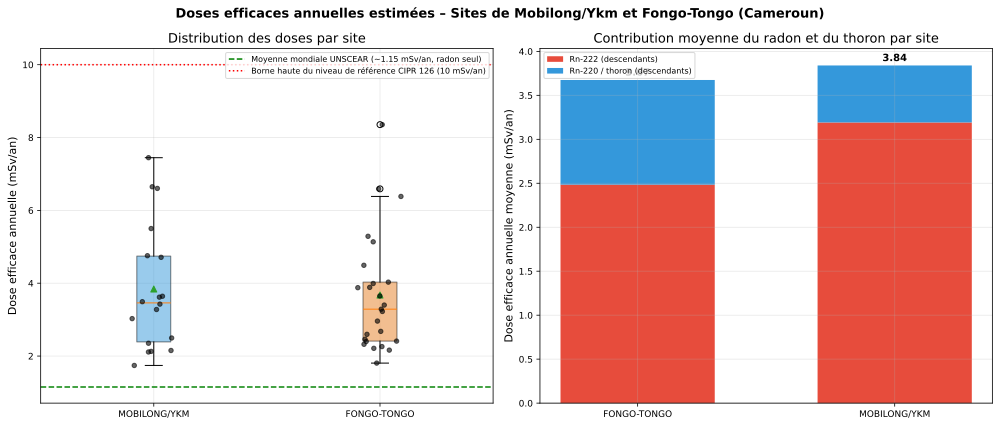

Figure enregistrée : Figure_terrain_Cameroun_doses.png


In [57]:
# ============================================================
# CELLULE 32 – Visualisation des doses par site (Cameroun)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ------------------------------------------------------------
# PANNEAU A — distribution des doses par site (boxplot + points)
# ------------------------------------------------------------

ax = axes[0]
sites = df_terrain['LOCALITIES'].unique()
data_box = [df_terrain.loc[df_terrain['LOCALITIES'] == s, 'Dose_totale_mSv_an'].values for s in sites]

bp = ax.boxplot(data_box, tick_labels=sites, patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], ['#3498DB', '#E67E22']):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

for i, s in enumerate(sites):
    y = df_terrain.loc[df_terrain['LOCALITIES'] == s, 'Dose_totale_mSv_an'].values
    x = np.random.normal(i + 1, 0.05, size=len(y))
    ax.scatter(x, y, alpha=0.6, s=20, color='black', zorder=3)

ax.axhline(1.15, color='green', linestyle='--', lw=1.5,
           label='Moyenne mondiale UNSCEAR (~1.15 mSv/an, radon seul)')
ax.axhline(10, color='red', linestyle=':', lw=1.5,
           label='Borne haute du niveau de référence CIPR 126 (10 mSv/an)')

ax.set_ylabel("Dose efficace annuelle (mSv/an)")
ax.set_title("Distribution des doses par site")
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ------------------------------------------------------------
# PANNEAU B — contribution radon / thoron par site
# ------------------------------------------------------------

ax = axes[1]
x = np.arange(len(df_synth_site))
width = 0.6

rn222_vals = df_synth_site['Dose_Rn222_moy'].values
rn220_vals = df_synth_site['Dose_Rn220_moy'].values

ax.bar(x, rn222_vals, width, label='Rn-222 (descendants)', color='#E74C3C')
ax.bar(x, rn220_vals, width, bottom=rn222_vals, label='Rn-220 / thoron (descendants)', color='#3498DB')

for i, (r222, r220) in enumerate(zip(rn222_vals, rn220_vals)):
    ax.text(i, r222 + r220 + 0.05, f"{r222 + r220:.2f}", ha='center', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_synth_site.index)
ax.set_ylabel("Dose efficace annuelle moyenne (mSv/an)")
ax.set_title("Contribution moyenne du radon et du thoron par site")
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

fig.suptitle("Doses efficaces annuelles estimées – Sites de Mobilong/Ykm et Fongo-Tongo (Cameroun)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_terrain_Cameroun_doses.png", dpi=200, bbox_inches='tight')
plt.show()

print("Figure enregistrée : Figure_terrain_Cameroun_doses.png")


### Discussion — résultats du terrain camerounais

**Niveaux mesurés.** La concentration équivalente d'équilibre du radon (EERC) varie de 14 à 108 Bq/m³ (moyenne ≈ 39 Bq/m³ à Fongo-Tongo, ≈ 51 Bq/m³ à Mobilong/Ykm), et celle du thoron (EETC) de 0,2 à 12,3 Bq/m³ (moyenne ≈ 4,4 Bq/m³ à Fongo-Tongo, ≈ 2,4 Bq/m³ à Mobilong/Ykm). Ces niveaux sont comparables à ceux couramment rapportés pour l'habitat traditionnel en zone tropicale (matériaux de construction locaux — terre, briques de latérite — souvent plus émanants que les matériaux occidentaux).

**Doses efficaces estimées.** La dose efficace annuelle moyenne, toutes habitations confondues, est d'environ **3,7 mSv/an** (médiane 3,4 mSv/an), avec un minimum de 1,7 mSv/an et un maximum de 8,4 mSv/an. **Aucune habitation ne dépasse 10 mSv/an**, borne haute du niveau de référence recommandé par la CIPR 126 pour les habitations ; les niveaux restent cependant nettement au-dessus de la dose moyenne mondiale attribuée au radon seul par l'UNSCEAR (≈ 1,15 mSv/an), ce qui est cohérent avec des concentrations en radon/thoron supérieures à la moyenne mondiale sur les deux sites étudiés.

**Comparaison entre les deux sites.** Mobilong/Ykm présente une EERC moyenne plus élevée (51 vs 39 Bq/m³) mais une EETC moyenne plus faible (2,4 vs 4,4 Bq/m³) que Fongo-Tongo. Au final, les doses moyennes des deux sites sont proches (3,84 mSv/an contre 3,68 mSv/an) : la dose totale dépend de la combinaison radon + thoron, et un site qui se distingue par une concentration de radon plus élevée n'est pas nécessairement celui qui présente la dose totale la plus forte si sa contribution thoron est plus faible. Ceci souligne l'intérêt de ne jamais négliger le thoron dans l'évaluation du risque radiologique de l'air intérieur, conformément à la conclusion déjà dégagée par les simulations précédentes de ce notebook.

**Rôle de la fraction non attachée.** Le résultat le plus directement lié à la question posée dans ce mémoire est que les logements présentant une fraction non attachée (p-Rn ou p-Tn) plus élevée se voient attribuer, pour une même EERC/EETC, un coefficient de dose — et donc une dose efficace — plus élevé(e), conformément à la tendance DCF(fp) établie plus haut. Ce résultat appelle, pour les futures campagnes de mesure, à systématiquement documenter la fraction non attachée (et pas seulement l'EERC/EETC globale) afin d'affiner l'évaluation dosimétrique individuelle des occupants.

**Limites de cette application.** Le temps d'occupation annuel a été fixé de façon standard à 7000 h/an (valeur usuelle UNSCEAR pour l'occupation intérieure), faute de données d'occupation individualisées dans le fichier transmis ; les durées de déploiement des détecteurs (`NUMBER OF DAYS`) renseignent la durée de mesure, non l'occupation réelle des logements. Une estimation individualisée nécessiterait un suivi des temps de présence par enquête auprès des occupants.


## CELLULE FINALE — Méthode de calcul manuel à reproduire à la main (à partir du fichier Excel)

Ton encadrant souhaite que tu saches reproduire ces calculs « à la main » (calculatrice/Excel) à
partir des données brutes du fichier `Cameroon_datacompiledRR__1_.xlsx`. Voici, étape par étape, la
méthode la plus simple et la plus défendable à reproduire manuellement — c'est la **voie F/PAEC/WL/WLM**
développée dans la première nouvelle section de ce notebook, parce qu'elle ne nécessite que des
formules fermées (pas de résolution d'équations différentielles).

---

### Étape 0 — Données nécessaires, pour CHAQUE logement

À lire directement dans le fichier Excel, colonnes `EERC (Bq/m3)`, `EETC (Bq/m3)`, `p-Rn`, `p-Tn` :

- $EERC$ : concentration équivalente d'équilibre du radon (Bq/m³)
- $EETC$ : concentration équivalente d'équilibre du thoron (Bq/m³)
- $F_{Rn} = p\text{-}Rn$ : fraction non attachée des descendants du radon (sans unité, entre 0 et 1)
- $F_{Tn} = p\text{-}Tn$ : fraction non attachée des descendants du thoron (idem)

*(Si $p\text{-}Tn$ est négatif dans le fichier — bruit de mesure aux faibles concentrations — le
remplacer par 0.)*

---

### Étape 1 — Concentration d'énergie alpha potentielle (PAEC), en J/m³

$$ PAEC_{Rn} = EERC \times \varepsilon_{Rn} \qquad \varepsilon_{Rn} = 5{,}62\times10^{-9}\ \text{J/m}^3 \text{ par Bq/m}^3 $$
$$ PAEC_{Tn} = EETC \times \varepsilon_{Tn} \qquad \varepsilon_{Tn} = 7{,}56\times10^{-8}\ \text{J/m}^3 \text{ par Bq/m}^3 $$

*(Ces deux constantes $\varepsilon$ se retrouvent en divisant l'énergie d'1 WL, $2{,}08\times10^{-5}$
J/m³, par la concentration définissant 1 WL : 3700 Bq/m³ pour le radon, 275 Bq/m³ pour le thoron —
voir Étape 2.)*

---

### Étape 2 — Conversion en Working Level (WL), puis en milli-Working Level (mWL)

$$ WL_{Rn} = \dfrac{PAEC_{Rn}}{2{,}08\times10^{-5}\ \text{J/m}^3} \qquad \text{soit, de façon équivalente :} \qquad WL_{Rn} = \dfrac{EERC}{3700} $$
$$ WL_{Tn} = \dfrac{EETC}{275} $$
$$ mWL = WL \times 1000 $$

---

### Étape 3 — Exposition annuelle en Working Level Month (WLM)

$$ WLM_{an} = WL \times \dfrac{T_{exp}}{170} $$

Où $T_{exp}$ est le nombre d'heures d'occupation annuelle du logement (valeur retenue dans ce
mémoire : **7000 h/an**, hypothèse résidentielle standard UNSCEAR/ICRP — vérifie cette valeur avec
ton encadrant si une autre convention est utilisée pour ton mémoire) et 170 h = durée définissant
1 WLM.

---

### Étape 4 — Dose efficace annuelle (mSv/an)

$$ D_{an} = WLM_{Rn,an} \times CCD_{Rn} + WLM_{Tn,an} \times CCD_{Tn} $$

Avec un coefficient de conversion de dose (CCD) à choisir dans la littérature (voir le tableau
comparatif de la première section de ce notebook) — par exemple :

- $CCD_{Rn} = 5{,}7$ à $10$ mSv/WLM (UNSCEAR retenu à ICRP 137)
- $CCD_{Tn} = 1{,}9$ à $4{,}6$ mSv/WLM (UNSCEAR à ICRP130/Sahoo)

**⚠️ À indiquer obligatoirement dans ton mémoire :** la référence exacte du CCD choisi — la dose
finale en dépend directement (jusqu'à un facteur ≈2 selon la référence retenue).

---

### Exemple numérique complet (un logement fictif, pour vérifier ta méthode)

Soit un logement avec $EERC = 50$ Bq/m³, $EETC = 20$ Bq/m³, $F_{Rn}=0{,}08$, $F_{Tn}=0{,}10$ :

| Étape | Radon | Thoron |
|---|---|---|
| PAEC (J/m³) | $50 \times 5{,}62\times10^{-9} = 2{,}81\times10^{-7}$ | $20 \times 7{,}56\times10^{-8} = 1{,}51\times10^{-6}$ |
| WL | $50/3700 = 0{,}0135$ | $20/275 = 0{,}0727$ |
| mWL | $13{,}5$ | $72{,}7$ |
| WLM/an (T_exp=7000h) | $0{,}0135\times7000/170 = 0{,}557$ | $0{,}0727\times7000/170 = 2{,}994$ |
| Dose (mSv/an), CCD=10 / 4,6 | $0{,}557\times10 = 5{,}57$ | $2{,}994\times4{,}6=13{,}77$ |
| **Dose totale** | | **≈ 19,3 mSv/an** |


